In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import requests
from tqdm import tqdm
from IPython.display import clear_output

from numpy.linalg import svd
from scipy.sparse.linalg import svds
from numpy.lib.stride_tricks import as_strided
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, acf, pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import hampel

import warnings
warnings.simplefilter(action='ignore', category=Warning)


In [81]:
df = pd.read_csv('data/open_meteo_train.csv')
df['time'] = pd.to_datetime(df['time'])
df['month'] = df['time'].dt.month
# df['DD'] = df['DD'] % 360

In [3]:
df

,site,lat,long,h,pm25,time,temperature_2m (°C),relative_humidity_2m (%),pressure_msl (hPa),surface_pressure (hPa),...,alt_diff,p_nmu_KAN,dp_nmu_KAN,pnmu_RiKAN_x,pnmu_RiKAN_y,pnmu_KAN_new,pnmu_RiKAN_new_x,pnmu_RiKAN_new_y,pnmu_new,month
0,3837,55.986571,92.762222,255,7.7,2023-01-03 14:00:00,-18.1,81,1025.1,1000.7,...,-70.538833,0.964036,0.022980,0.869791,0.934098,1.000000,1.0,1.000000,1.000000e+00,1
1,3841,56.032797,92.886663,206,15.3,2023-01-03 14:00:00,-18.1,81,1025.1,1000.7,...,-46.023176,0.964036,0.022980,0.869791,0.934098,1.000000,1.0,1.000000,1.000000e+00,1
2,3842,56.007720,92.821260,177,22.5,2023-01-03 14:00:00,-18.1,81,1025.1,1000.7,...,13.134002,0.964036,0.022980,0.869791,0.934098,1.000000,1.0,1.000000,1.000000e+00,1
3,3843,56.025130,92.799131,186,33.7,2023-01-03 14:00:00,-18.1,81,1025.1,1000.7,...,-2.001870,0.964036,0.022980,0.869791,0.934098,1.000000,1.0,1.000000,1.000000e+00,1
4,3847,56.077430,92.704560,226,16.8,2023-01-03 14:00:00,-18.1,81,1025.1,1000.7,...,-68.459573,0.964036,0.022980,0.869791,0.934098,1.000000,1.0,1.000000,1.000000e+00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
444681,3858,56.012040,92.973290,146,11.1,2025-12-28 11:00:00,-13.2,85,1028.1,1004.1,...,7.553743,0.371316,-0.013997,0.178010,0.633351,0.000103,1.0,0.999999,6.301944e-07,12
444682,3859,55.994686,92.958275,144,11.9,2025-12-28 11:00:00,-13.2,85,1028.1,1004.1,...,7.402545,0.371316,-0.013997,0.178010,0.633351,0.000103,1.0,0.999999,6.301944e-07,12
444683,3915,56.066574,92.843109,152,49.4,2025-12-28 11:00:00,-13.2,85,1028.1,1004.1,...,9.814110,0.371316,-0.013997,0.178010,0.633351,0.000103,1.0,0.999999,6.301944e-07,12
444684,4227,56.007160,92.909860,128,4.7,2025-12-28 11:00:00,-13.2,85,1028.1,1004.1,...,36.504878,0.371316,-0.013997,0.178010,0.633351,0.000103,1.0,0.999999,6.301944e-07,12


# Автокорреляция

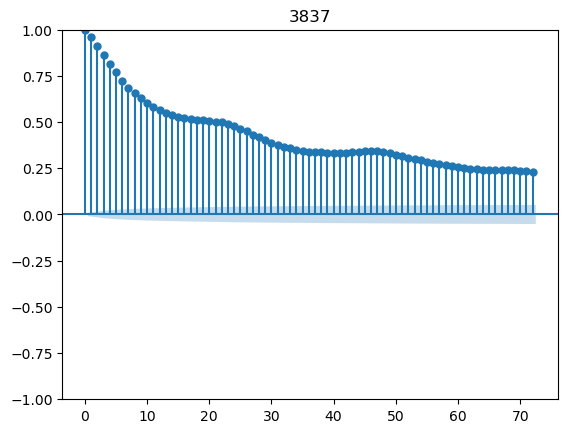

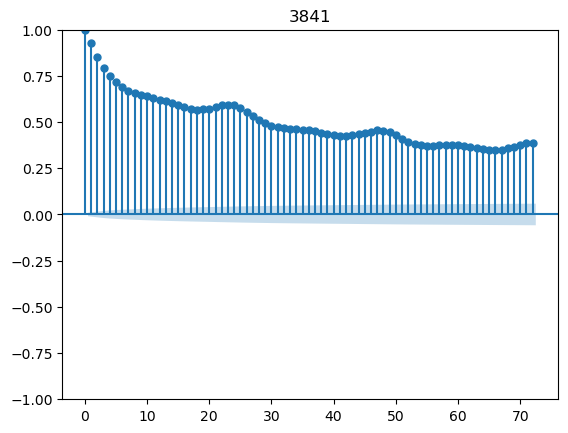

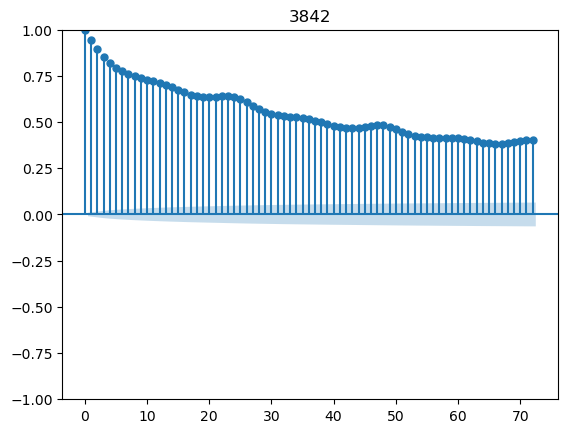

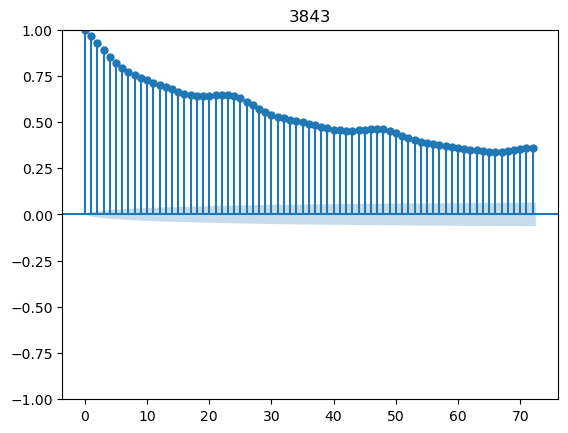

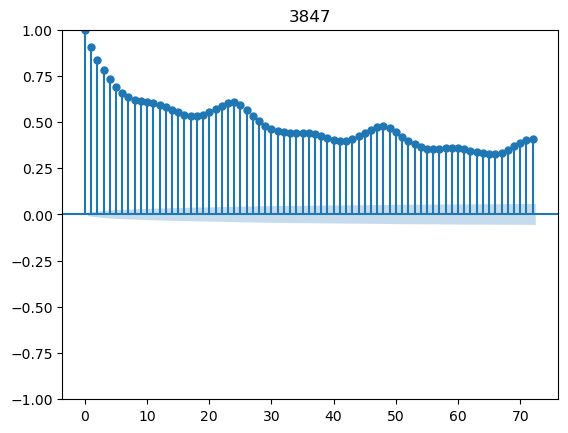

...

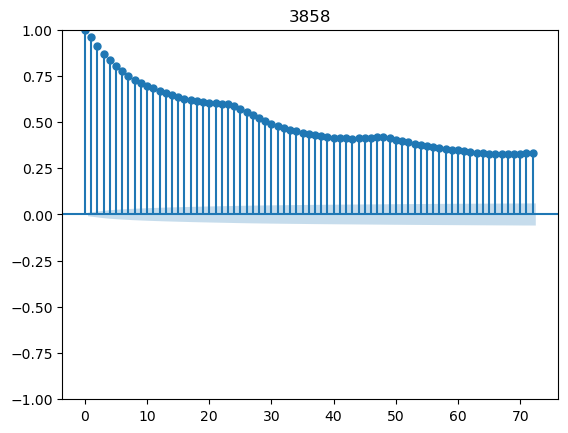

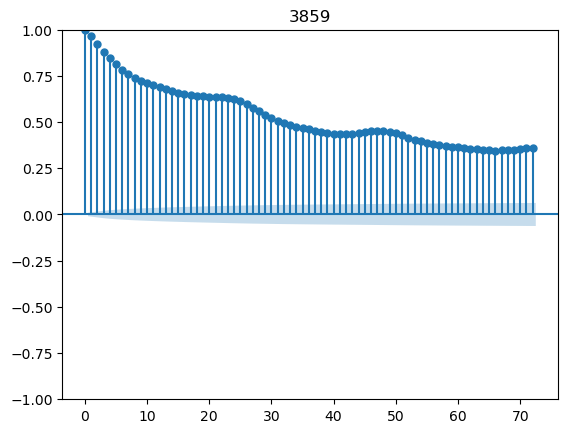

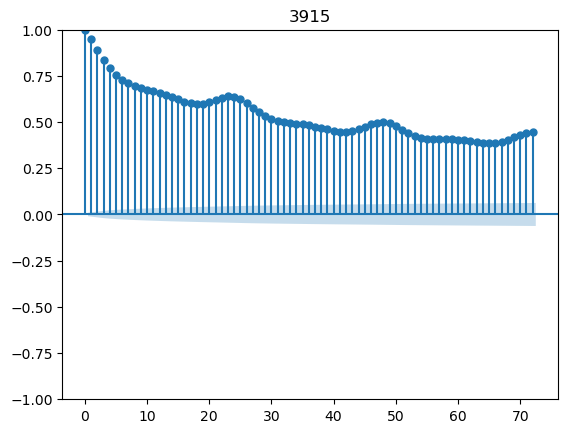

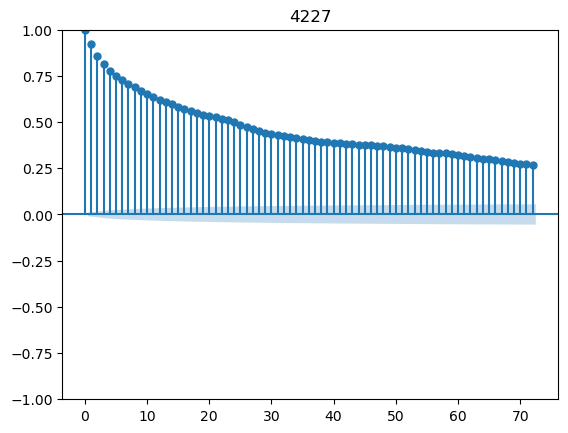

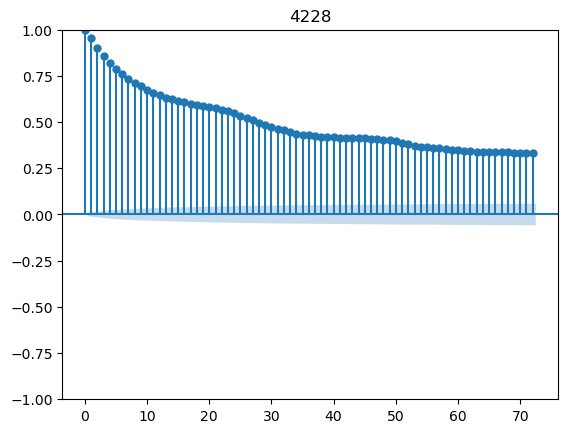

In [48]:
for site, group in df.groupby('site'):
    plot_acf(group['pm25'], alpha=0.05, lags=24*3)
    plt.title(site)
    plt.show()

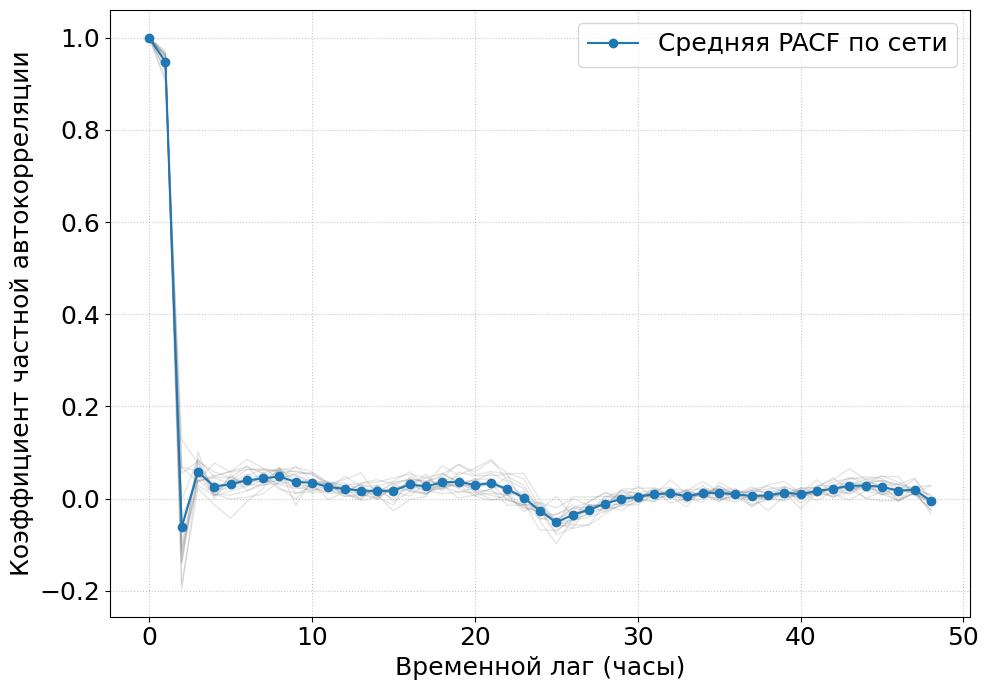

In [234]:
# Параметры анализа
lags = 24*2  # Исследуем двое суток (48 часов)
all_acfs = []
sites = []

plt.figure(figsize=(10, 7))

# Проходим циклом по датчикам
for site, group in df.groupby('site'):
    # Важно: работаем с колонкой pm25, удаляя пропуски для расчета ACF
    y = group['pm25'].dropna()
    
    if len(y) > lags:
        corel = pacf(y, nlags=lags)
        all_acfs.append(corel)
        sites.append(site)
        
        # Рисуем тонкую серую линию для каждого датчика
        plt.plot(corel, color='gray', alpha=0.2, linewidth=1)

# Вычисляем средний профиль автокорреляции по всей сети
mean_acf = np.mean(all_acfs, axis=0)

# Отрисовка жирной средней линии
plt.plot(mean_acf, '-o', color='#1f77b4', linewidth=1.5, label='Средняя PACF по сети')

# Добавляем вертикальную линию на 24 часа для акцента
# plt.axvline(x=24, color='red', linestyle='--', alpha=0.6, label='Суточный цикл (24ч)')

# Оформление графика

plt.xlabel('Временной лаг (часы)', fontsize=18)
plt.ylabel('Коэффициент частной автокорреляции', fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=18)

plt.tight_layout()
plt.show()

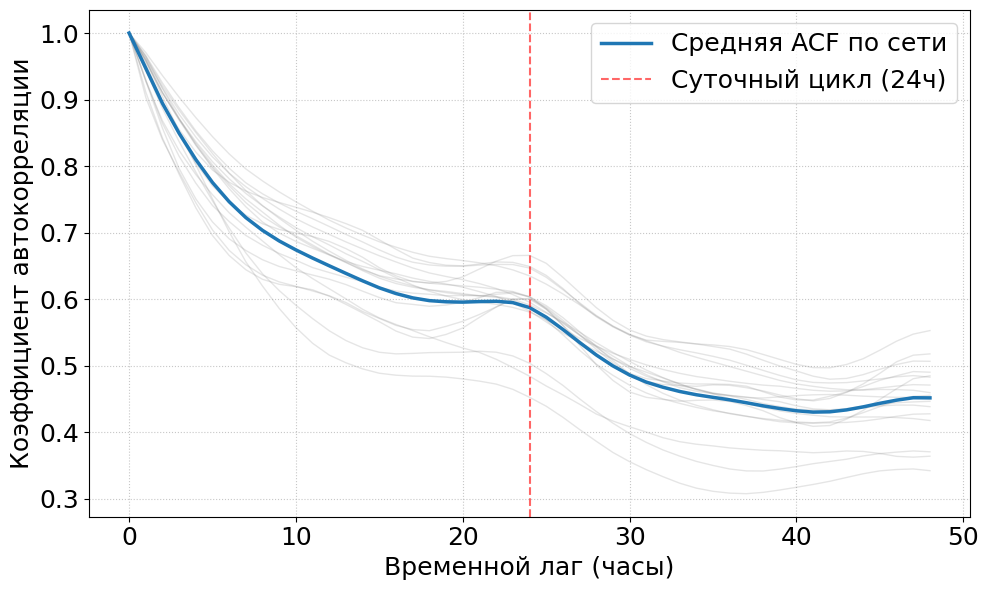

In [228]:
# Параметры анализа
lags = 24*2  # Исследуем двое суток (48 часов)
all_acfs = []
sites = []

plt.figure(figsize=(10, 6))

# Проходим циклом по датчикам
for site, group in df.groupby('site'):
    # Важно: работаем с колонкой pm25, удаляя пропуски для расчета ACF
    y = group['pm25'].dropna()
    
    if len(y) > lags:
        corel = acf(y, nlags=lags)
        all_acfs.append(corel)
        sites.append(site)
        
        # Рисуем тонкую серую линию для каждого датчика
        plt.plot(corel, color='gray', alpha=0.2, linewidth=1)

# Вычисляем средний профиль автокорреляции по всей сети
mean_acf = np.mean(all_acfs, axis=0)

# Отрисовка жирной средней линии
plt.plot(mean_acf, color='#1f77b4', linewidth=2.5, label='Средняя ACF по сети')

# Добавляем вертикальную линию на 24 часа для акцента
plt.axvline(x=24, color='red', linestyle='--', alpha=0.6, label='Суточный цикл (24ч)')

# Оформление графика
plt.xlabel('Временной лаг (часы)', fontsize=18)
plt.ylabel('Коэффициент автокорреляции', fontsize=18)
plt.grid(True, linestyle=':', alpha=0.7)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)

plt.tight_layout()
plt.show()

# Удаление шумов фильтром Хампеля

In [167]:
k_range = [*range(1,13)]
site_metrics = {}
for site, group in df.groupby('site'):
    MSE = []
    MAE = []
    for k in k_range:
        clear_output(wait=True)
        print(site, k)
        filtered_data = hampel.hampel(group['pm25'],
                                      window_size=k).filtered_data.values
        MSE.append(mean_squared_error(group['pm25'].values,
                                      filtered_data))
        MAE.append(mean_absolute_error(group['pm25'].values,
                                      filtered_data))
    site_metrics[site] = {'MSE':MSE,'MAE':MAE}

4228 12


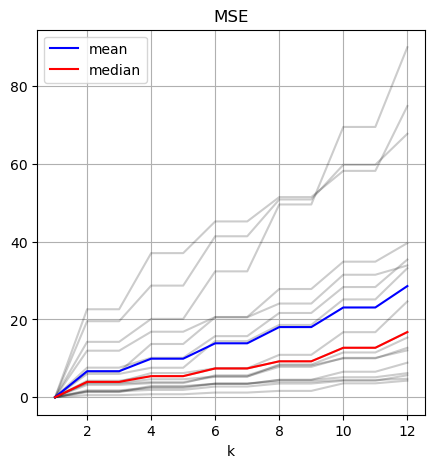

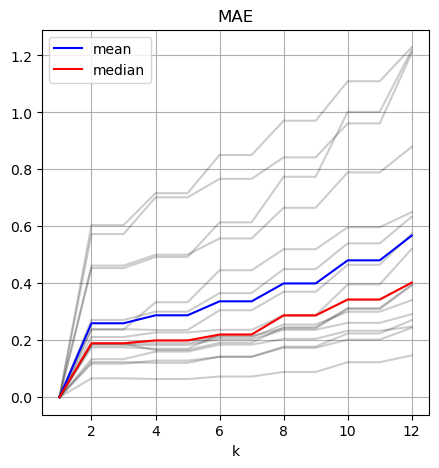

In [240]:
plt.figure(figsize=(5,5))
mean_MSE = []
for i , site in enumerate(site_metrics.keys()):
    mean_MSE.append(site_metrics[site]['MSE'])
    plt.plot(k_range,site_metrics[site]['MSE'], color='black',alpha=0.2)
plt.plot(k_range, np.mean(np.array(mean_MSE),axis=0), label='mean',color='blue')
plt.plot(k_range, np.median(np.array(mean_MSE),axis=0), label='median',color='red')
plt.xlabel('k')
plt.title('MSE')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(5,5))
mean_MAE = []
for i , site in enumerate(site_metrics.keys()):
    mean_MAE.append(site_metrics[site]['MAE'])
    plt.plot(k_range,site_metrics[site]['MAE'], color='black',alpha=0.2)
plt.plot(k_range, np.mean(np.array(mean_MAE),axis=0), label='mean',color='blue')
plt.plot(k_range, np.median(np.array(mean_MAE),axis=0), label='median',color='red')
plt.legend()
plt.xlabel('k')
plt.title('MAE')
plt.grid()
plt.show()

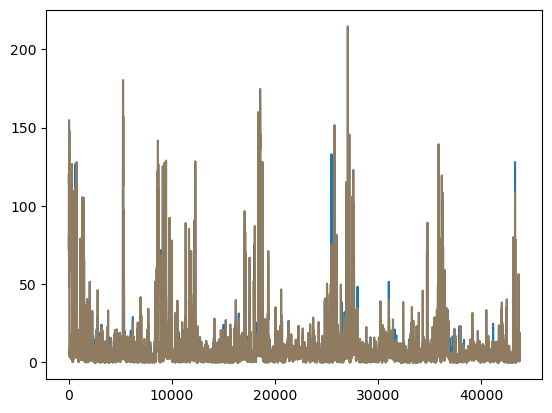

In [748]:
plt.plot(df[df['site']==3837]['pm25'],label='orig')
plt.plot(hampel.hampel(df[df['site']==3837]['pm25'],window_size=7).filtered_data.values,label='filtered',alpha=0.5)
plt.show()

# Разложение с seasonal_decompose

3837


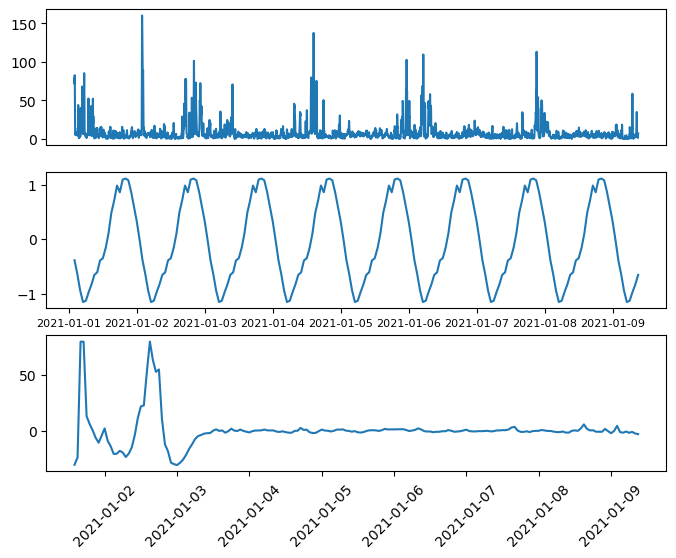

3841


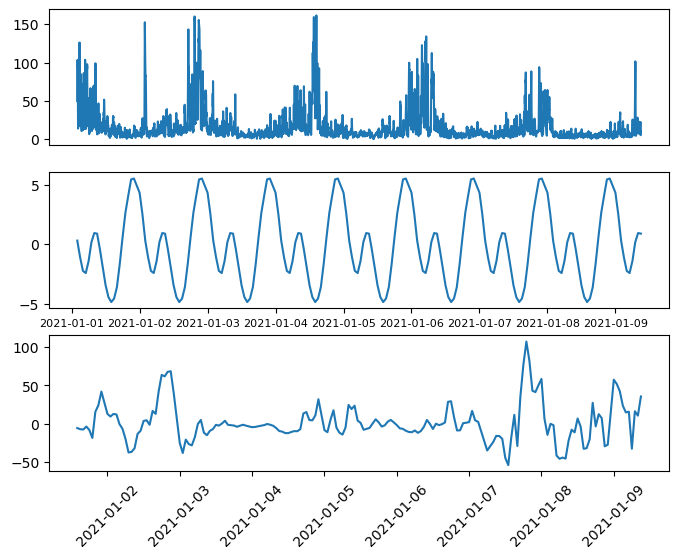

3842


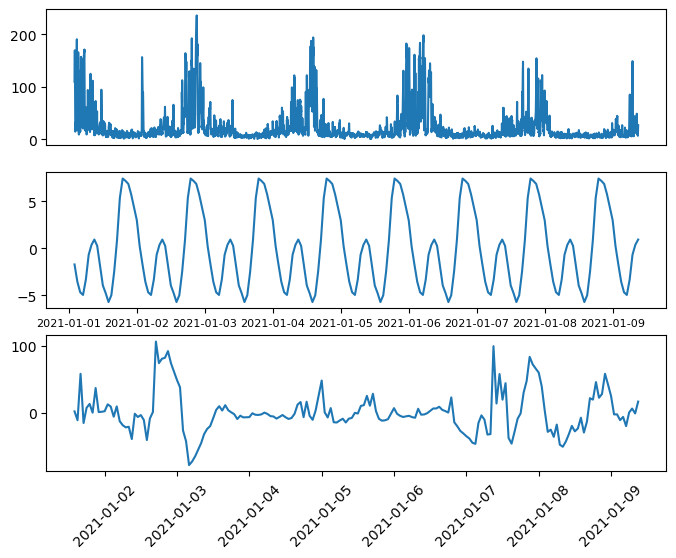

3843


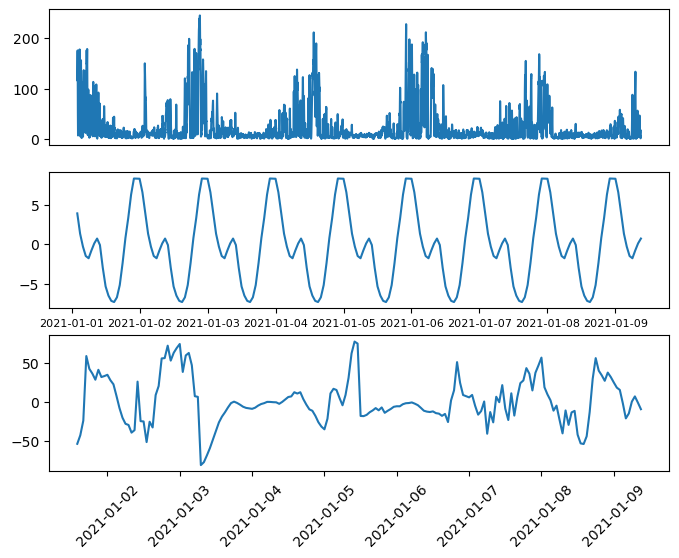

3847


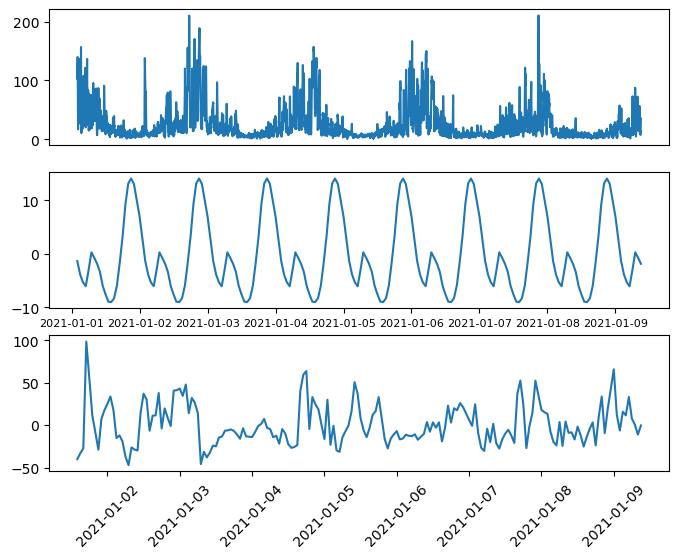

3849


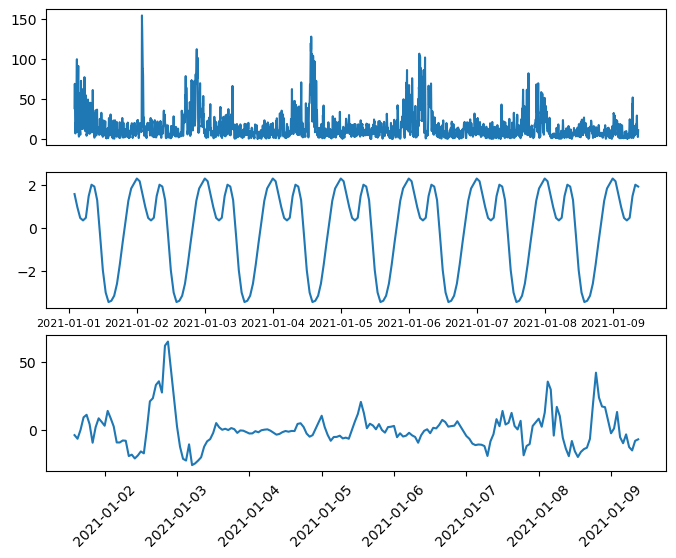

3851


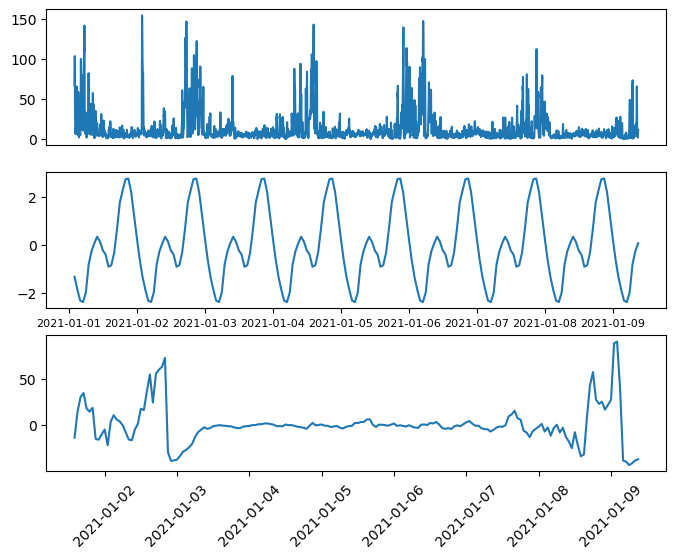

3853


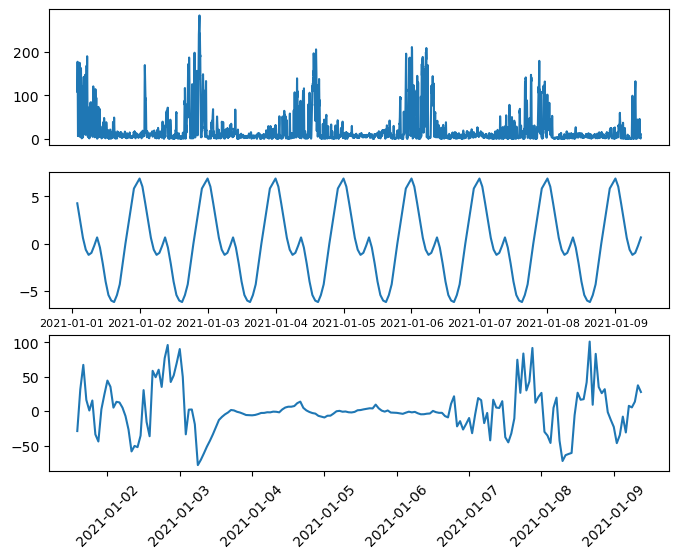

3854


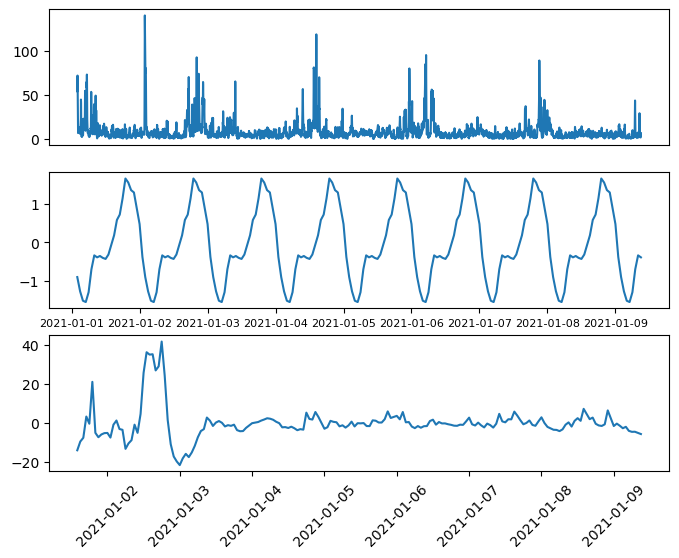

3855


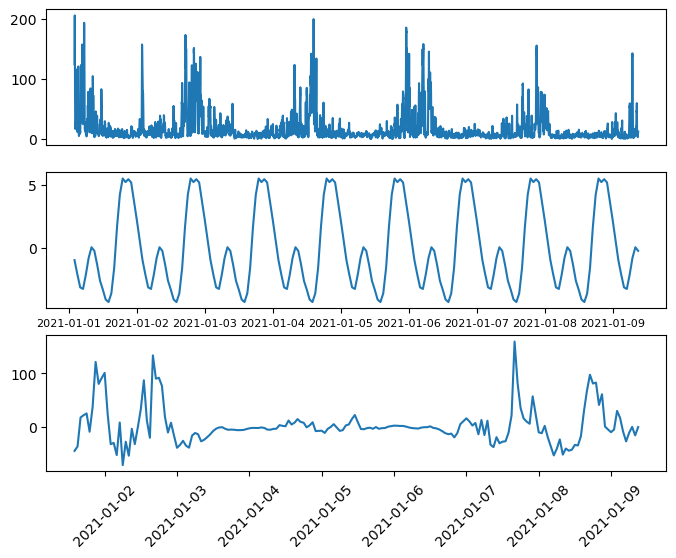

3856


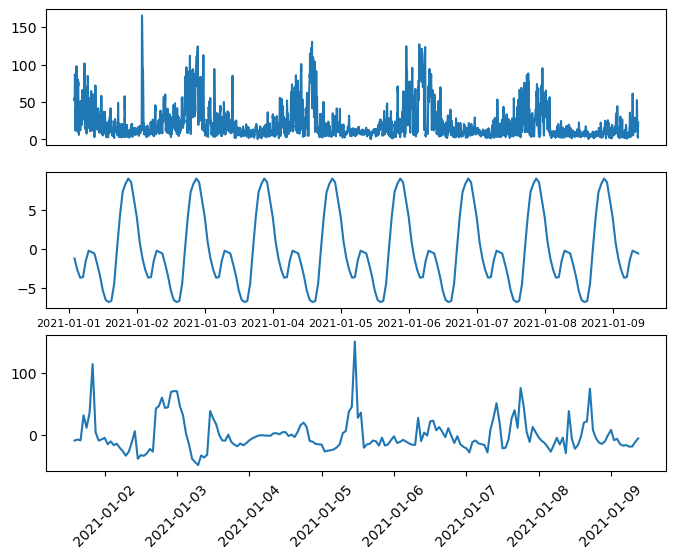

3857


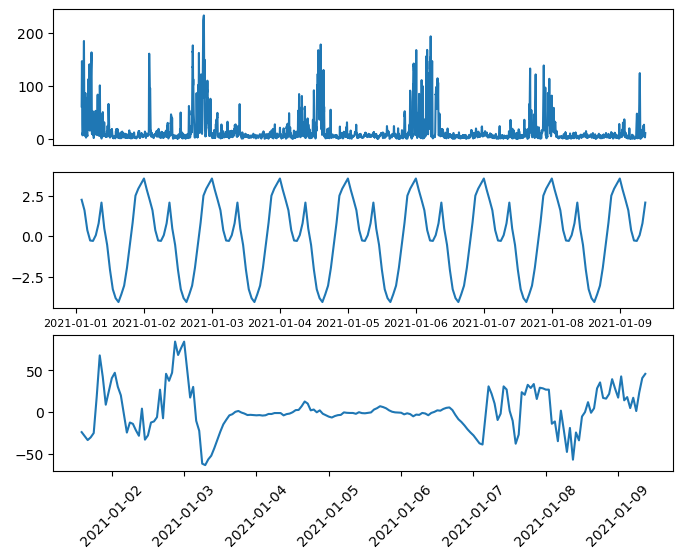

3858


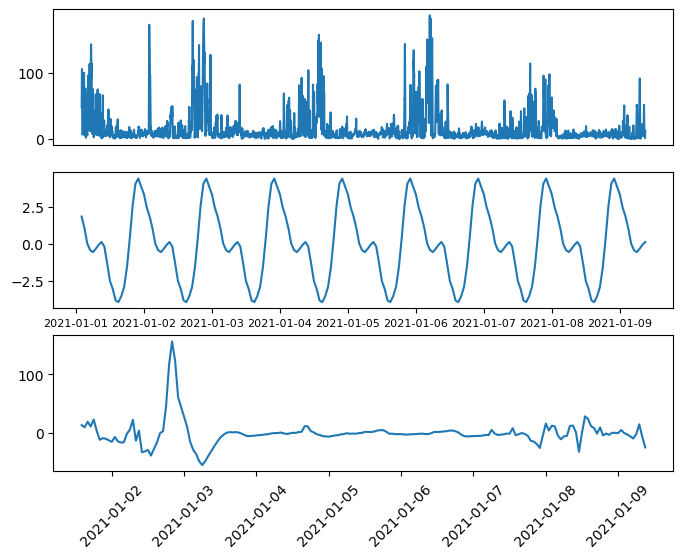

3859


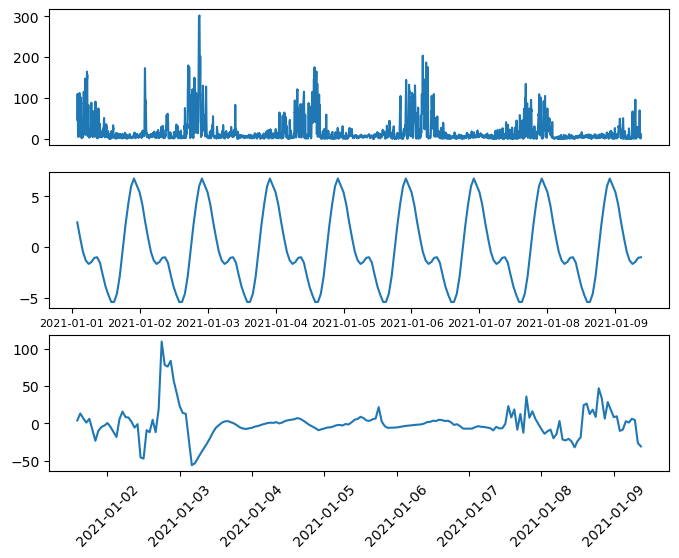

3915


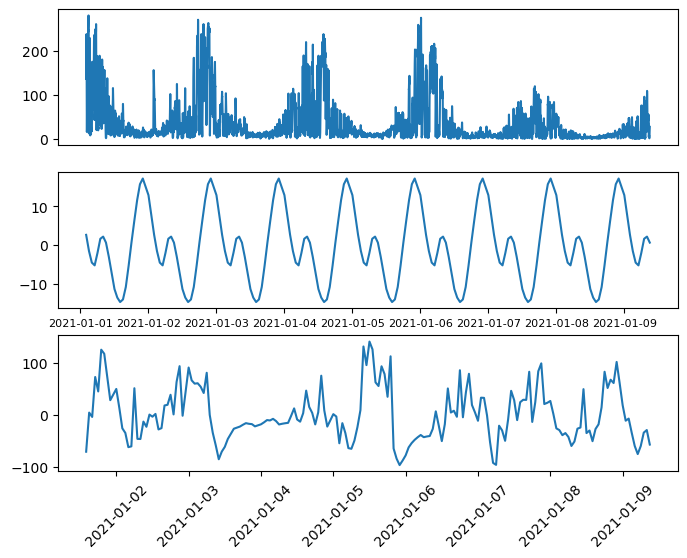

4227


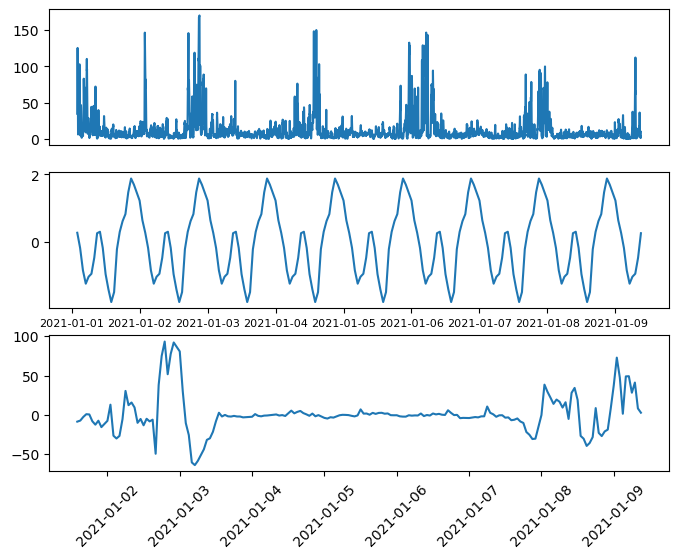

4228


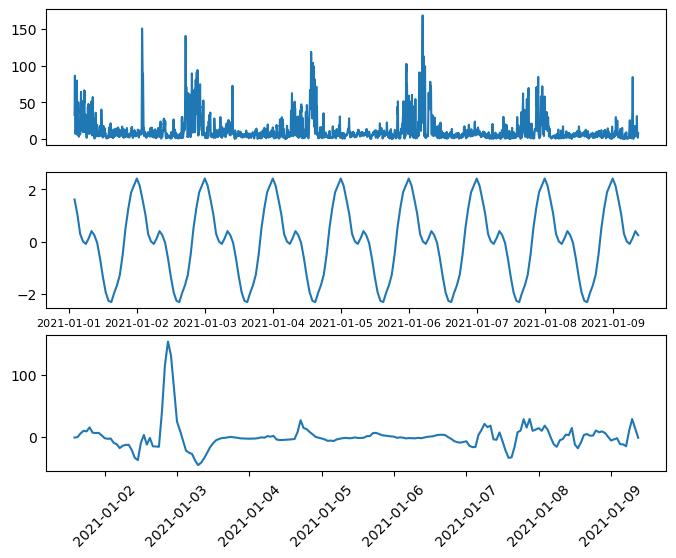

In [61]:
for site, group in df.groupby('site'):
    group['time'] = pd.to_datetime(group['time'])
    # group['pm25'] = hampel.hampel(group['pm25'],window_size=7).filtered_data.values
    decompose = seasonal_decompose(group.set_index('time')['pm25'],period=24)
    print(site)
    plt.figure(figsize=(8,6))
    plt.subplot(3,1,1)
    plt.plot(decompose.trend.iloc[:])
    # plt.title('Trend')
    plt.xticks([])

    plt.subplot(3,1,2)
    plt.plot(decompose.seasonal.iloc[:200])
    # plt.title('Seasonal')
    plt.xticks(fontsize=8)
    # plt.xticks(decompose.seasonal.index[:200])

    plt.subplot(3,1,3)
    plt.plot(decompose.resid.iloc[:200])
    # plt.title('Residuals')
    plt.xticks(rotation=45)
    plt.show()

3837


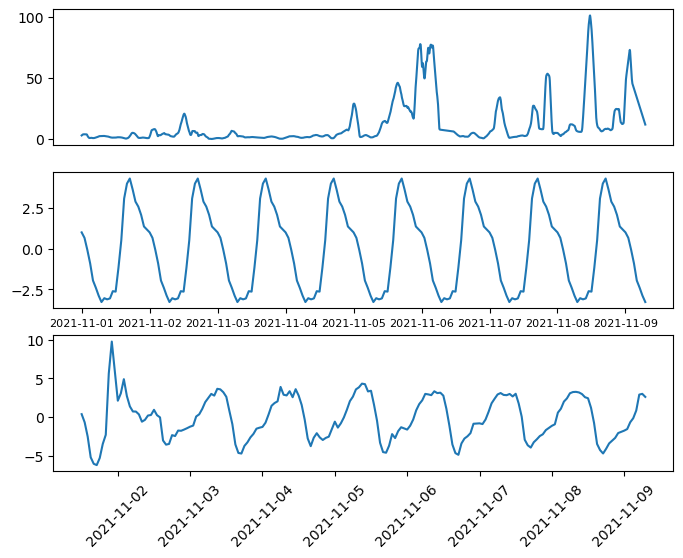

3841


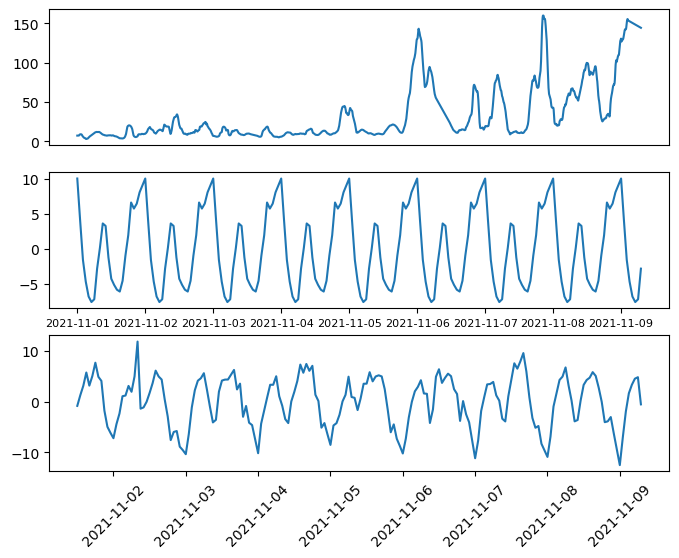

3842


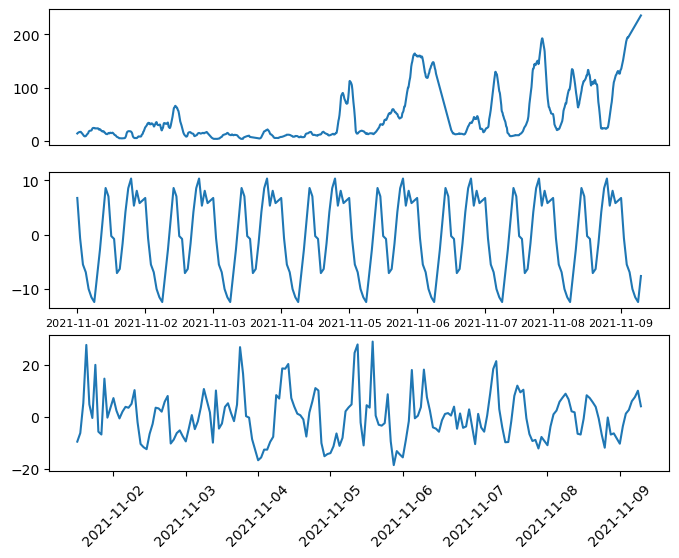

3843


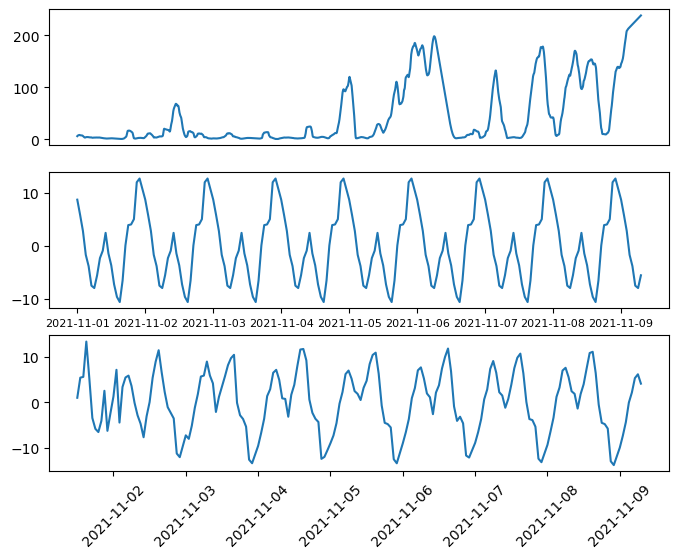

3847


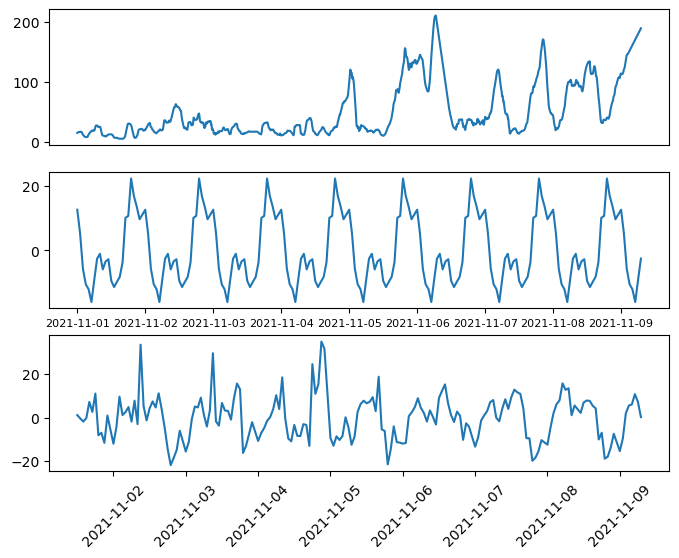

3849


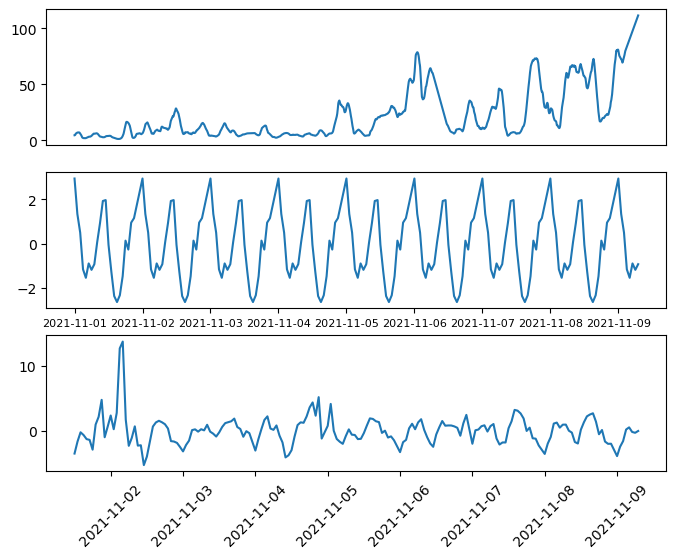

3851


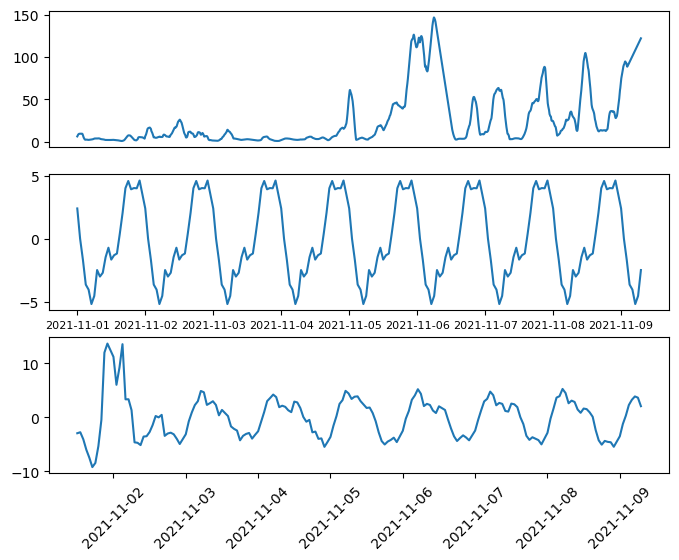

3853


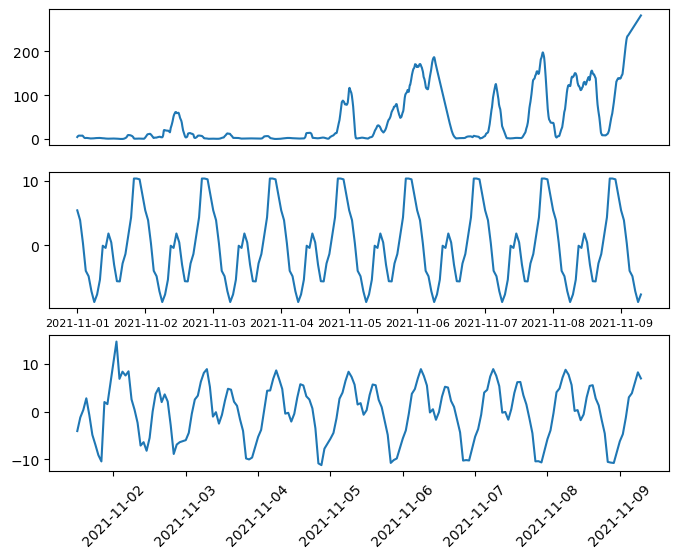

3854


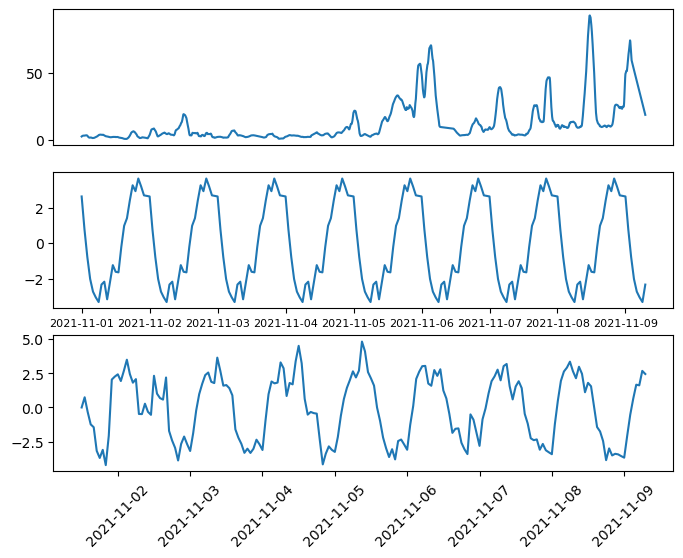

3855


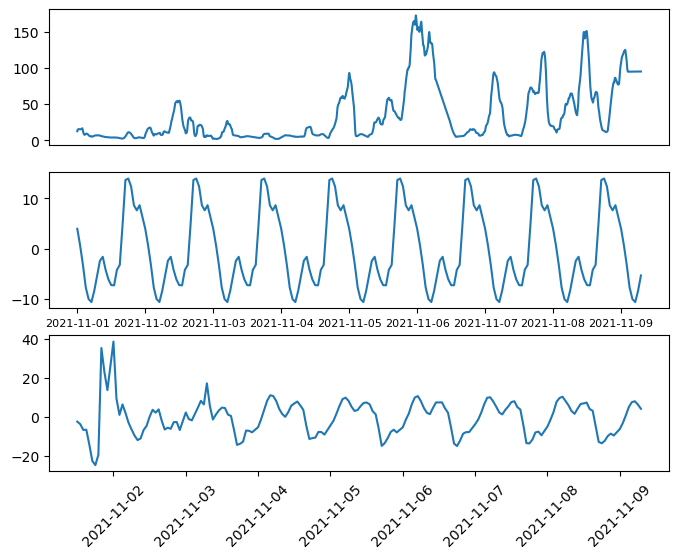

3856


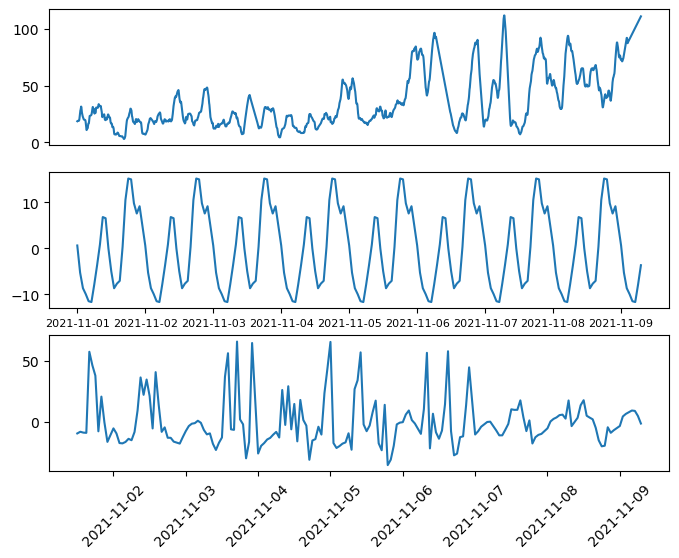

3857


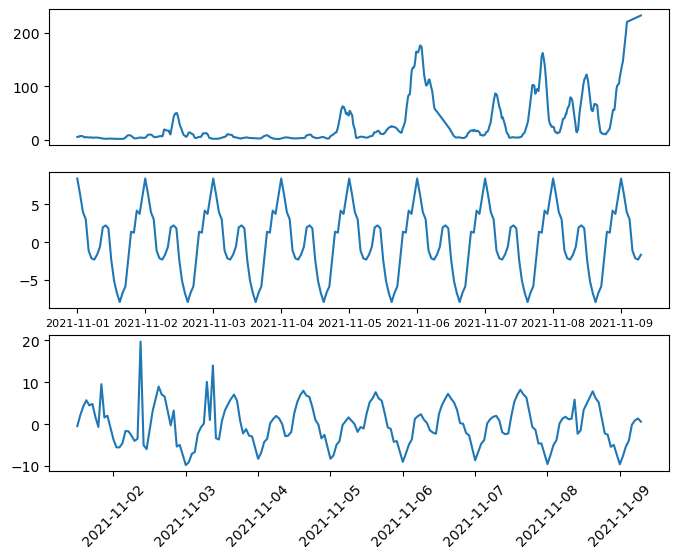

3858


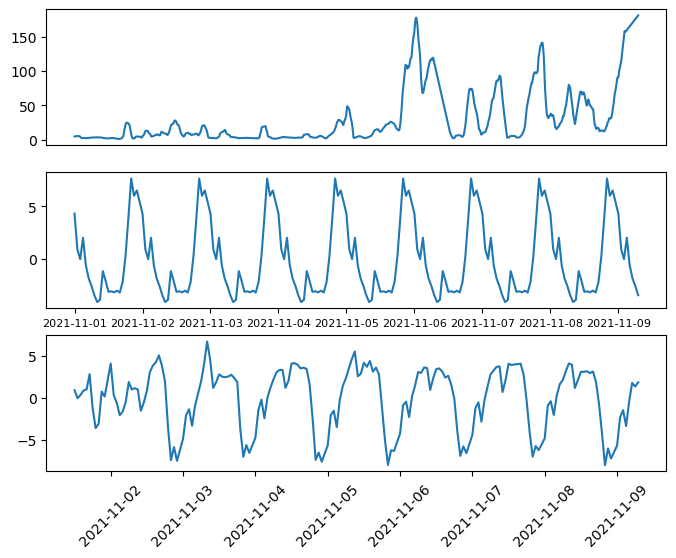

3859


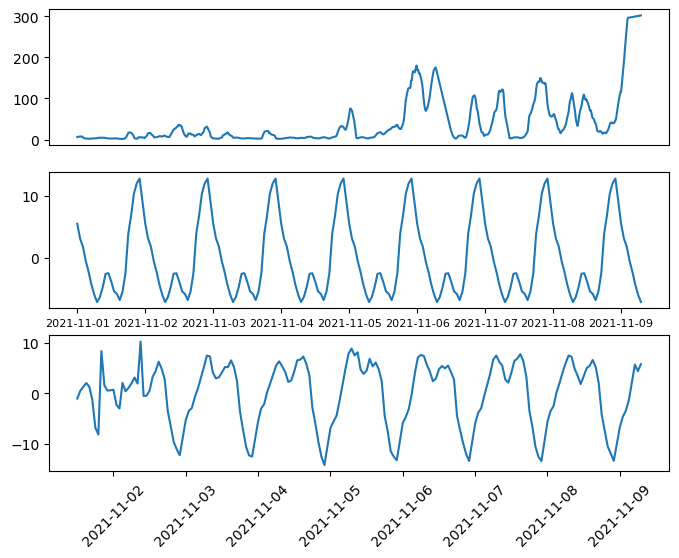

3915


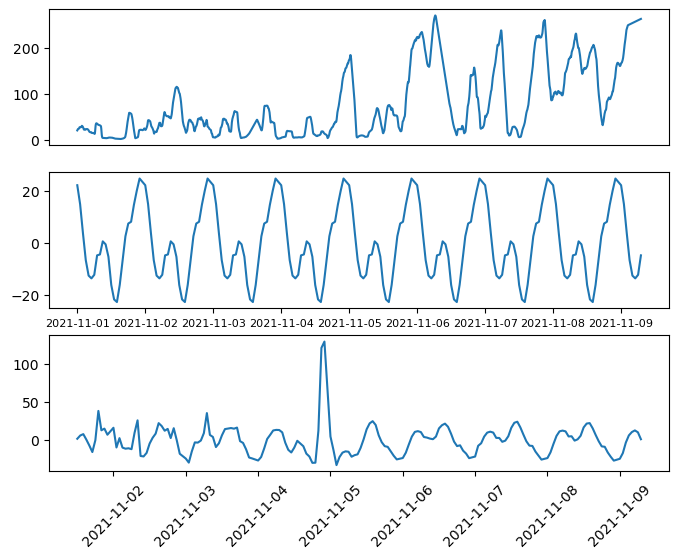

4227


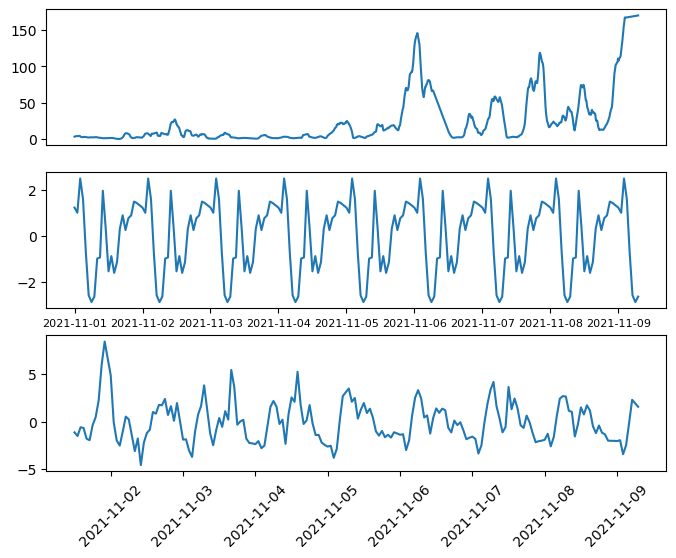

4228


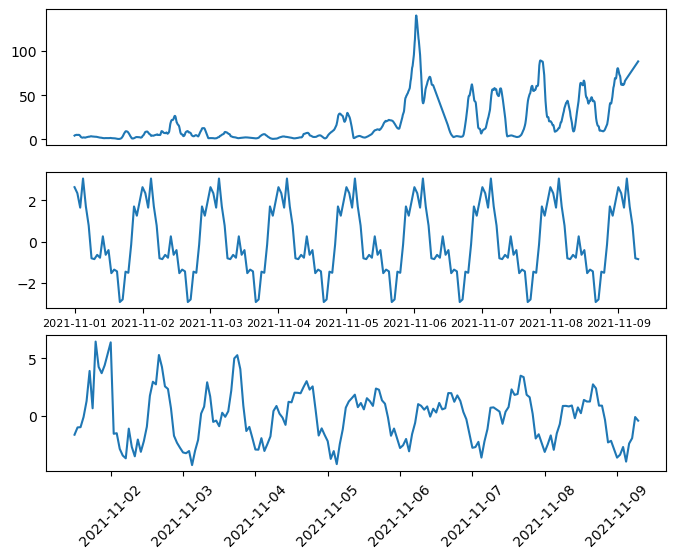

In [57]:
for site, group in df.groupby('site'):
    group['time'] = pd.to_datetime(group['time'])
    date_index = pd.date_range("11.01.2021","02.01.2022",freq='1h')
    decompose = seasonal_decompose(group.set_index('time')['pm25'].loc[date_index],period=24)
    print(site)
    plt.figure(figsize=(8,6))
    plt.subplot(3,1,1)
    plt.plot(decompose.trend.iloc[:])
    # plt.title('Trend')
    plt.xticks([])

    plt.subplot(3,1,2)
    plt.plot(decompose.seasonal.iloc[:200])
    # plt.title('Seasonal')
    plt.xticks(fontsize=8)
    # plt.xticks(decompose.seasonal.index[:200])

    plt.subplot(3,1,3)
    plt.plot(decompose.resid.iloc[:200])
    # plt.title('Residuals')
    plt.xticks(rotation=45)
    plt.show()

3837


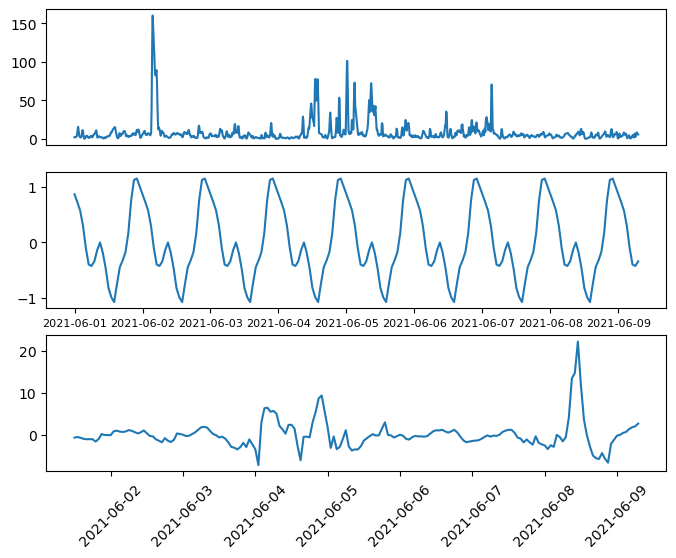

3841


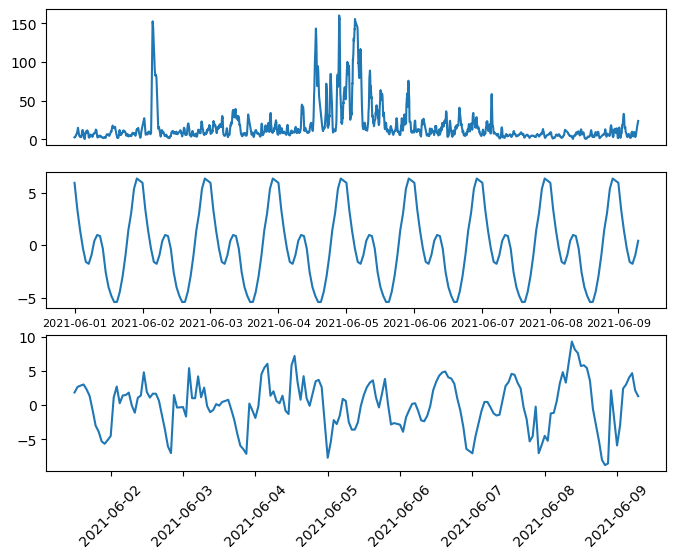

3842


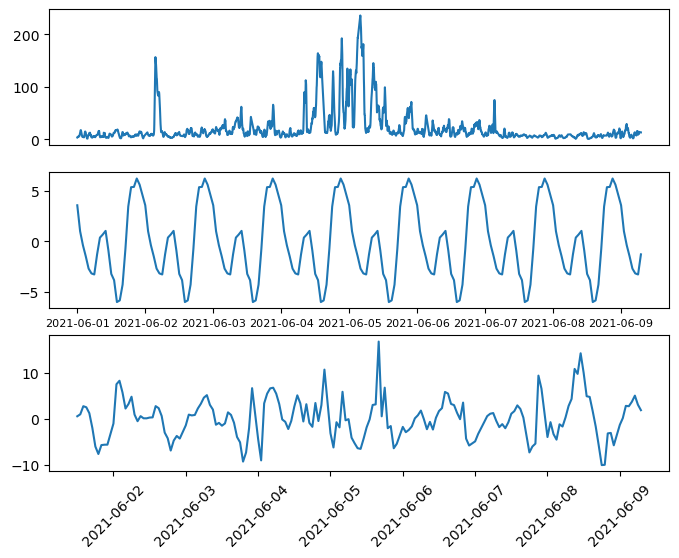

3843


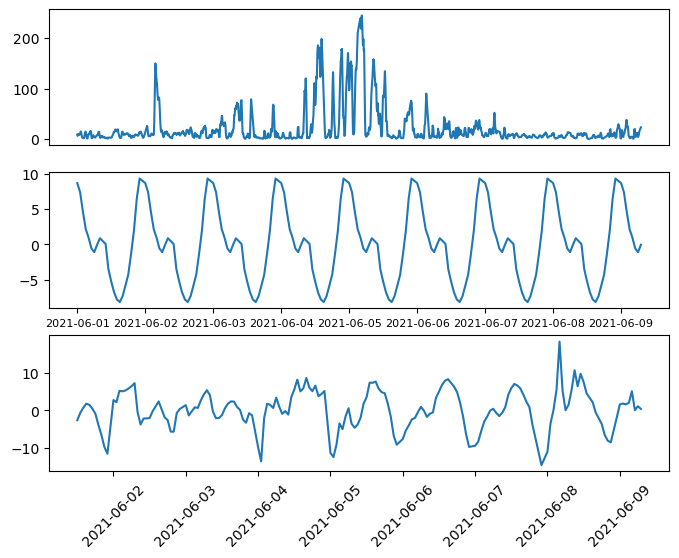

3847


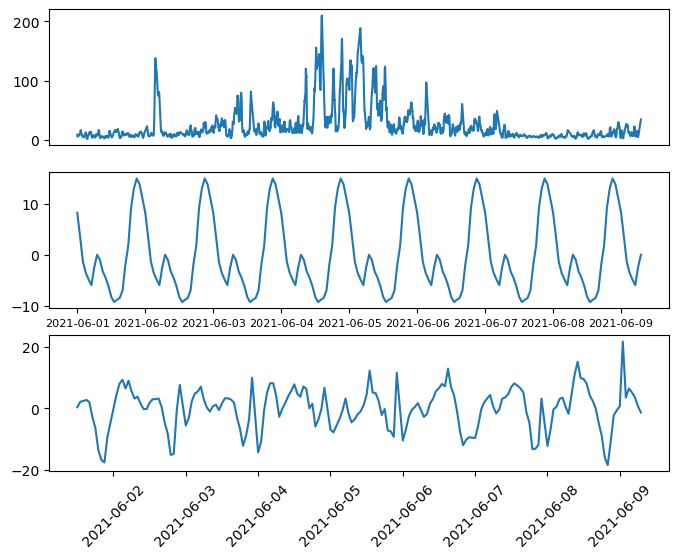

3849


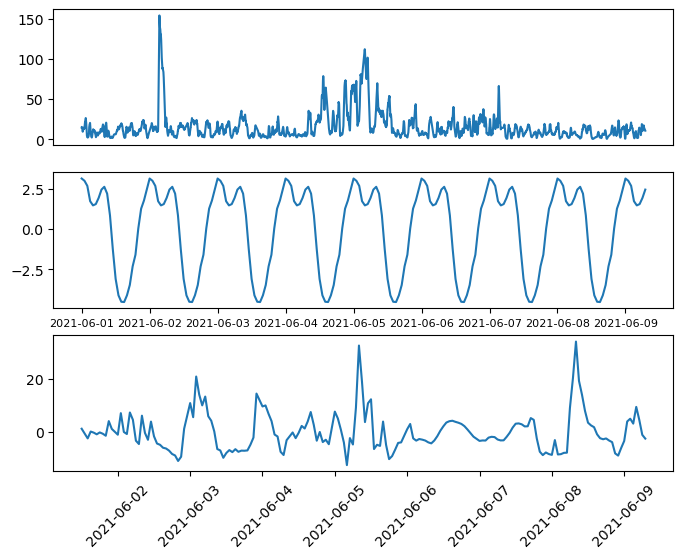

3851


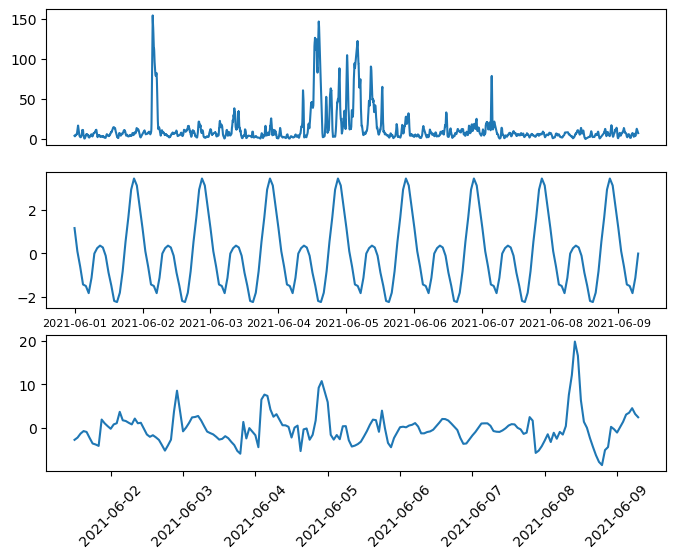

3853


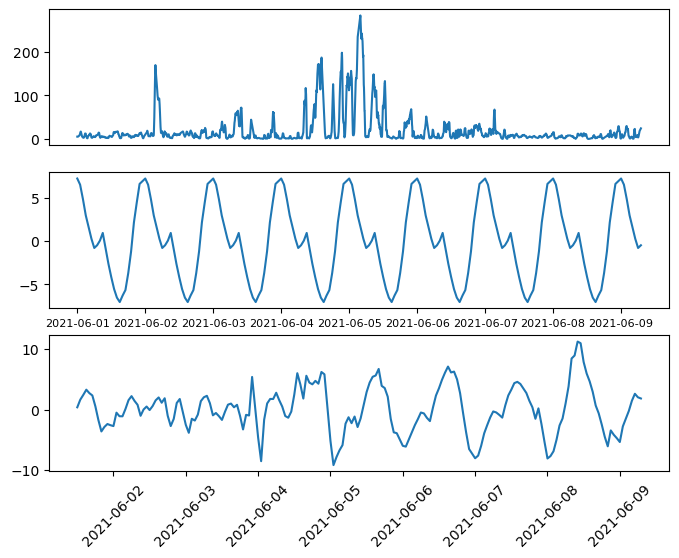

3854


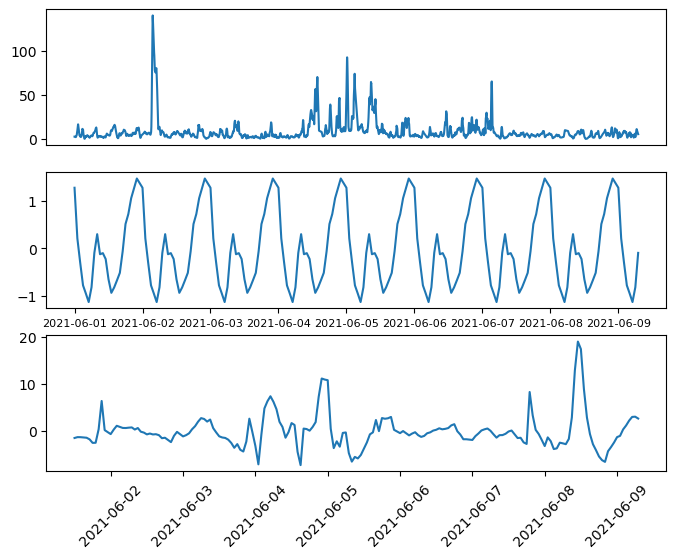

3855


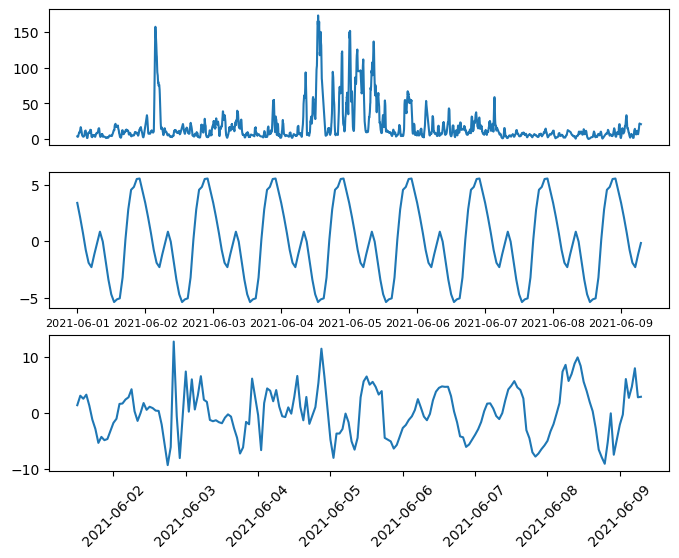

3856


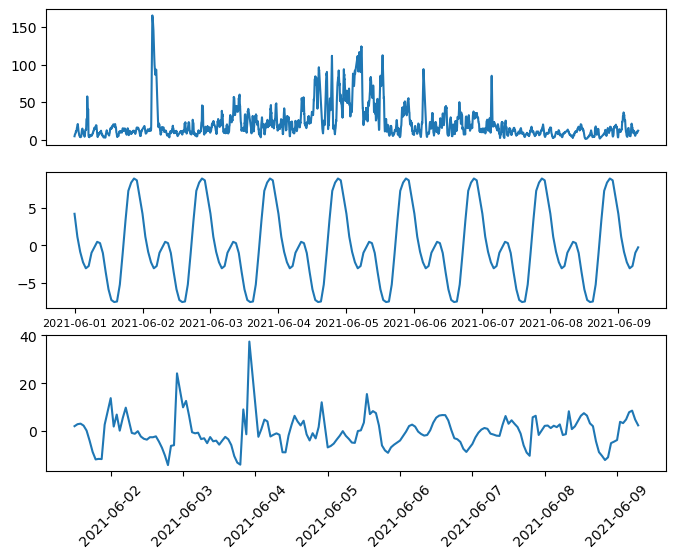

3857


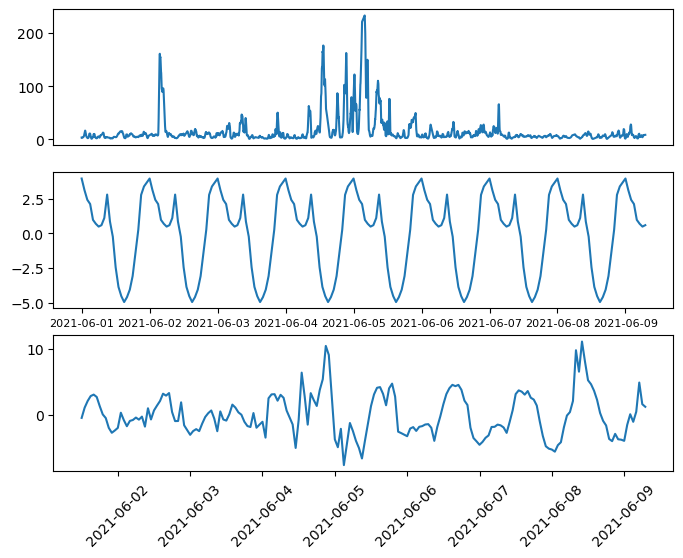

3858


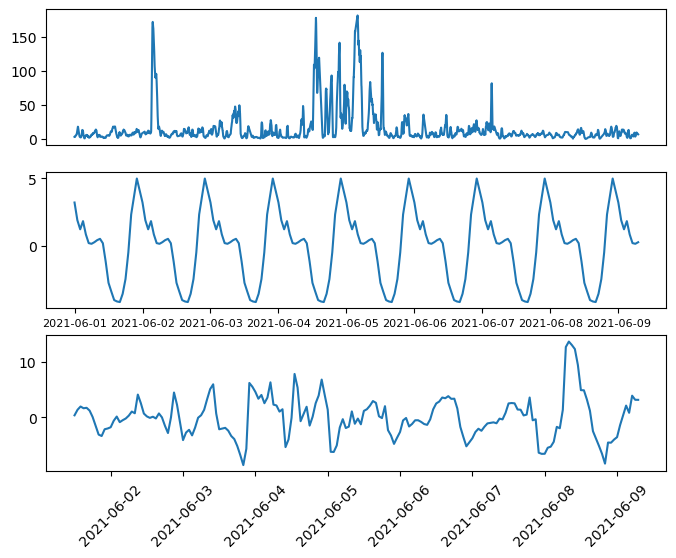

3859


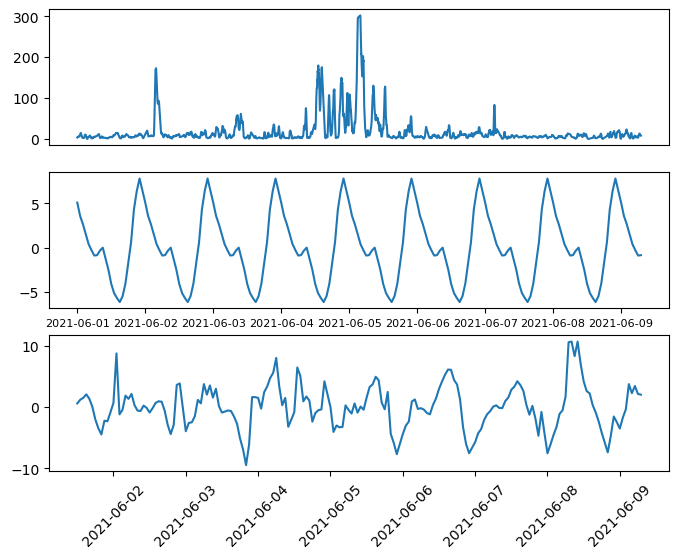

3915


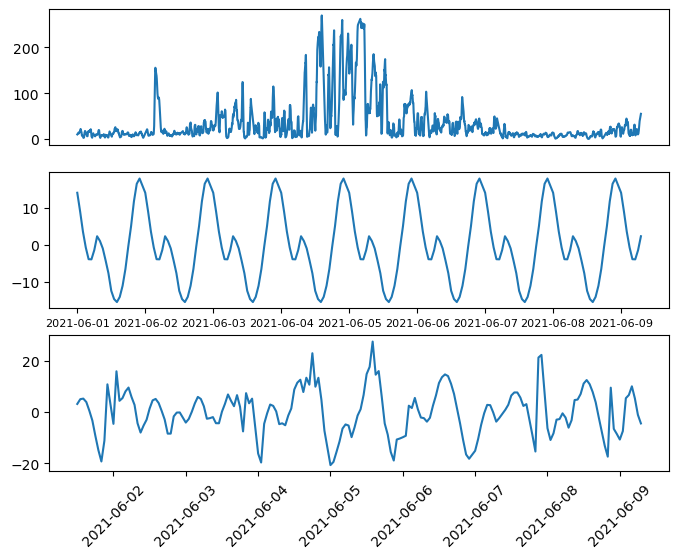

4227


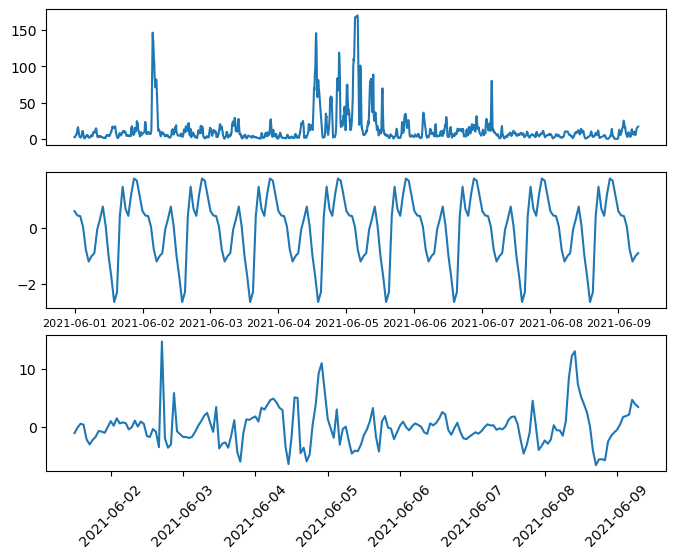

4228


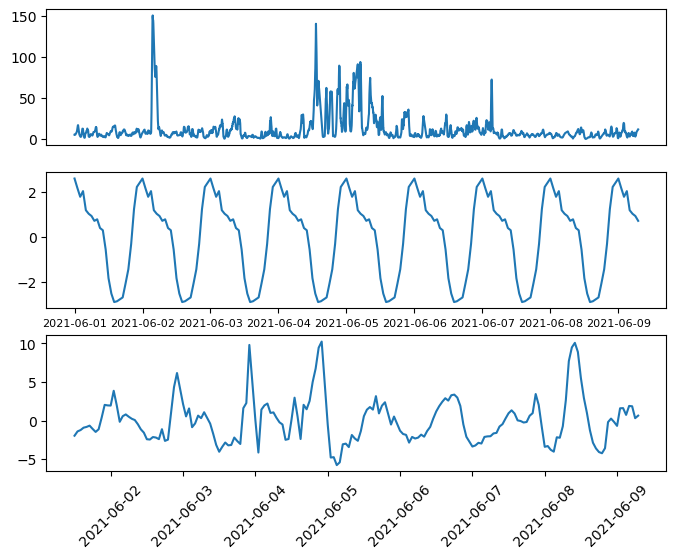

In [59]:
for site, group in df.groupby('site'):
    group['time'] = pd.to_datetime(group['time'])
    date_index = pd.date_range("06.01.2021","10.01.2022",freq='1h')
    decompose = seasonal_decompose(group.set_index('time')['pm25'].loc[date_index],period=24)
    print(site)
    plt.figure(figsize=(8,6))
    plt.subplot(3,1,1)
    plt.plot(decompose.trend.iloc[:])
    # plt.title('Trend')
    plt.xticks([])

    plt.subplot(3,1,2)
    plt.plot(decompose.seasonal.iloc[:200])
    # plt.title('Seasonal')
    plt.xticks(fontsize=8)
    # plt.xticks(decompose.seasonal.index[:200])

    plt.subplot(3,1,3)
    plt.plot(decompose.resid.iloc[:200])
    # plt.title('Residuals')
    plt.xticks(rotation=45)
    plt.show()

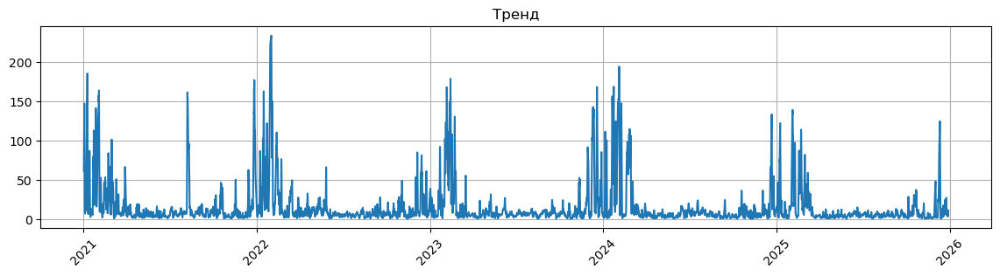

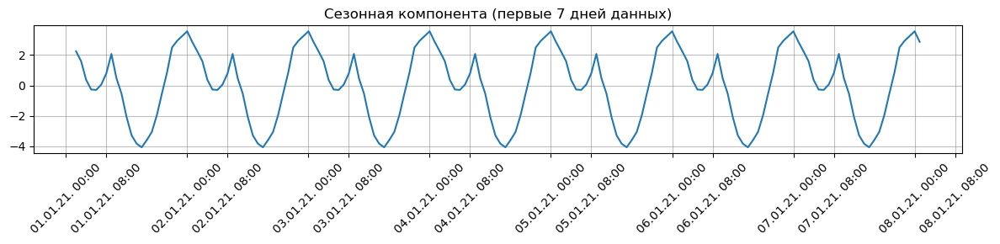

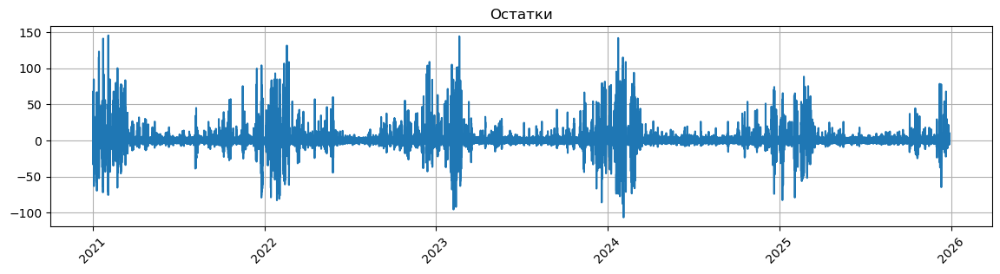

In [153]:
s = df[df['site'] == 3857]
s['time'] = pd.to_datetime(s['time'])
decompose = seasonal_decompose(s.set_index('time')['pm25'],period=24)

plt.figure(figsize=(14,3))
plt.plot(decompose.trend.iloc[:])
plt.grid()
plt.title('Тренд')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12,3))
plt.plot(decompose.seasonal.iloc[:24*7])
ax = plt.gca()
# Настройка Major Grid (каждые 24 часа)
ax.xaxis.set_major_locator(mdates.HourLocator(byhour=0))
# plt.grid(which='major', color='gray', linestyle='-', alpha=0.5)
# # Настройка Minor Grid (каждые 6 часов)
ax.xaxis.set_major_locator(mdates.HourLocator(byhour=[8, 0]))
plt.grid(which='major', color='gray', linestyle='-', alpha=0.5)
# Форматирование подписей
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m.%y. %H:%M'))
plt.xticks(rotation=45)
plt.title('Сезонная компонента (первые 7 дней данных)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14,3))
plt.plot(decompose.resid.iloc[:])
plt.grid()
plt.title('Остатки')
plt.xticks(rotation=45)
plt.show()

In [157]:
decompose.resid.mean(), decompose.resid.std()

(0.00279345869362145, 11.898823761600452)

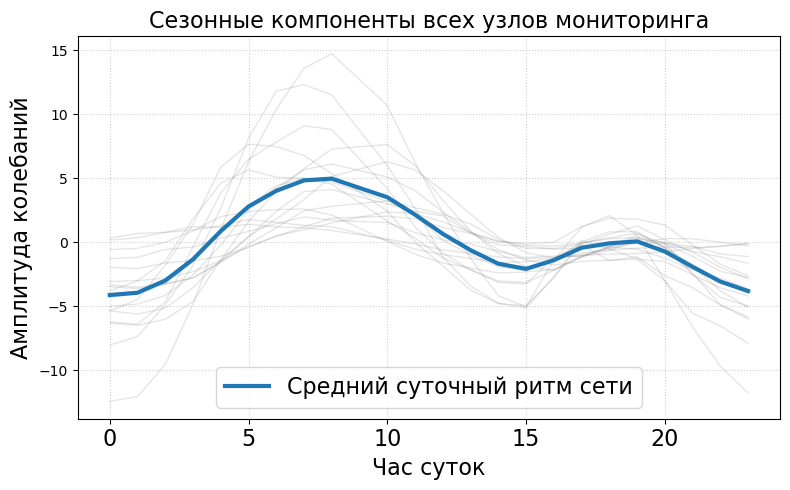

In [14]:

# Параметры
period = 24
all_seasonal = []

plt.figure(figsize=(8, 5))

# Проходим по датчикам, как в ACF
for site, group in df.groupby('site'):
    # Важно: для seasonal_decompose нужен непрерывный ряд без пропусков
    # Берем срез данных (например, первый месяц), ресемплим по часам
    y = group.set_index('time')['pm25'].resample('H').mean().fillna(method='ffill')
    
    if len(y) > period * 2:
        res = seasonal_decompose(y, model='additive', period=period)
        
        # Берем только один цикл (24 часа) из полученной компоненты
        # Seasonal всегда повторяется, так что первых 24 значений достаточно
        seasonal_cycle = res.seasonal.iloc[:period].values
        all_seasonal.append(seasonal_cycle)
        
        # Рисуем "спагетти"
        plt.plot(seasonal_cycle, color='gray', alpha=0.2, linewidth=1)

# Средний ритм города
mean_seasonal = np.mean(all_seasonal, axis=0)
plt.plot(mean_seasonal, color='#1f77b4', linewidth=3, label='Средний суточный ритм сети')

# Оформление в стиле ACF
plt.title('Cезонные компоненты всех узлов мониторинга',fontsize=16)
plt.xlabel('Час суток',fontsize=16)
plt.ylabel('Амплитуда колебаний',fontsize=16)
# plt.axvline(x=6, color='red', linestyle=':', alpha=1, label='Утренний пик')
# plt.axvline(x=20, color='red', linestyle=':', alpha=1, label='Вечерний пик')
plt.xticks(fontsize=16)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=16)

plt.tight_layout()
plt.show()

In [597]:
weather = df[df["site"]==3857].drop(['site', 'lat', 'long', 'h', 'pm25'],axis=1).reset_index(drop=True)
hourly_avg = df.groupby('time')['pm25'].median()
mean_data = pd.merge(weather, hourly_avg, on="time")
mean_data = mean_data.set_index('time',drop=True)

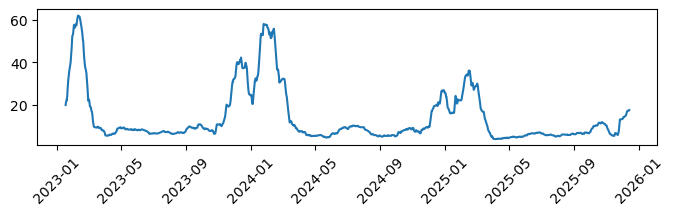

In [603]:
decompose = seasonal_decompose(mean_data['pm25'],period=24*30)
plt.figure(figsize=(8,6))
plt.subplot(3,1,1)
plt.plot(decompose.trend.iloc[:])
plt.xticks(rotation=45)
plt.show()

3837


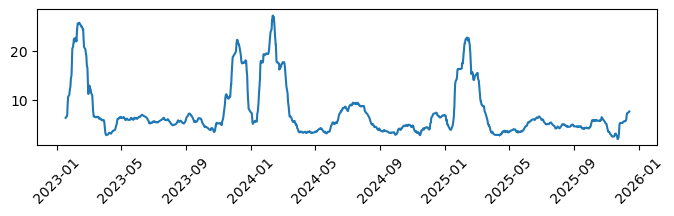

3841


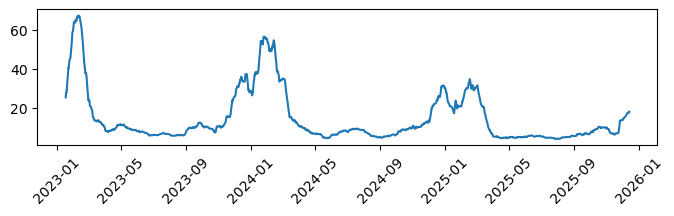

3842


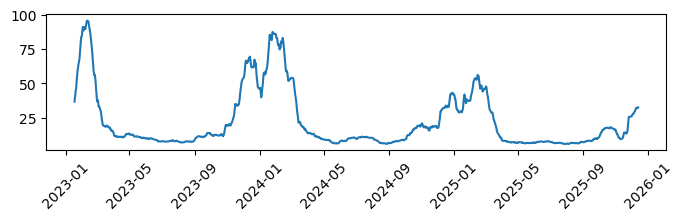

3843


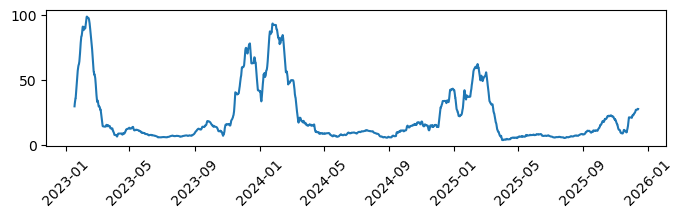

3847


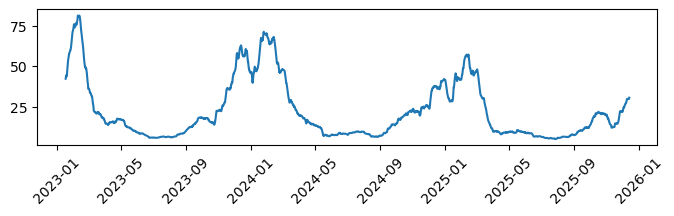

3849


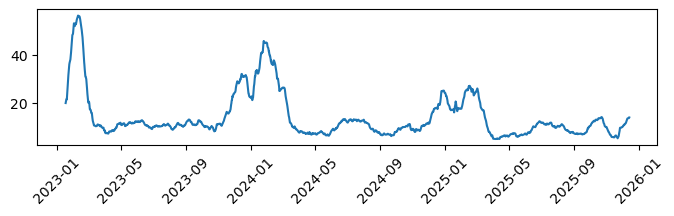

3851


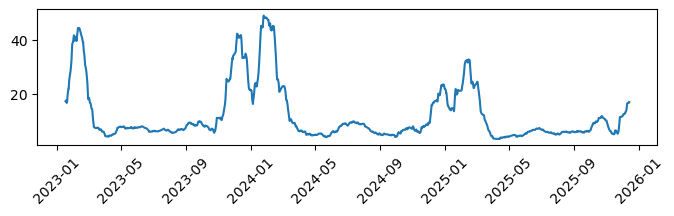

3853


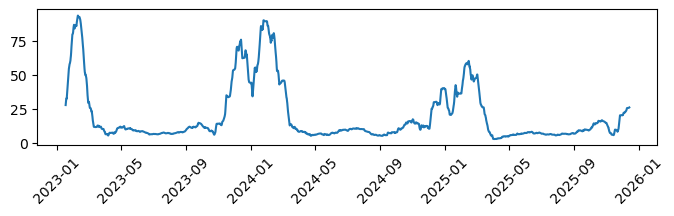

3854


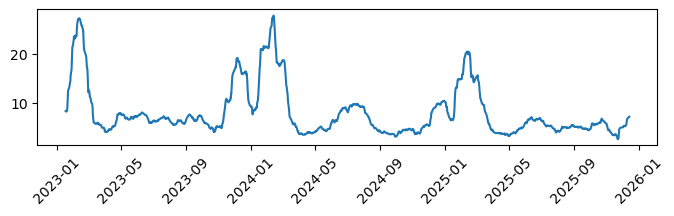

3855


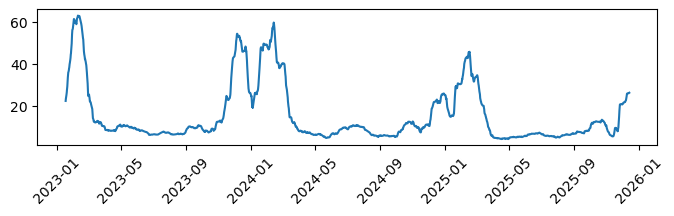

3856


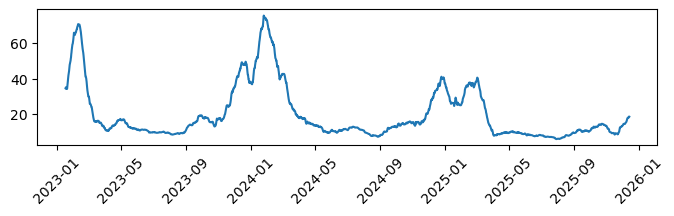

3857


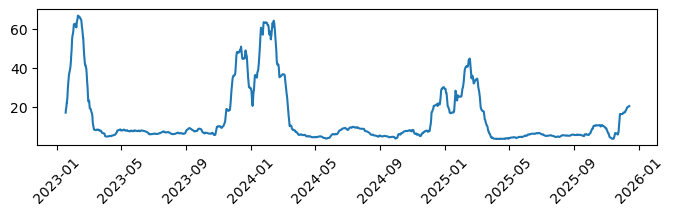

3858


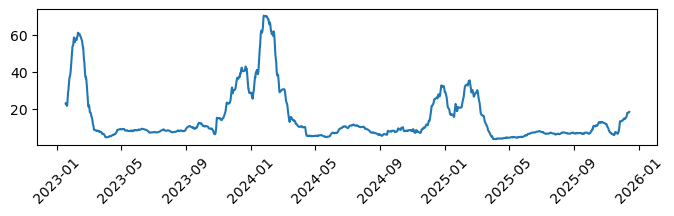

3859


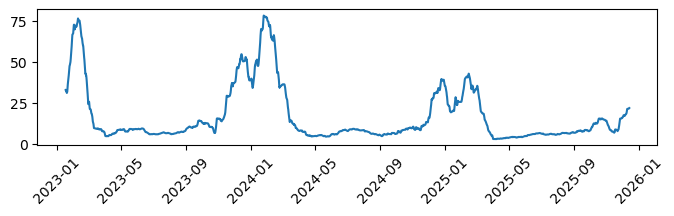

3915


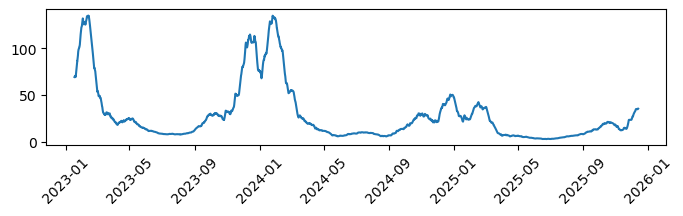

4227


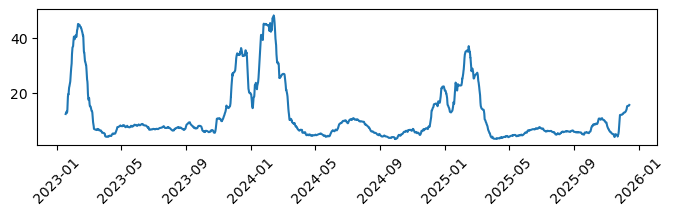

4228


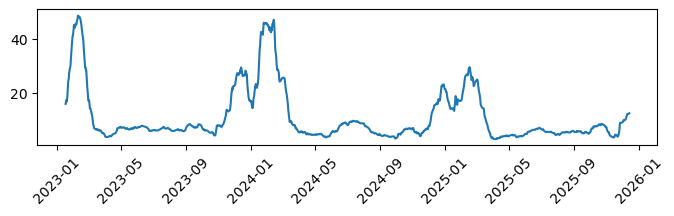

In [594]:
for site, group in df.groupby('site'):
    group['time'] = pd.to_datetime(group['time'])
    decompose = seasonal_decompose(group.set_index('time')['pm25'],period=24*30)
    print(site)
    plt.figure(figsize=(8,6))
    plt.subplot(3,1,1)
    plt.plot(decompose.trend.iloc[:])
    plt.xticks(rotation=45)
    plt.show()

In [142]:
df['hour'] = df['time'].dt.hour
profile = df.groupby(['hour'])[['pm25']].median().reset_index(drop=True)
profile.rename(columns={'pm25':'pm_trend'},inplace=True)
profile['hour'] = [*range(24)]

In [146]:
df = df.merge(profile, on=['hour'],how='left')

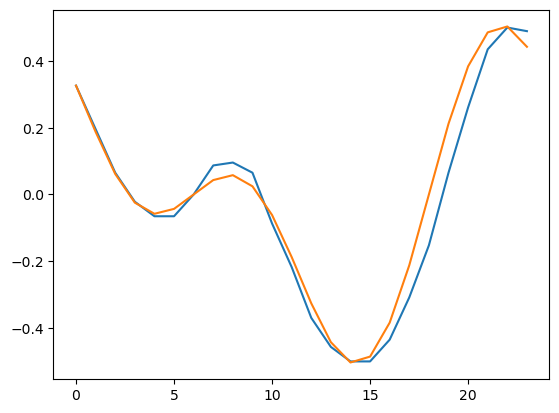

In [790]:
x = np.arange(24)
y = (0.326)*np.cos(2*np.pi/24*x) + \
    (-0.255)*np.sin(2*2*np.pi/24*x)
target = (profile['pm_trend']-profile['pm_trend'].min())/(profile['pm_trend'].max()-profile['pm_trend'].min())-0.5

plt.plot(target)
plt.plot(y)
plt.show()

In [682]:
import torch
from kan import KAN

dataset = {
    'train_input': torch.tensor(x, dtype=torch.float32).unsqueeze(1),
    'train_label': torch.tensor(target, dtype=torch.float32).unsqueeze(1),
    'test_input': torch.tensor(x, dtype=torch.float32).unsqueeze(1),
    'test_label': torch.tensor(target, dtype=torch.float32).unsqueeze(1),
}

In [768]:
trend_model = KAN([1,4,1])

checkpoint directory created: ./model
saving model version 0.0


In [774]:
res = trend_model.fit(dataset,steps=100,lamb=0.001,lr=1)

| train_loss: 1.90e-02 | test_loss: 1.90e-02 | reg: 5.89e+00 | : 100%|█| 100/100 [00:10<00:00,  9.67

saving model version 0.2


In [764]:
res = trend_model.fit(dataset,steps=50,lamb=0,lr=0.1)

| train_loss: 6.61e-03 | test_loss: 6.61e-03 | reg: 1.46e+01 | : 100%|█| 50/50 [00:05<00:00,  9.49it

saving model version 0.2


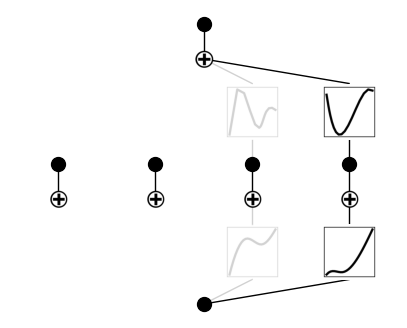

In [776]:
# trend_model = trend_model.prune()
trend_model.plot()

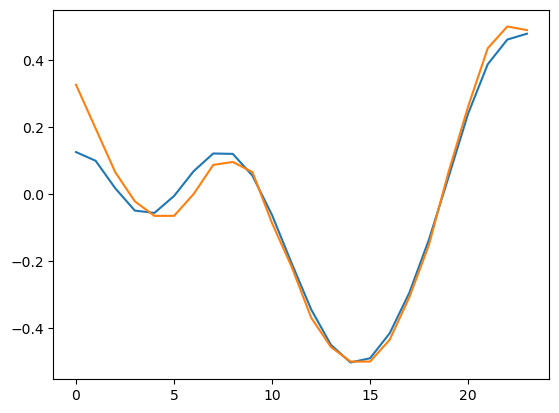

In [745]:
plt.plot(trend_model(dataset['train_input']).detach().numpy())
plt.plot(target)
plt.show()

In [747]:
trend_model.auto_symbolic()

fixing (0,0,0) with 0, r2=0.0, c=0
fixing (0,0,1) with x, r2=0.9931159615516663, c=1
fixing (0,0,2) with 0, r2=0.0, c=0
fixing (0,0,3) with 0, r2=0.0, c=0
fixing (0,0,4) with 0, r2=0.0, c=0
fixing (0,0,5) with 0, r2=0.0, c=0
fixing (0,0,6) with 0, r2=0.0, c=0
fixing (0,0,7) with 0, r2=0.0, c=0
fixing (1,0,0) with 0, r2=0.0, c=0
fixing (1,0,1) with 0, r2=0.0, c=0
fixing (1,0,2) with 0, r2=0.0, c=0
fixing (1,0,3) with 0, r2=0.0, c=0
fixing (1,1,0) with 0, r2=0.0, c=0
fixing (1,1,1) with 0, r2=0.0, c=0
fixing (1,1,2) with sin, r2=0.9983800053596497, c=2
fixing (1,1,3) with 0, r2=0.0, c=0
fixing (1,2,0) with 0, r2=0.0, c=0
fixing (1,2,1) with 0, r2=0.0, c=0
fixing (1,2,2) with x, r2=0.9708149433135986, c=1
fixing (1,2,3) with 0, r2=0.0, c=0
fixing (1,3,0) with 0, r2=0.0, c=0
fixing (1,3,1) with 0, r2=0.0, c=0
fixing (1,3,2) with 0, r2=0.0, c=0
fixing (1,3,3) with 0, r2=0.0, c=0
fixing (1,4,0) with 0, r2=0.0, c=0
fixing (1,4,1) with 0, r2=0.0, c=0
fixing (1,4,2) with exp, r2=0.9969111084938

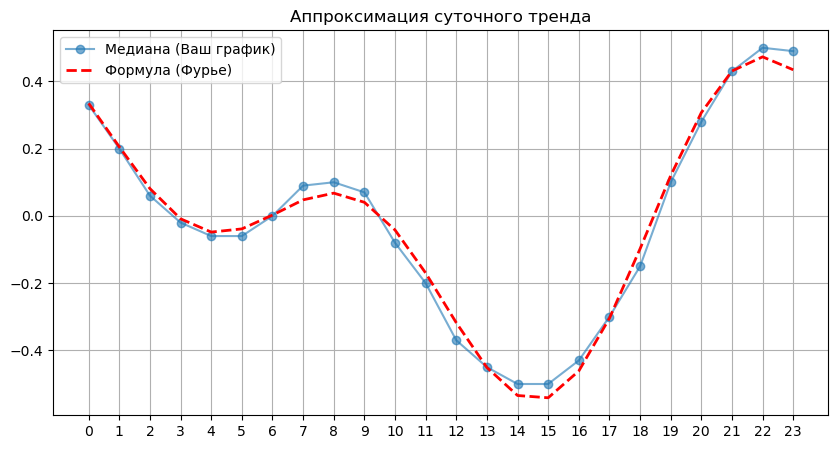

Итоговые коэффициенты:
Bias: -0.0196, C1: 0.3263, S1: 0.0501, C2: 0.0281, S2: -0.2553

ВАША СИНТЕТИЧЕСКАЯ ФОРМУЛА:
SyntTrend(t) = -0.020 + (0.326)*cos(2*pi/24*t) + (0.050)*sin(2*pi/24*t) + (0.028)*cos(2*2*pi/24*t) + (-0.255)*sin(2*2*pi/24*t)


In [750]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# 1. Восстанавливаем ваши медианные значения по графику (аппроксимация на глаз)
# Вы подставьте сюда точный массив своих медиан!
target_values = np.array([
    0.33,  # 0ч
    0.20,  # 1ч
    0.06,  # 2ч
   -0.02,  # 3ч
   -0.06,  # 4ч
   -0.06,  # 5ч
    0.00,  # 6ч
    0.09,  # 7ч
    0.10,  # 8ч
    0.07,  # 9ч
   -0.08,  # 10ч
   -0.20,  # 11ч
   -0.37,  # 12ч
   -0.45,  # 13ч
   -0.50,  # 14ч
   -0.50,  # 15ч
   -0.43,  # 16ч
   -0.30,  # 17ч
   -0.15,  # 18ч
    0.10,  # 19ч
    0.28,  # 20ч
    0.43,  # 21ч
    0.50,  # 22ч
    0.49   # 23ч
])

hours = np.arange(24)

# 2. Определяем функцию Фурье (две гармоники)
def fourier_func(params, t):
    bias, c1, s1, c2, s2 = params
    w = 2 * np.pi / 24  # основная частота (24ч)
    return bias + c1*np.cos(w*t) + s1*np.sin(w*t) + c2*np.cos(2*w*t) + s2*np.sin(2*w*t)

# 3. Функция ошибки (что минимизируем)
def error_func(params, t, y_true):
    return fourier_func(params, t) - y_true

# 4. Подбор коэффициентов методом наименьших квадратов
initial_guess = [0, 0, 0, 0, 0]
res = least_squares(error_func, initial_guess, args=(hours, target_values))
best_params = res.x

# 5. Генерация синтетической кривой
synthetic_values = fourier_func(best_params, hours)

# 6. Визуализация результата для проверки
plt.figure(figsize=(10, 5))
plt.plot(hours, target_values, 'o-', label='Медиана (Ваш график)', alpha=0.6)
plt.plot(hours, synthetic_values, 'r--', label='Формула (Фурье)', linewidth=2)
plt.title('Аппроксимация суточного тренда')
plt.grid(True)
plt.legend()
plt.xticks(hours)
plt.show()

# 7. Вывод итоговой формулы
b, c1, s1, c2, s2 = best_params
print("Итоговые коэффициенты:")
print(f"Bias: {b:.4f}, C1: {c1:.4f}, S1: {s1:.4f}, C2: {c2:.4f}, S2: {s2:.4f}")

omega = "2*pi/24"
formula = f"SyntTrend(t) = {b:.3f} + ({c1:.3f})*cos({omega}*t) + ({s1:.3f})*sin({omega}*t) + ({c2:.3f})*cos(2*{omega}*t) + ({s2:.3f})*sin(2*{omega}*t)"
print("\nВАША СИНТЕТИЧЕСКАЯ ФОРМУЛА:")
print(formula)

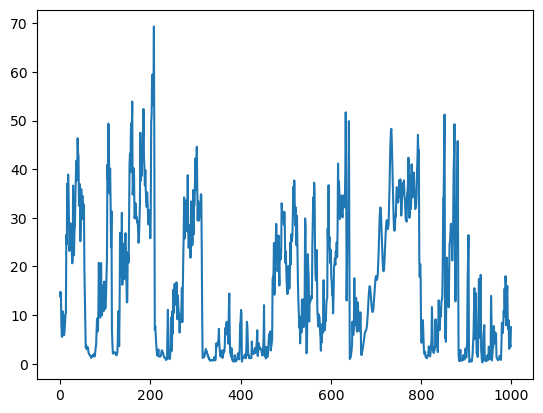

In [822]:
plt.plot((df[df['site']==3915]['pm25']/df[df['site']==3915]['pm_trend']).values[:1000])
plt.show()

# Проверка на стационарность

In [47]:
for site, group in df.groupby('site'):
    result = adfuller(group['pm25'], autolag='AIC')
    print(f'{site} pvalue: {result[1]:.4f}')

3837 pvalue: 0.0000
3841 pvalue: 0.0000
3842 pvalue: 0.0000
3843 pvalue: 0.0000
3847 pvalue: 0.0000
3849 pvalue: 0.0000
3851 pvalue: 0.0000
3853 pvalue: 0.0000
3854 pvalue: 0.0000
3855 pvalue: 0.0000
3856 pvalue: 0.0000
3857 pvalue: 0.0000
3858 pvalue: 0.0000
3859 pvalue: 0.0000
3915 pvalue: 0.0000
4227 pvalue: 0.0000
4228 pvalue: 0.0000


# Поиск тренда

In [959]:
# Ядро Епанечникова
def EP_core(x):
    if abs(x) <= 1:
        return 0.75*(1-x**2)
    elif abs(x) > 0:
        return 0

# Гауссово ядро
def GAUSS_core(x):
    if abs(x) <= 1:
        return (1+2*abs(x))*((1-2*abs(x))**2)
    elif abs(x) > 1:
        return 0

# Треугольное ядро
def TR_core(x):
    if abs(x) <= 1:
        return 1-abs(x)
    elif abs(x) > 1:
        return 0

def error(e):
    raise Exception('Incorrect core')
    
cores = {'EP': EP_core,
         'GAUSS': GAUSS_core,
         'TR': TR_core}

# Ядерная регрессия

def restored_x(vector_x, h, X, Y, core):
    denominator = 0
    numerator = 0
    sub = 1
    
    # знаменатель
    for i in range(len(X)):
        for j in range(len(X[i])):
            sub *= core((vector_x[j]-X[i][j])/h)
        denominator += sub
        sub = 1
            
    # числитель
    for i in range(len(X)):
        for j in range(len(X[i])):
            sub *= core((vector_x[j]-X[i][j])/h)
        numerator += sub*Y[i]
        sub = 1
                
    output = numerator/(denominator+0.0000000001)
    
    return output

def core_regression(data_x, data_y, h, core_name):
    core = cores.get(core_name, error)
    restored_regression = []
    i = 1
    for x in data_x:
        restored_regression.append(restored_x(x, h, data_x, data_y, core))
        clear_output(wait=True)
        print(f'{round(i/len(data_x)*100,3)}%')
        i += 1
    # print('Complete')
    return np.array(restored_regression)

In [513]:
site1

,site,lat,long,h,pm25,temperature_2m (°C),relative_humidity_2m (%),pressure_msl (hPa),surface_pressure (hPa),temperature_80m (°C),...,dew_point_2m (°C),pm_trend,etalon_signal,q_adv,t_travel,alt_diff,p_nmu_KAN,dp_nmu_KAN,pnmu_RiKAN_x,pnmu_RiKAN_y
time,,,,,,,,,,,,,,,,,,,,,
2023-01-02 01:00:00,3847,56.07743,92.70456,226,82.5,-8.2,81,1036.2,1012.5,-6.8,...,-10.9,7.400000,7.493621,1.471074,6.803740,-63.613685,0.883416,0.021328,0.202441,0.555028
2023-01-02 02:00:00,3847,56.07743,92.70456,226,87.9,-8.8,81,1037.1,1013.3,-6.8,...,-11.4,6.900000,6.960263,1.526063,7.705440,-63.029465,0.910677,0.027261,0.182739,0.511963
2023-01-02 03:00:00,3847,56.07743,92.70456,226,74.5,-10.1,83,1036.8,1012.9,-7.0,...,-12.4,6.600000,6.600000,0.810471,6.914071,-67.734771,0.928011,0.017335,0.208618,0.651094
2023-01-02 04:00:00,3847,56.07743,92.70456,226,23.6,-9.7,82,1037.2,1013.3,-7.1,...,-12.2,6.300000,6.455791,0.599875,6.767741,-68.761198,0.922854,-0.005158,0.208618,0.651094
2023-01-02 05:00:00,3847,56.07743,92.70456,226,15.4,-8.0,81,1036.4,1012.7,-7.2,...,-10.7,6.325676,6.325676,0.473753,6.914071,-69.801986,0.887169,-0.035685,0.160895,0.501697
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-28 18:00:00,3847,56.07743,92.70456,226,38.4,-14.1,83,1030.0,1005.9,-12.7,...,-16.3,6.200000,6.200000,0.590354,12.920233,-68.761198,0.653884,0.012919,0.195278,0.222905
2025-12-28 19:00:00,3847,56.07743,92.70456,226,39.8,-14.0,84,1030.1,1006.0,-12.4,...,-16.1,7.000000,8.556119,0.266482,13.903294,-68.227686,0.679153,0.025268,0.174949,0.299192
2025-12-28 20:00:00,3847,56.07743,92.70456,226,61.7,-13.9,85,1030.3,1006.2,-12.3,...,-15.9,7.800000,10.111979,0.117782,14.056078,-64.562273,0.674287,-0.004866,0.208618,0.498202


In [515]:
site1 = df[df['site'] == 3847].reset_index(drop=True)
site1['time'] = pd.to_datetime(site1['time'])
site1 = site1.set_index('time')

window = 24
data_len = site1.shape[0]
edge = (data_len // window) * window

site1 = site1.iloc[:edge]

In [485]:
WINDOW = 24
trend1 = site1['pm25'].rolling(window=WINDOW, center=True).mean().values.flatten()
trend1[:WINDOW//2] = trend1[WINDOW//2]
trend1[site1.shape[0]-WINDOW//2:] = trend1[site1.shape[0]-WINDOW//2]

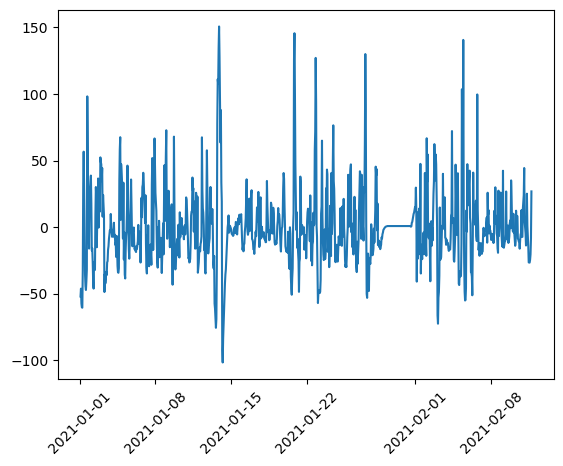

In [487]:
plt.plot((site1['pm25']-trend1)[:1000])
# plt.plot(site1.index, trend)
plt.xticks(rotation=45)
plt.show()

In [177]:
dec = seasonal_decompose(site1['pm25']-trend1,period=24)

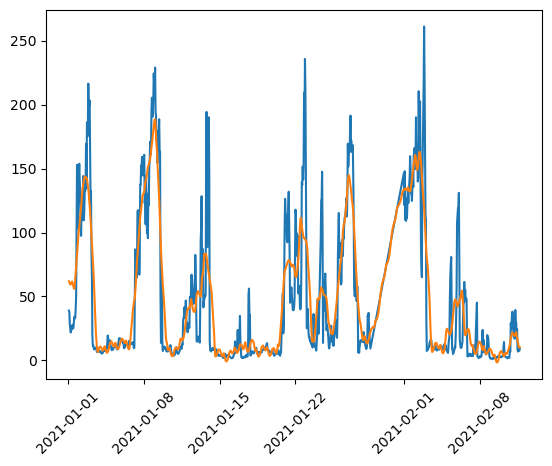

In [179]:
plt.plot(site1['pm25'].iloc[:1000])
plt.plot((dec.seasonal+trend1)[:1000])
plt.xticks(rotation=45)
plt.show()

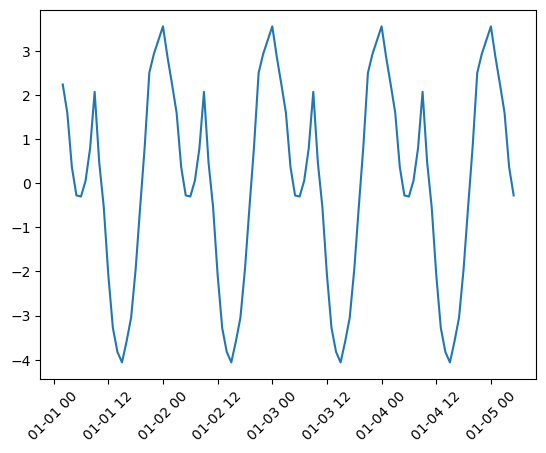

In [183]:
plt.plot(dec.seasonal[:100])
plt.xticks(rotation=45)
plt.show()

# Сингулярное разложение

In [185]:
def components(U,S,VT,a,b):
    u = U[:, range(a, b)]
    s = np.diag(S)[a:b, a:b]
    vt = VT[range(a, b), :]
    res_a = u @ s @ vt
    return res_a

In [288]:
for site, group in df.groupby('site'):
    print(site, group.shape[0])

3837 43750
3841 43750
3842 43750
3843 43750
3847 43750
3849 43750
3851 43750
3853 43750
3854 43750
3855 43750
3856 43750
3857 43750
3858 43750
3859 43750
3915 43750
4227 43750
4228 43750


In [1173]:
reshaped_data = site1['inflow'].values.reshape(data_len//window,window)
u, s, vt = svd(reshaped_data)

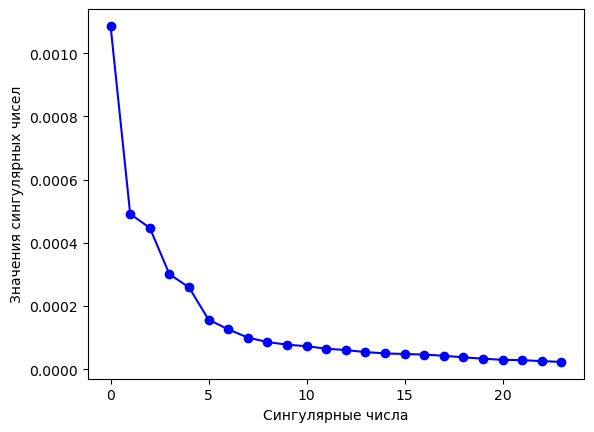

In [1175]:
plt.plot([*range(len(s))],s,'b-o')
plt.xlabel('Сингулярные числа')
plt.ylabel('Значения сингулярных чисел')
plt.show()

In [1181]:
harmonic1 = components(u,s,vt,0,1).flatten()
harmonic2 = components(u,s,vt,1,2).flatten()
harmonic3 = components(u,s,vt,2,3).flatten()
harmonic4 = components(u,s,vt,3,4).flatten()
harmonic4 = components(u,s,vt,4,5).flatten()

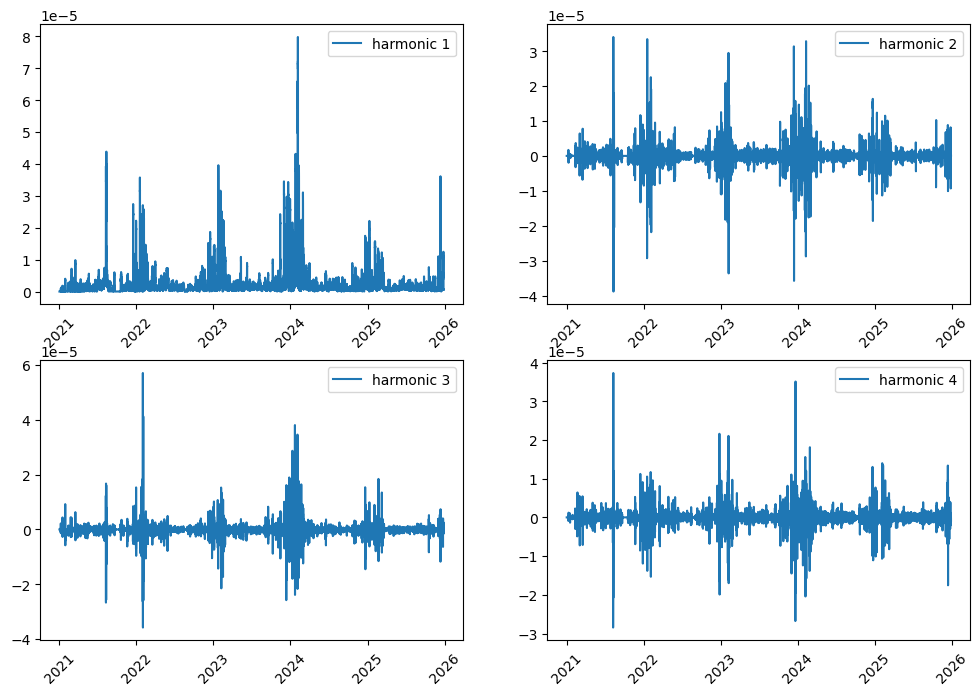

In [1183]:
plt.figure(figsize=(12,8))
for i, harm in enumerate([harmonic1,
                          harmonic2,
                          harmonic3,
                          harmonic4]):
    plt.subplot(2,2,i+1)
    plt.plot(pd.to_datetime(site1.index), harm, label=f'harmonic {i+1}')
    plt.xticks(rotation=45)
    plt.legend()
plt.show()

In [298]:
np.sqrt(mean_squared_error(site1['pm25'],harmonic1+harmonic2+harmonic3+harmonic4))

6.9931859014235505

In [300]:
mean_absolute_error(site1['pm25'],harmonic1)

5.4223038573804

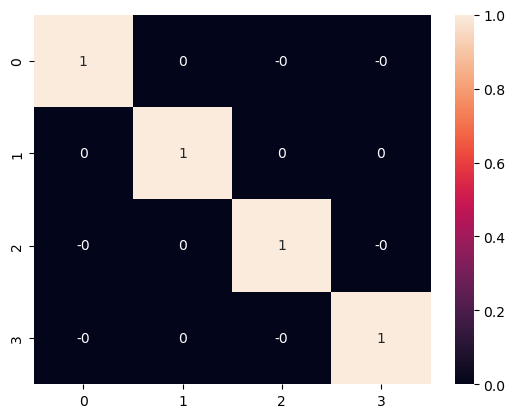

In [1185]:
sns.heatmap(np.corrcoef([harmonic1,harmonic2,harmonic3,harmonic4]).round(2),annot=True)
plt.show()

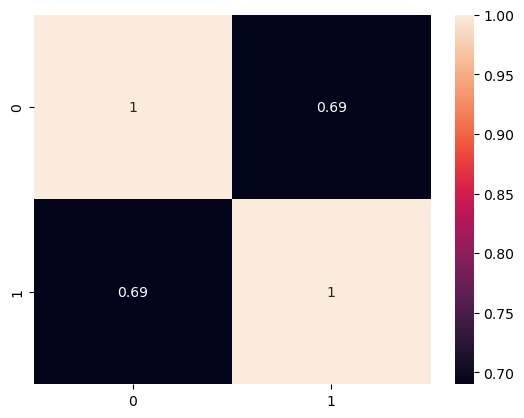

In [1187]:
sns.heatmap(np.corrcoef([harmonic1,np.abs(harmonic2+harmonic3+harmonic4)]).round(2),annot=True)
plt.show()

In [1189]:
seasonal1 = harmonic1-trend1+harmonic2+harmonic3+harmonic4

NameError: name 'trend1' is not defined

In [1191]:
sns.heatmap(np.corrcoef([harmonic1,seasonal1]).round(2),annot=True)
plt.show()

NameError: name 'seasonal1' is not defined

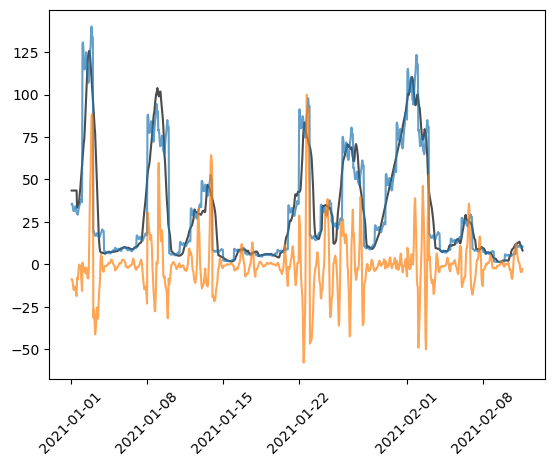

In [314]:
plt.plot(site1.index[:1000],trend1[:1000],alpha=0.7,color='black')
plt.plot(site1.index[:1000],harmonic1[:1000],alpha=0.7)
plt.plot(site1.index[:1000],(harmonic1-trend1+harmonic2+harmonic3+harmonic4)[:1000],alpha=0.7)
plt.xticks(rotation=45)
plt.show()

In [316]:
u1, s1, vt1 = svd((site1['pm25'].values-trend1).reshape(data_len//window,window))
harmonic11 = components(u1,s1,vt1,0,1).flatten()
harmonic12 = components(u1,s1,vt1,1,2).flatten()
harmonic13 = components(u1,s1,vt1,2,3).flatten()
harmonic14 = components(u1,s1,vt1,3,4).flatten()

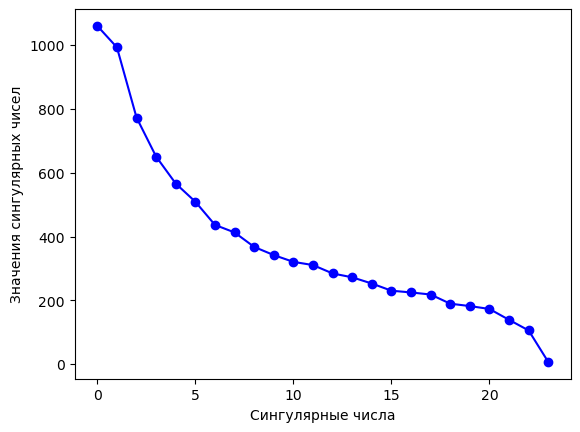

In [318]:
plt.plot([*range(len(s1))],s1,'b-o')
plt.xlabel('Сингулярные числа')
plt.ylabel('Значения сингулярных чисел')
plt.show()

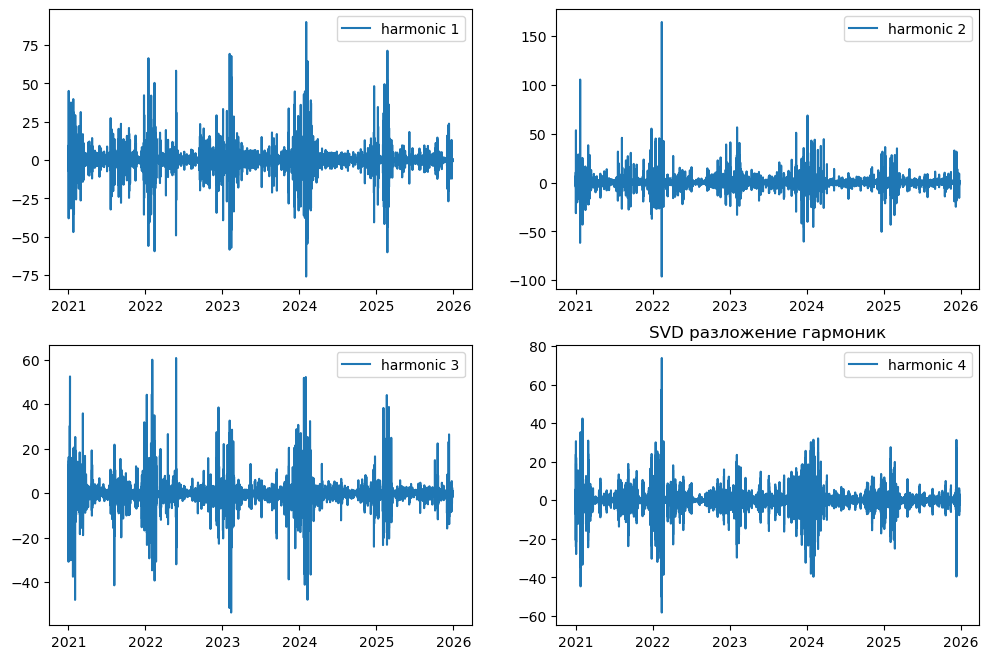

In [320]:
plt.figure(figsize=(12,8))
for i, harm in enumerate([harmonic11,
                          harmonic12,
                          harmonic13,
                          harmonic14]):
    plt.subplot(2,2,i+1)
    plt.plot(pd.to_datetime(site1.index), harm, label=f'harmonic {i+1}')
    plt.legend()
plt.title('SVD разложение гармоник')
plt.show()

In [322]:
seasonal2 = harmonic11

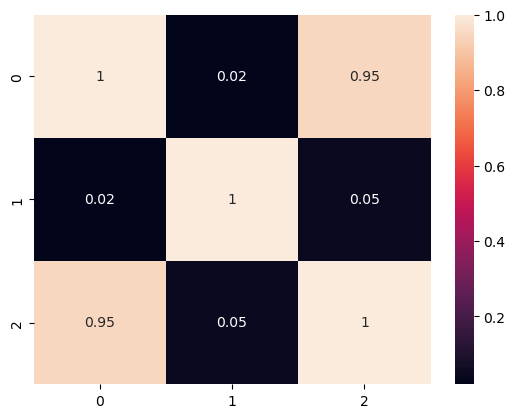

In [324]:
sns.heatmap(np.corrcoef([trend1,harmonic11,harmonic1]).round(2),annot=True)
plt.show()

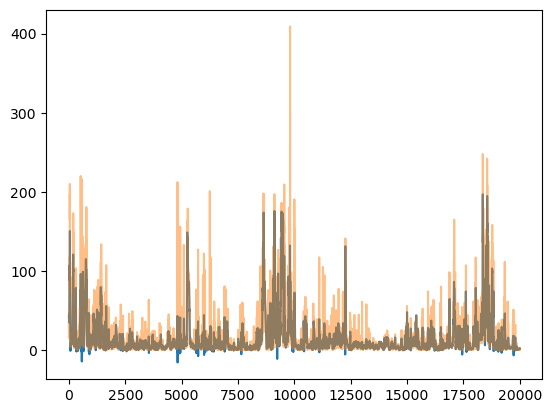

In [326]:
plt.plot((trend1+harmonic11)[:20000])
plt.plot(site1['pm25'].values[:20000],alpha=0.5)

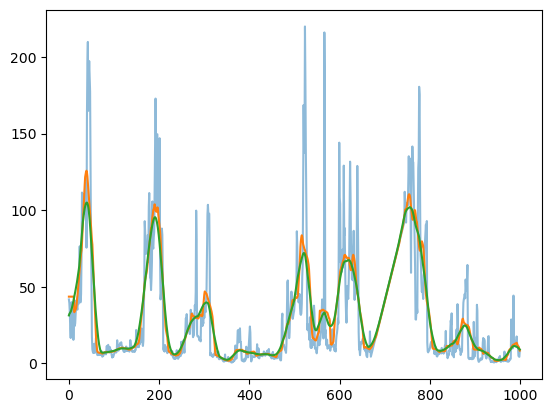

In [499]:
plt.plot(site1['pm25'].values[:1000],alpha=0.5)
plt.plot(trend1[:1000])
plt.plot(trend2[:1000])

# Метод "Гусеница"

In [26]:
def get_ssa_components(series, window=24, components_range=(0, 1)):
    """
    Выполняет SSA декомпозицию и возвращает восстановленный ряд 
    для заданного диапазона сингулярных чисел.
    """
    N = len(series)
    L = window
    K = N - L + 1
    
    # 1. Вложение (Embedding) - создание траекторной матрицы (Ганкелевой)
    # Используем stride_tricks для экономии памяти при создании матрицы
    from numpy.lib.stride_tricks import as_strided
    from scipy.sparse.linalg import svds


    X = as_strided(series, shape=(K, L), strides=(series.strides[0], series.strides[0]))
    
    # 2. Разложение (SVD)
    # Вместо: U, S, VT = svd(X, full_matrices=False)
    U, S, VT = svds(X, k=window-1)

    # plt.plot([*range(len(S))][::-1],S,'b-o')
    # plt.xlabel('Сингулярные числа')
    # plt.ylabel('Значения сингулярных чисел')
    # plt.show()
    
    # ВАЖНО: svds возвращает S в порядке ВОЗРАСТАНИЯ. 
    # Нужно развернуть массивы для привычной логики:
    S = S[::-1]
    U = U[:, ::-1]
    VT = VT[::-1, :]
    
    # 3. Группировка и восстановление аппроксимированной матрицы
    a, b = components_range
    # Вычисляем матрицу только для нужных компонент
    X_hat = (U[:, a:b] * S[a:b]) @ VT[a:b, :]
    
    # 4. Диагональное усреднение (Anti-diagonal averaging)
    # Превращаем матрицу K x L обратно в ряд длиной N
    recovered_series = np.zeros(N)
    counts = np.zeros(N)
    
    for i in range(K):
        for j in range(L):
            recovered_series[i + j] += X_hat[i, j]
            counts[i + j] += 1
            
    return recovered_series / counts

In [517]:
# Пример использования для выделения первой компоненты (Тренда)
trend2 = get_ssa_components(site1['pm25'].values, window=48, components_range=(0, 3))

# Пример для выделения сезонности (обычно компоненты 1 и 2 или 1-3)
seasonal3 = get_ssa_components(site1['pm25'].values, window=48, components_range=(3, 9))

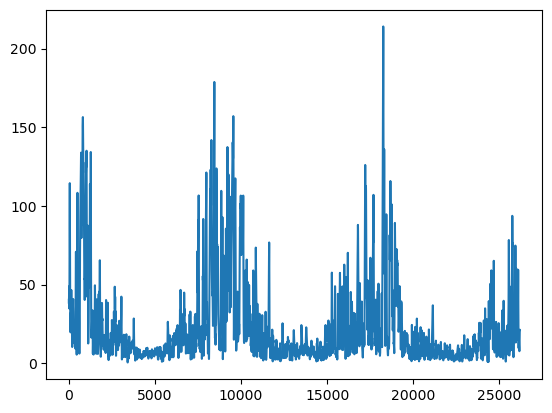

In [519]:
plt.plot(trend2)

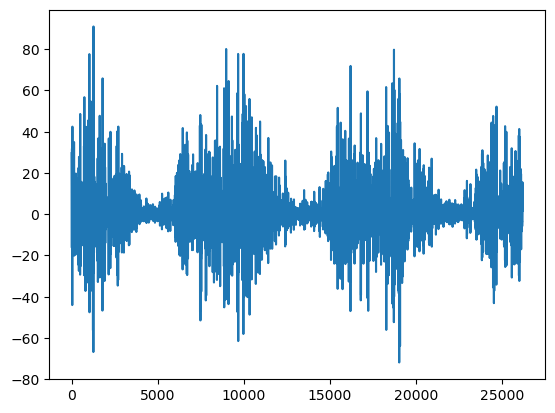

In [521]:
plt.plot(seasonal3)

# FFT

In [28]:
def fourierplot(t, data):
    fourier = np.fft.fft(data)
    freq = np.fft.fftfreq(t.shape[0])
    magnitude = np.abs(fourier)

    plt.figure(figsize=(8,3))
    plt.plot(freq[:t.shape[0]//6], magnitude[:t.shape[0]//6],color="orange",linewidth=3,alpha=1)#,markerfmt='.',linefmt='c-')
    plt.title('Фурье анализ частот', fontsize=12)
    plt.axvline(1/24,color='red',label='Суточный период',alpha=0.65,linestyle='--',linewidth=2)
    plt.axvline(1/12,color='blue',label='12-часовой период',alpha=0.65,linestyle='--',linewidth=2)
    plt.xlabel('Частота [1/час]', fontsize=10)
    plt.ylabel('Амплитуда', fontsize=10)
    plt.legend()
    ax = plt.gca()  
    # ax.set_facecolor("black")
    plt.grid()
    plt.plot()

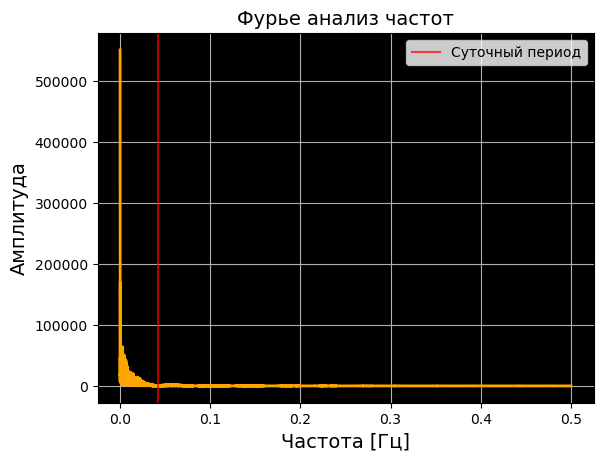

In [542]:
fourierplot(site1.index, trend1)

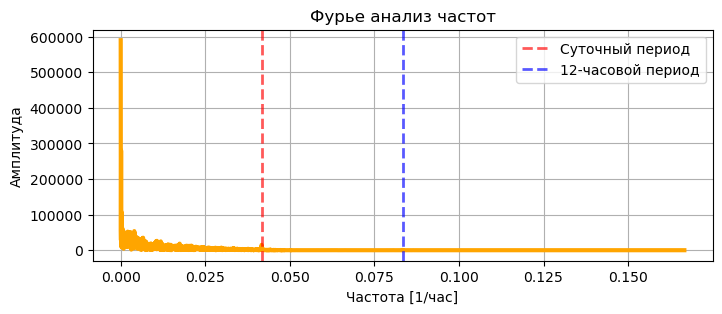

In [523]:
fourierplot(site1.index, trend2)

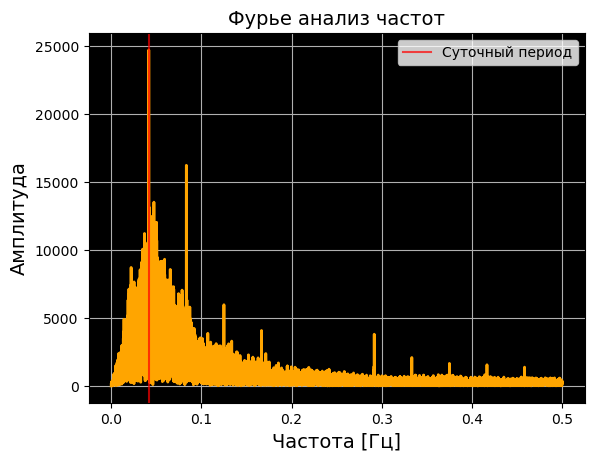

In [470]:
fourierplot(site1.index, seasonal1)

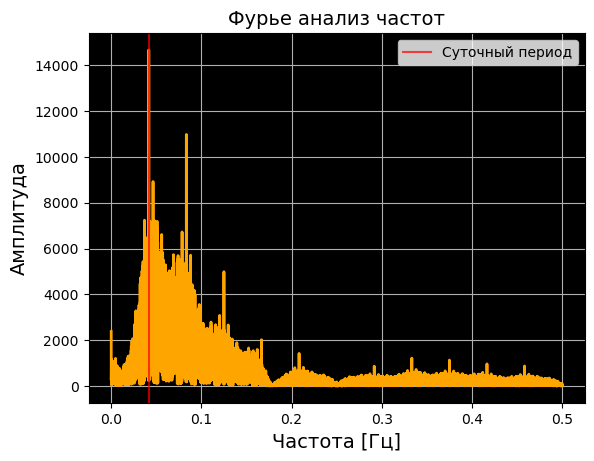

In [471]:
fourierplot(site1.index, seasonal2)

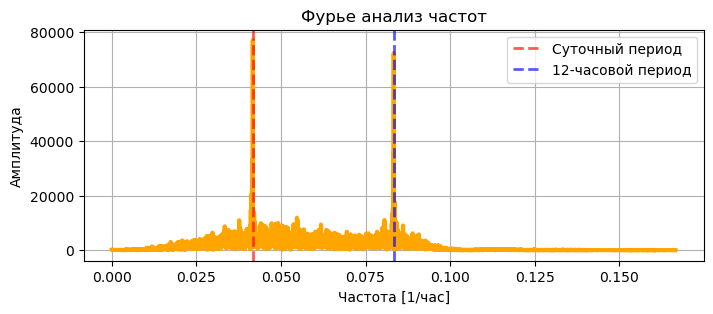

In [525]:
fourierplot(site1.index, seasonal3)

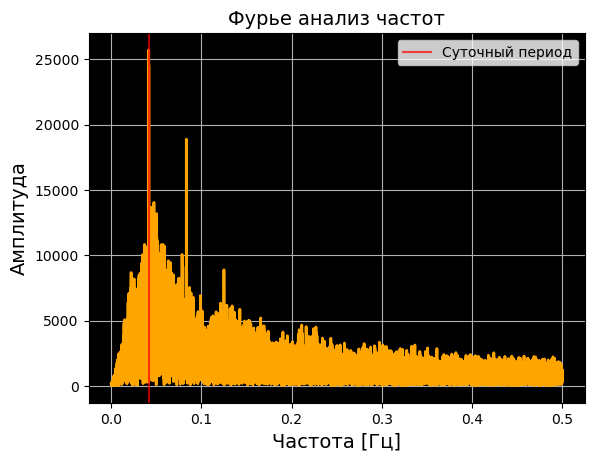

In [475]:
fourierplot(site1.index, site1['pm25']-trend1)

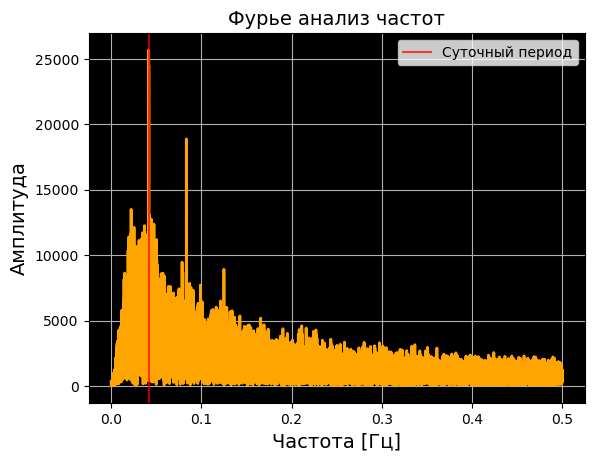

In [479]:
fourierplot(site1.index, site1['pm25']-trend2)

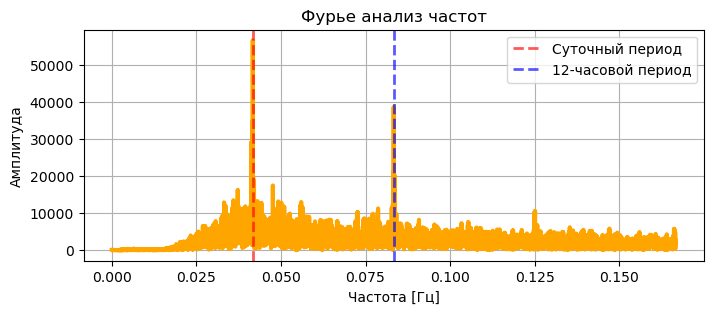

In [398]:
fourierplot(site1.index, site1['pm25']-trend2)

In [533]:
site1

,site,lat,long,h,pm25,temperature_2m (°C),relative_humidity_2m (%),pressure_msl (hPa),surface_pressure (hPa),temperature_80m (°C),...,dew_point_2m (°C),pm_trend,etalon_signal,q_adv,t_travel,alt_diff,p_nmu_KAN,dp_nmu_KAN,pnmu_RiKAN_x,pnmu_RiKAN_y
time,,,,,,,,,,,,,,,,,,,,,
2023-01-02 01:00:00,3847,56.07743,92.70456,226,82.5,-8.2,81,1036.2,1012.5,-6.8,...,-10.9,7.400000,7.493621,1.471074,6.803740,-63.613685,0.883416,0.021328,0.202441,0.555028
2023-01-02 02:00:00,3847,56.07743,92.70456,226,87.9,-8.8,81,1037.1,1013.3,-6.8,...,-11.4,6.900000,6.960263,1.526063,7.705440,-63.029465,0.910677,0.027261,0.182739,0.511963
2023-01-02 03:00:00,3847,56.07743,92.70456,226,74.5,-10.1,83,1036.8,1012.9,-7.0,...,-12.4,6.600000,6.600000,0.810471,6.914071,-67.734771,0.928011,0.017335,0.208618,0.651094
2023-01-02 04:00:00,3847,56.07743,92.70456,226,23.6,-9.7,82,1037.2,1013.3,-7.1,...,-12.2,6.300000,6.455791,0.599875,6.767741,-68.761198,0.922854,-0.005158,0.208618,0.651094
2023-01-02 05:00:00,3847,56.07743,92.70456,226,15.4,-8.0,81,1036.4,1012.7,-7.2,...,-10.7,6.325676,6.325676,0.473753,6.914071,-69.801986,0.887169,-0.035685,0.160895,0.501697
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27 20:00:00,3847,56.07743,92.70456,226,52.9,-15.1,76,1024.4,1000.3,-15.4,...,-18.4,7.800000,9.960706,6.755389,12.664387,-51.931608,0.361378,-0.036644,0.054690,0.141138
2025-12-27 21:00:00,3847,56.07743,92.70456,226,19.3,-15.3,78,1025.0,1000.9,-15.4,...,-18.3,8.400000,8.400000,7.050781,15.791396,-52.371043,0.333066,-0.028312,0.071200,0.191008
2025-12-27 22:00:00,3847,56.07743,92.70456,226,36.4,-15.5,80,1025.2,1001.1,-15.3,...,-18.2,8.675676,11.418709,4.788066,16.611728,-57.025351,0.352022,0.018956,0.123971,0.267024


In [535]:
np.corrcoef([seasonal_decompose(site1['pm25'],period=24).seasonal.values, seasonal3])

array([[1.      , 0.510951],
       [0.510951, 1.      ]])

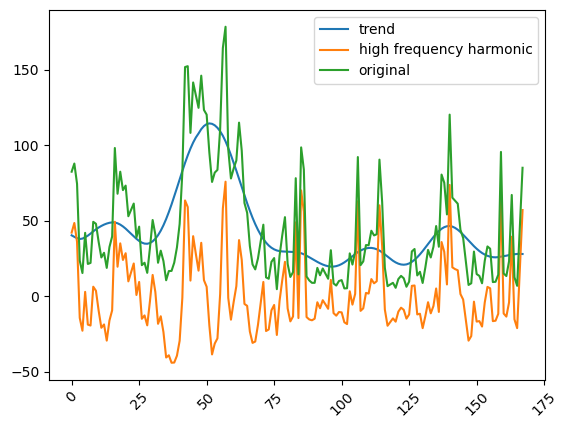

In [572]:
N1, N2 = 0, 24*7

plt.plot(trend2[N1:N2], label='trend')
plt.plot((site1['pm25']-trend2).values[N1:N2], label='high frequency harmonic')
plt.plot((site1['pm25']).values[N1:N2], label='original')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [562]:
site1['hfh'] = site1['pm25']-trend2
site1['trend'] = trend2

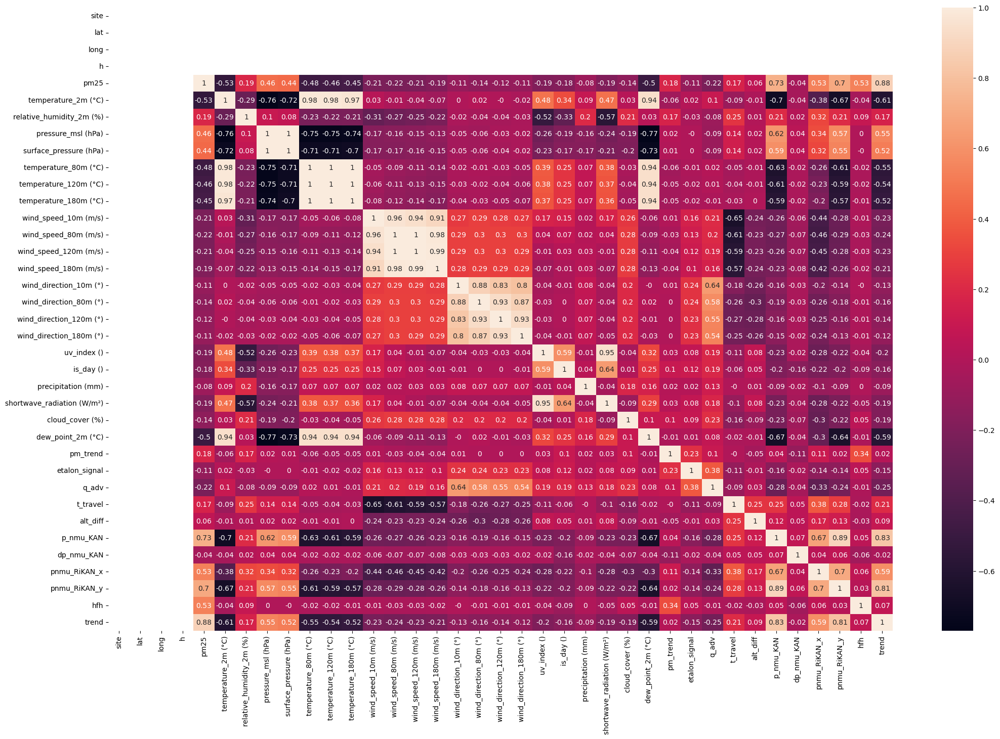

In [564]:
plt.figure(figsize=(25,16))
sns.heatmap(site1.corr().round(2), annot=True)
plt.show()

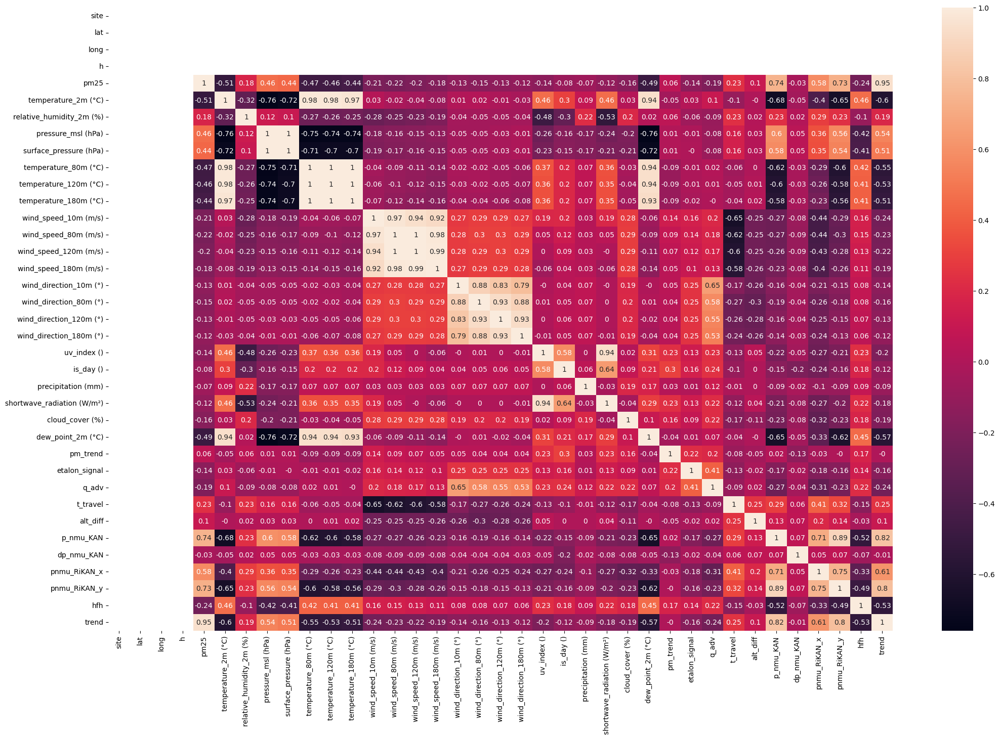

In [566]:
plt.figure(figsize=(25,16))
sns.heatmap(site1[site1['hfh'] < 0].corr().round(2), annot=True)
plt.show()

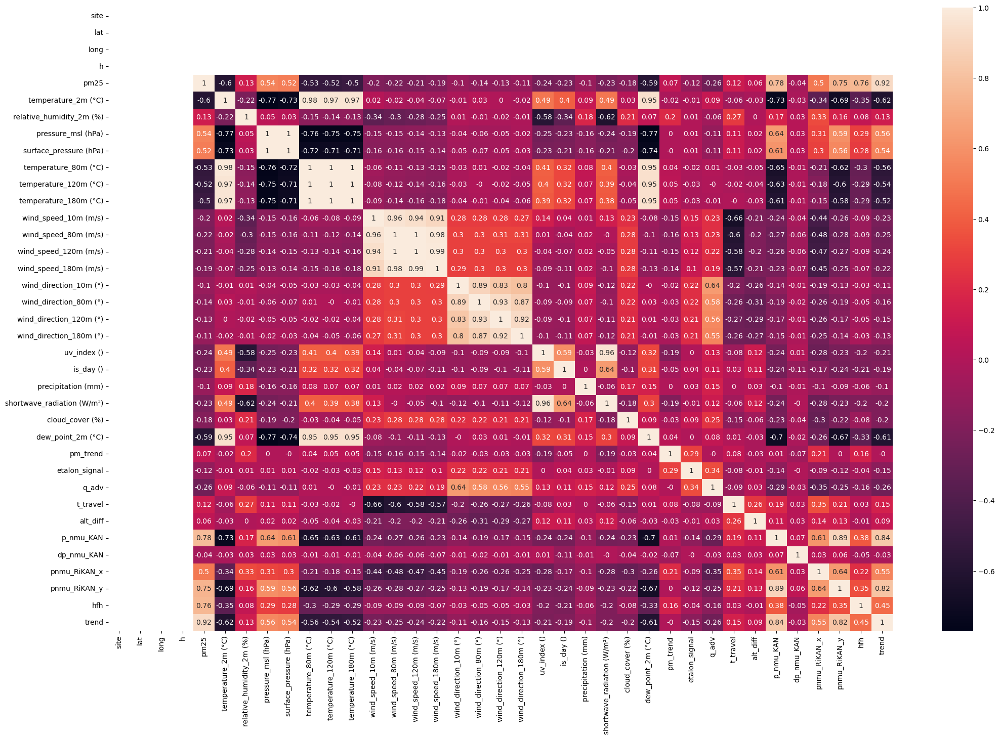

In [568]:
plt.figure(figsize=(25,16))
sns.heatmap(site1[site1['hfh'] >= 0].corr().round(2), annot=True)
plt.show()

In [243]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import as_strided
from scipy.sparse.linalg import svds

def plot_ensemble_analysis(df, window=48, components_range=(3, 11)):
    """
    Строит ансамбль сингулярных чисел и Фурье-спектров для всех датчиков.
    """
    sites = df['site'].unique()
    
    # Списки для хранения результатов
    all_singular_values = []
    all_fourier_mags = []
    freqs = None
    
    # 1. Сбор данных по всем датчикам
    for site in sites:
        series = df[df['site'] == site]['pm25'].resample('H').mean().fillna(method='ffill').values
        if len(series) < window * 2: continue
            
        # SSA часть (только разложение для получения S)
        N, L = len(series), window
        K = N - L + 1
        X = as_strided(series, shape=(K, L), strides=(series.strides[0], series.strides[0]))
        _, S, _ = svds(X, k=window-1)
        S = S[::-1]
        all_singular_values.append(S / S.max()) # Нормируем для визуального сравнения
        
        # SSA восстановление для Фурье (берём компоненты 3-10)
        # Здесь используем твою логику восстановления
        recovered = get_ssa_components(series, window=window, components_range=components_range)
        
        # Фурье часть
        fourier = np.fft.fft(recovered)
        current_freqs = np.fft.fftfreq(len(recovered))
        magnitude = np.abs(fourier)
        
        # Нормируем амплитуду (от 0 до 1)
        magnitude = magnitude / magnitude.max()
        
        all_fourier_mags.append(magnitude)
        freqs = current_freqs

    # # 2. Визуализация
    # fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

    # # График сингулярных чисел
    # for s_vals in all_singular_values:
    #     ax1.plot(s_vals, color='gray', alpha=0.2, linewidth=1)
    # ax1.plot(np.median(all_singular_values, axis=0), color='blue', linewidth=3, label='Медиана')
    # ax1.set_title('Нормированные сингулярные числа (все датчики)',fontsize=12)
    # ax1.set_xlabel('Индекс числа',fontsize=16)
    # ax1.set_ylabel('Относительная значимость',fontsize=16)
    # ax1.grid(True, linestyle=':')

    # График Фурье-ансамбля

    plt.figure(figsize=(12,5))
    
    limit = len(freqs) // 6 # Ограничение частоты как в твоей функции
    for mag in all_fourier_mags:
        plt.plot(freqs[:limit], mag[:limit], color='orange', alpha=0.15, linewidth=1)
    
    mean_mag = np.mean(all_fourier_mags, axis=0)
    plt.plot(freqs[:limit], mean_mag[:limit], color='red', linewidth=2, label='Средний спектр сети')
    
    plt.axvline(1/24, color='black', linestyle='--', alpha=0.8, label='24 часа')
    plt.axvline(1/12, color='black', linestyle='-.', alpha=0.8, label='12 часов')
    plt.title(f'Частотный анализ сети после SSA, компоненты [{components_range[0]}-{components_range[1]})',fontsize=16)
    plt.xlabel('Частота [1/час]',fontsize=16)
    plt.ylabel('Нормированная амплитуда',fontsize=16)
    plt.xticks([1/168, 1/48, 1/24, 1/16, 1/12, 1/8], ['1/168', '1/48', '1/24', '1/16', '1/12', '1/8'],fontsize=16)
    plt.legend(fontsize=16)
    plt.grid(True, linestyle=':')

    # plt.tight_layout()
    plt.show()
    
    return recovered


In [166]:
df = df.set_index(['time'])

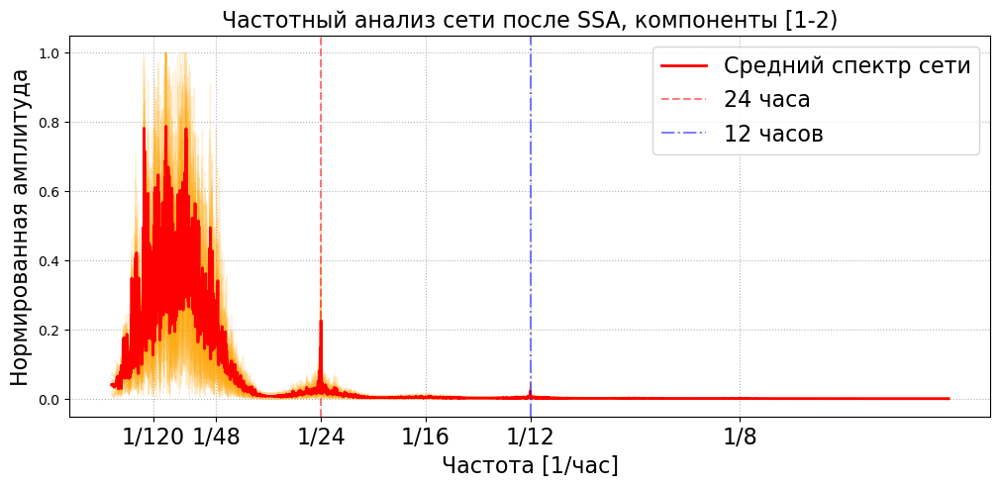

In [204]:
recovered = plot_ensemble_analysis(df,48,(1,2))

In [206]:
s = df[df['site']==3857]
s['1_3_harm'] = recovered

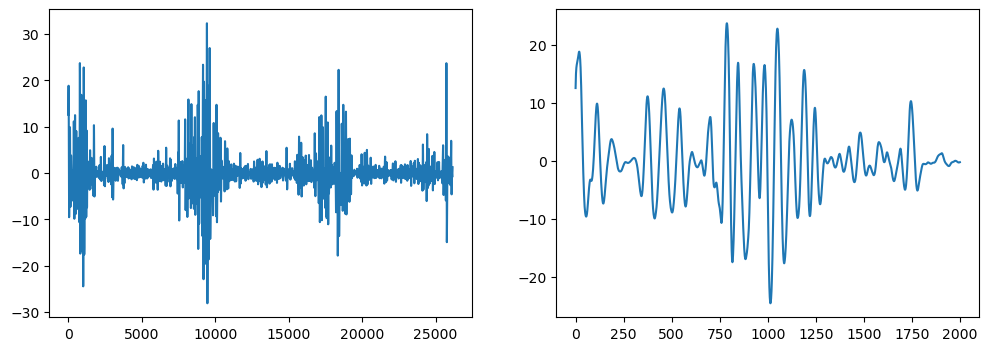

In [208]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(s['1_3_harm'].values)

plt.subplot(1,2,2)
plt.plot(s['1_3_harm'].values[:2000])

plt.show()

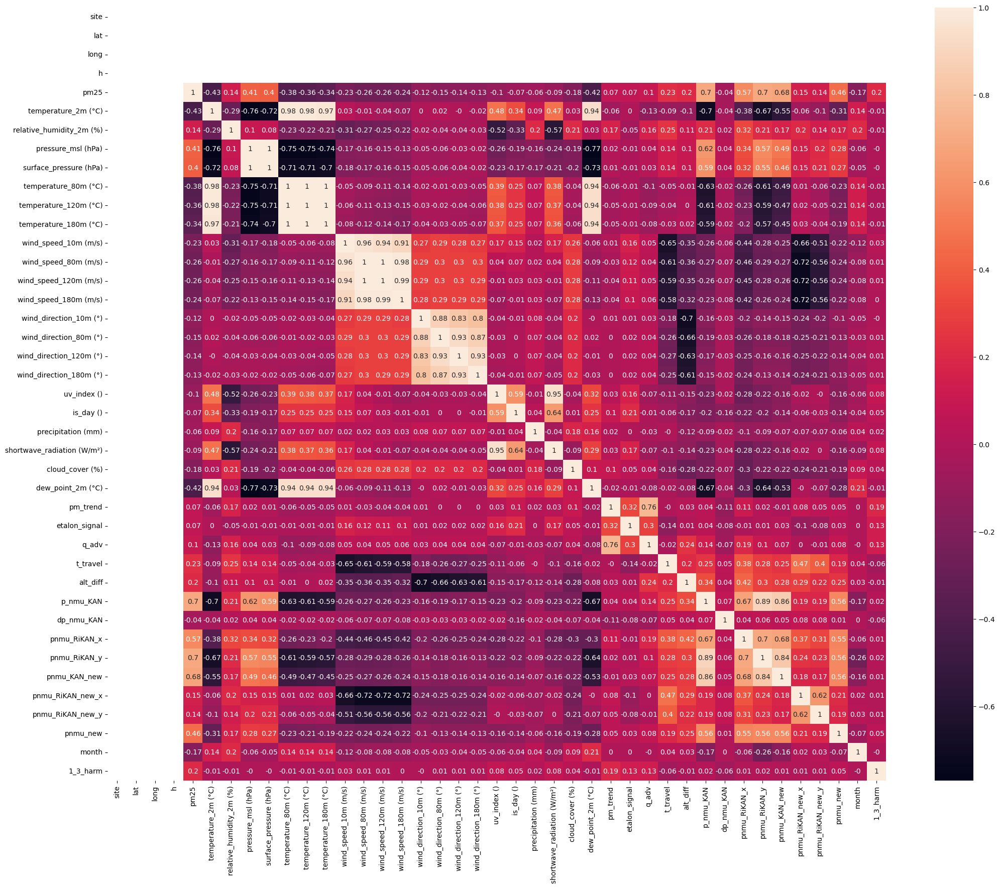

In [191]:
plt.figure(figsize=(25,20))
sns.heatmap(s.corr().round(2),annot=True)
plt.show()

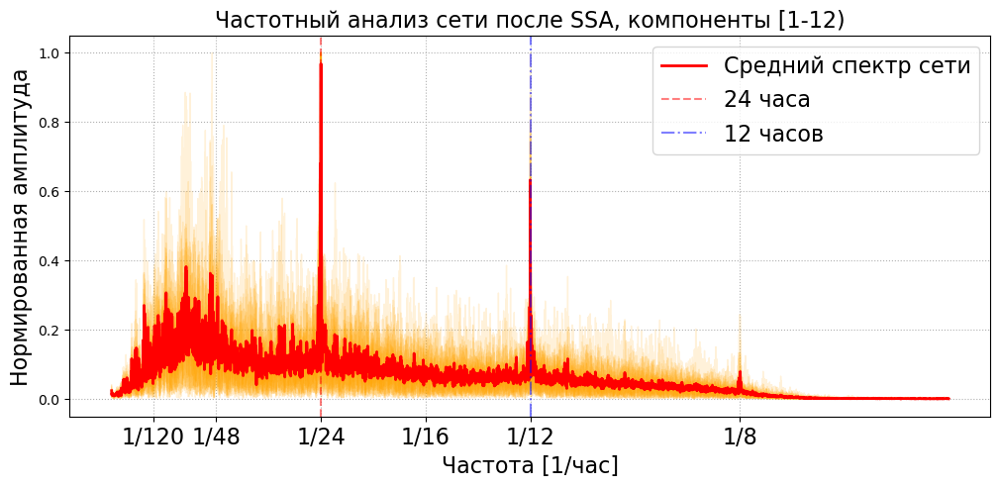

In [77]:
plot_ensemble_analysis(df,48,(1,12))

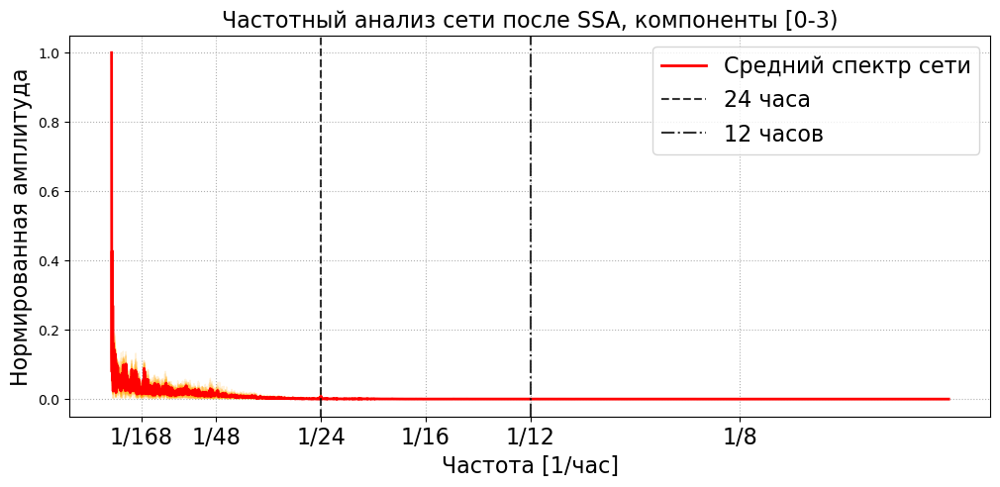

In [245]:
recovered = plot_ensemble_analysis(df,48,(0,3))

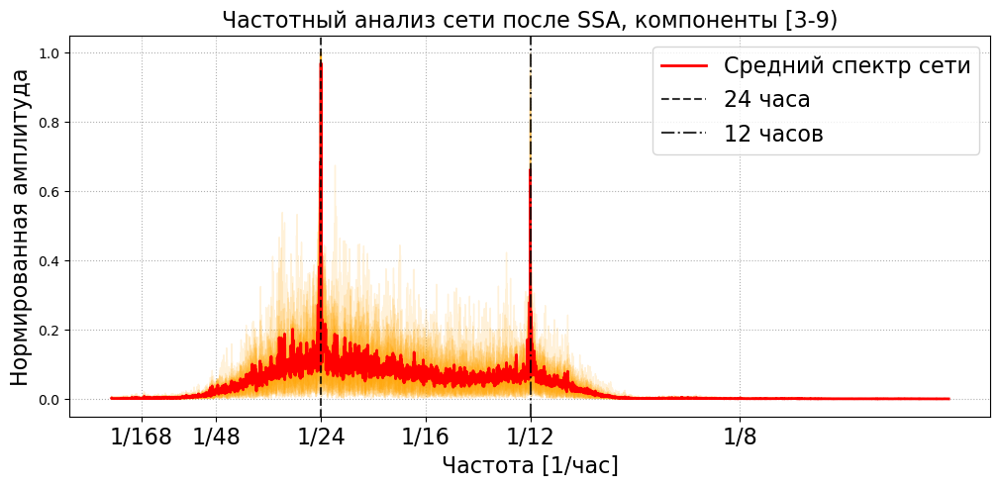

In [246]:
recovered = plot_ensemble_analysis(df,48,(3,9))

# Связь с целевой переменной

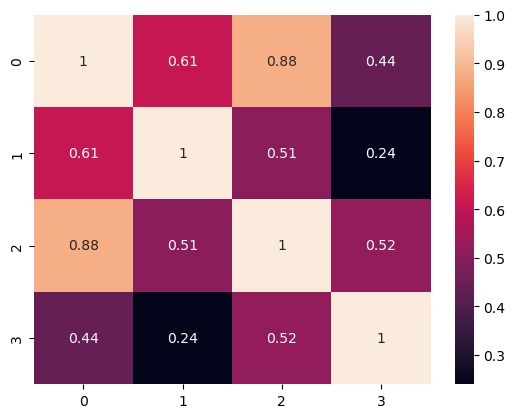

In [448]:
sns.heatmap(np.corrcoef([seasonal1,seasonal2,seasonal3,site1['pm25'].values]).round(2),annot=True)
plt.show()

In [1252]:
site2 = df[df['site']==3854][:edge]

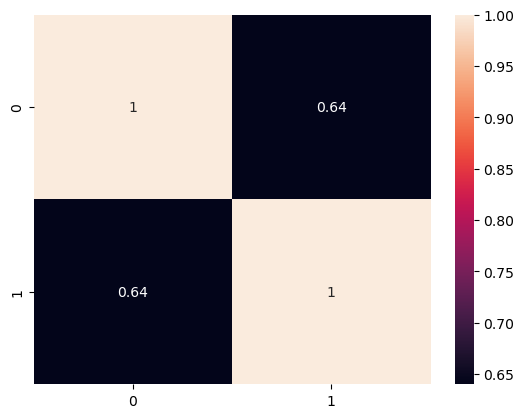

In [1254]:
sns.heatmap(np.corrcoef([site1['pm25'].values,site2['pm25'].values]).round(2),annot=True)
plt.show()

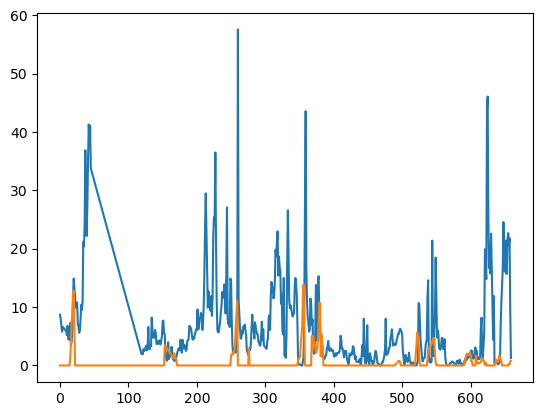

In [1307]:
k = 18
plt.plot(site1['pm25'].values[(k-1)*120:k*150])
plt.plot(1000000*site1['inflow'].values[(k-1)*120:k*150])
plt.show()

# Автоматизация обработки данных для всех датчиков и их признаков

----3837----


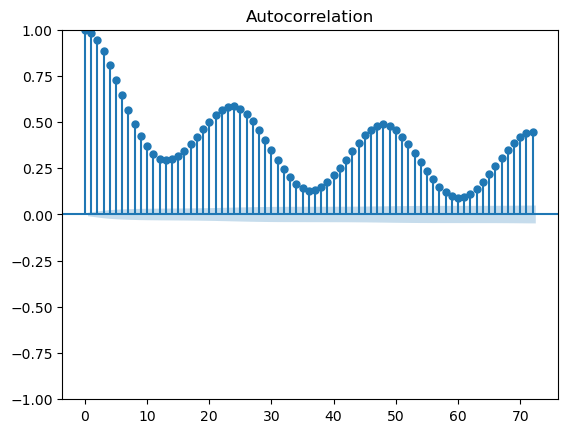

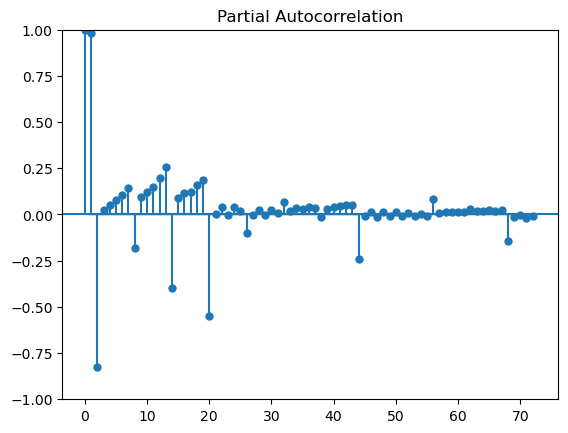

Размер окна:  24


Тренд


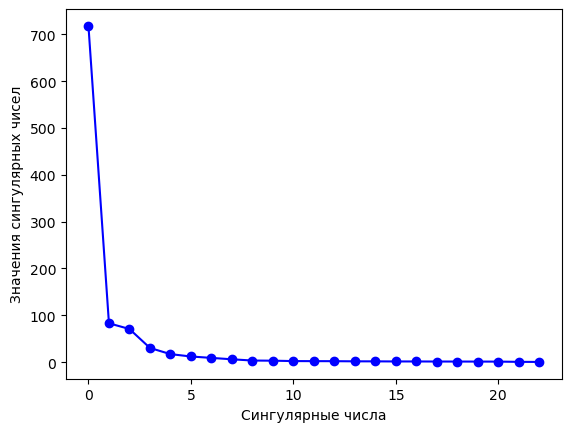

Сезонная компонента


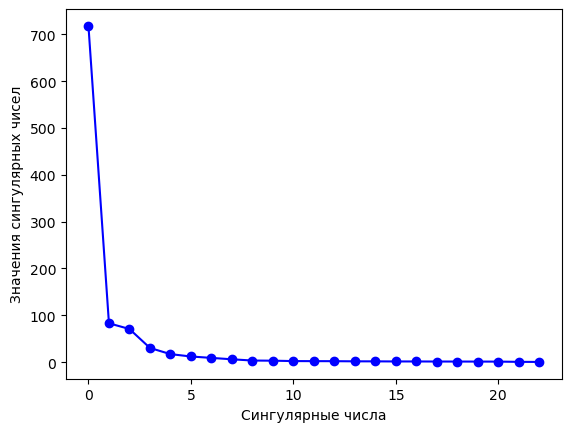

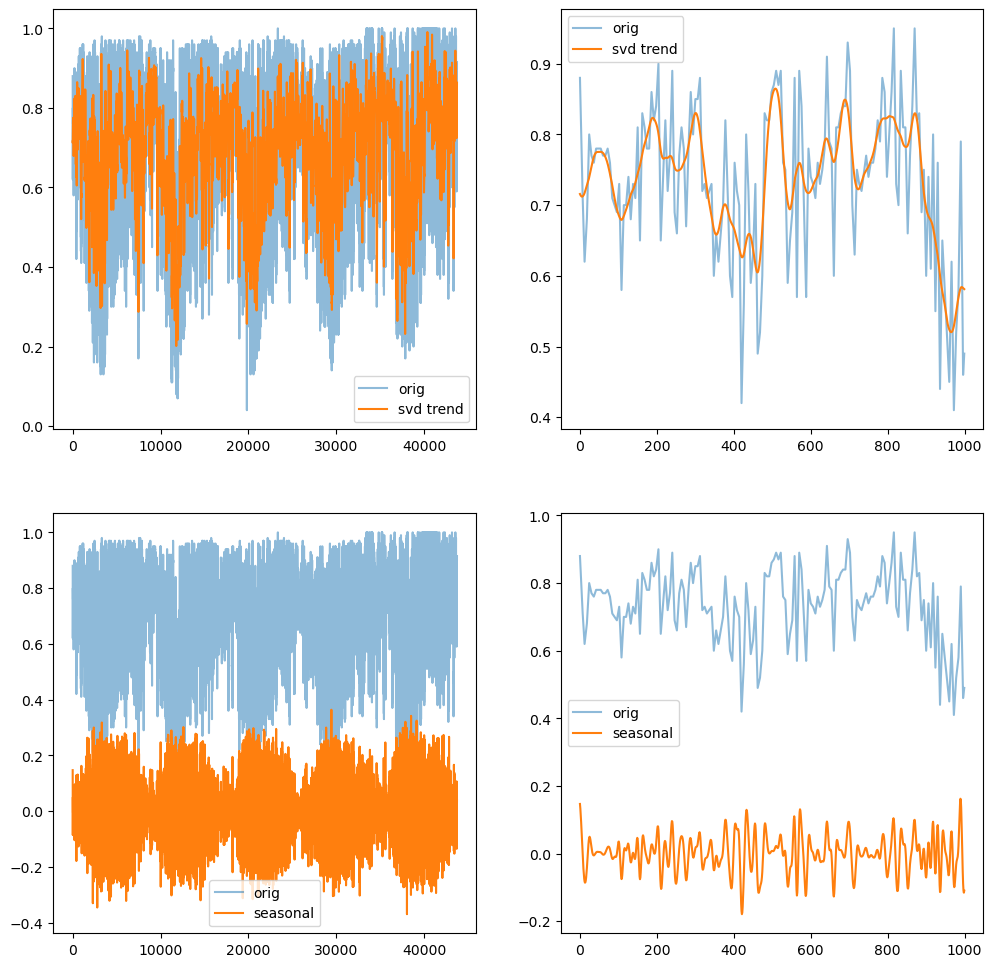

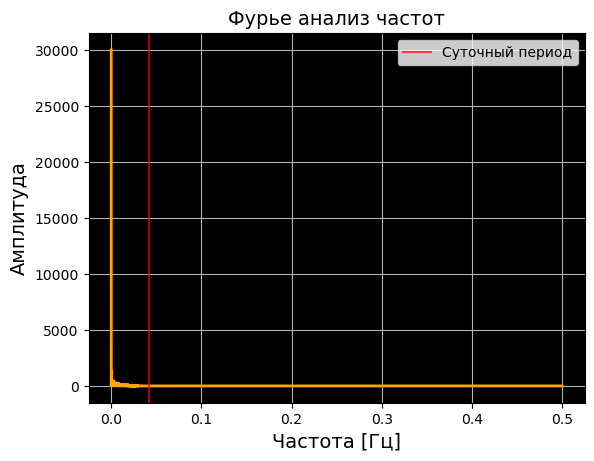

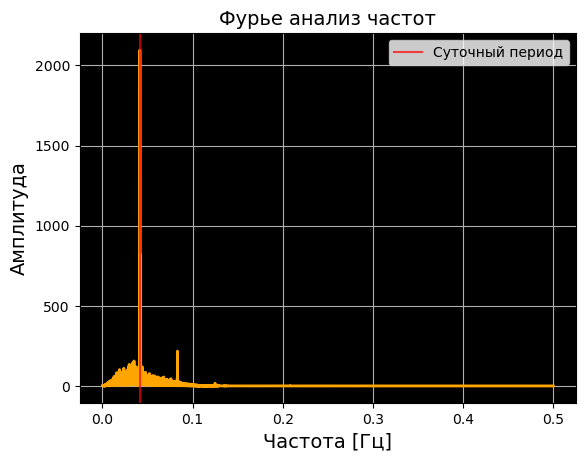

In [552]:
cycle_features = ['pm25','T','Po','U']

site_trends = []
site_seasonals = []

trends = []
seasonals = []

sites_group = df.groupby('site')
for f in cycle_features:
    clear_output(wait=True)
    print('Признак', f)
    # Анализ автокорреляции
    for site, group in sites_group:
        clear_output(wait=True)
        print(f'----{site}----')
        f_data = group[f]
        plot_acf(f_data, alpha=0.05, lags=24*3)
        plot_pacf(f_data, alpha=0.05, lags=24*3)
        plt.show()

        if f == 'pm25':
            window = 24
        else:
            window = int(input('Размер окна: '))
        # Разделение на тренд и сезонность
        print('Тренд')
        trend = get_ssa_components(f_data.values, window=window, components_range=(0, 1))
        print('Сезонная компонента')
        seasonal = get_ssa_components(f_data.values, window=window, components_range=(1, 5))
        plt.figure(figsize=(12,12))
        plt.subplot(2,2,1)
        plt.plot(f_data.values,alpha=0.5,label='orig')
        plt.plot(trend,label='svd trend')
        plt.legend()
        plt.subplot(2,2,2)
        plt.plot(f_data.values[:1000],alpha=0.5,label='orig')
        plt.plot(trend[:1000],label='svd trend')
        plt.legend()
        plt.subplot(2,2,3)
        plt.plot(f_data.values,alpha=0.5,label='orig')
        plt.plot(seasonal,label='seasonal')
        plt.legend()
        plt.subplot(2,2,4)
        plt.plot(f_data.values[:1000],alpha=0.5,label='orig')
        plt.plot(seasonal[:1000],label='seasonal')
        plt.legend()
        plt.show()
    
        fourierplot(f_data.index, trend)
        plt.show()
        fourierplot(f_data.index, seasonal)
        plt.show()

        if f == 'pm25':
            wait = input('Перейти к слудующему датчику?')
            site_trends.append(trend)
            site_seasonals.append(seasonal)
        else:
            wait=input()
            trends.append(trend)
            seasonals.append(seasonal)
            break
    
        

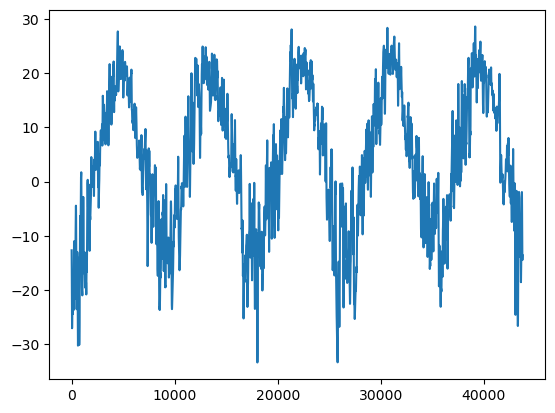

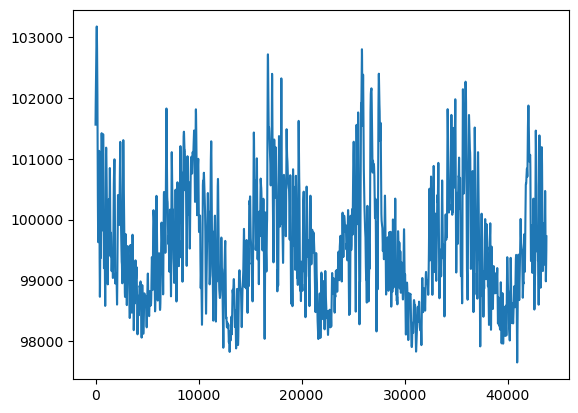

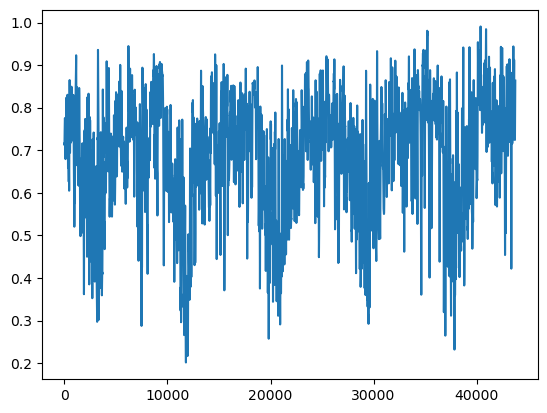

In [577]:
plt.plot(trends[0])
plt.show()
plt.plot(trends[1])
plt.show()
plt.plot(trends[2])
plt.show()

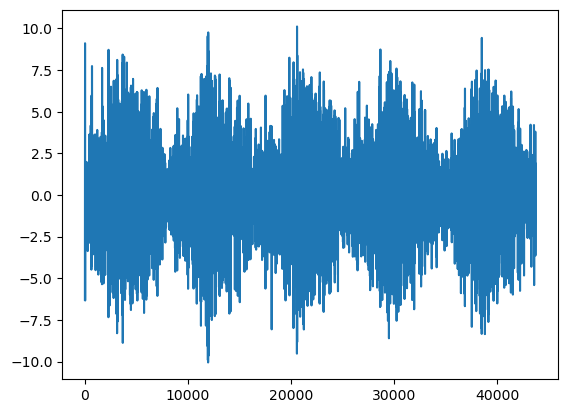

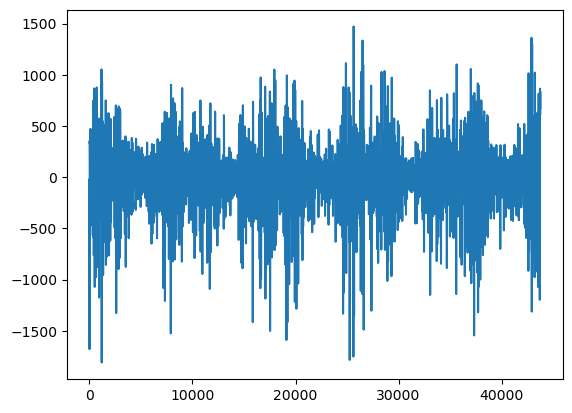

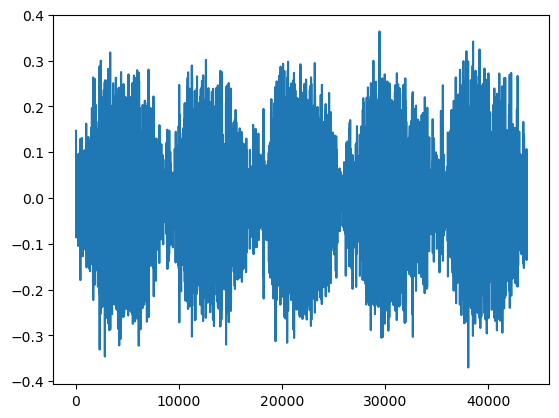

In [579]:
plt.plot(seasonals[0])
plt.show()
plt.plot(seasonals[1])
plt.show()
plt.plot(seasonals[2])
plt.show()

# Проверка модуля

In [181]:
class SSAPreprocessor:
    def __init__(self):
        self.window = None
        self.mean = None
        self.std = None
        
        self.U = None
        self.S = None
        self.Vt = None
        
        self.N = None
        self.L = None
        self.K = None
        
    def fit(self, series, window):
        self.window = window
        self.N = len(series)
        self.L = self.window
        self.K = self.N - self.L + 1
        
        self.mean = np.mean(series)
        self.std = np.std(series)
        data_std = ((series - self.mean) / self.std).values
        
        X = as_strided(data_std, shape=(self.K, self.L),
                       strides=(data_std.strides[0],
                                data_std.strides[0]))
        U, S, VT = svds(X, k=self.window-1)
        self.S = S[::-1]
        self.U = U[:, ::-1]
        self.VT = VT[::-1, :]

    def decompose(self, components_range=(0,5)):
        a, b = components_range
        X_hat = (self.U[:, a:b] * self.S[a:b]) @ self.VT[a:b, :]
        recovered_series = np.zeros(self.N)
        counts = np.zeros(self.N)
        for i in range(self.K):
            for j in range(self.L):
                recovered_series[i + j] += X_hat[i, j]
                counts[i + j] += 1
        return recovered_series / counts
        
    def transform(self, series):
        data_std = (series - self.mean) / self.std
        return data_std

    def inverse_transform(self, series):
        data = (series * self.std) + self.mean
        return data

In [318]:
pm_prep = SSAPreprocessor()
T_prep = SSAPreprocessor()
U_prep = SSAPreprocessor()
P_prep = SSAPreprocessor()

In [599]:
site1 = df[df['site'] == 4227].reset_index(drop=True).iloc[:edge]
site1['time'] = pd.to_datetime(site1['time'])
site1 = site1.set_index('time')

In [601]:
pm_prep.fit(site1['pm25'], 24)
T_prep.fit(site1['T'], 24)
U_prep.fit(site1['U'], 24)
P_prep.fit(site1['Po'], 48)

In [602]:
pm_trend = pm_prep.decompose(components_range=(0,1))
pm_seas = pm_prep.decompose(components_range=(1,5))

T_trend = T_prep.decompose(components_range=(0,1))
T_seas = T_prep.decompose(components_range=(1,5))
U_trend = U_prep.decompose(components_range=(0,1))
U_seas = U_prep.decompose(components_range=(1,5))
P_trend = P_prep.decompose(components_range=(0,1))
P_seas = P_prep.decompose(components_range=(1,5))

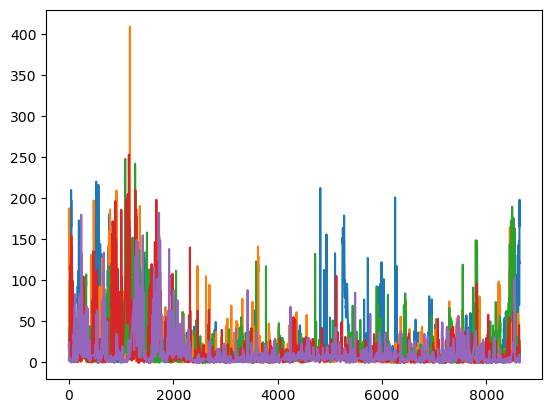

In [604]:
plt.plot(site1['pm25'].values[0 *24*30*12 : 1 *24*30*12])
plt.plot(site1['pm25'].values[1 *24*30*12 : 2 *24*30*12])
plt.plot(site1['pm25'].values[2 *24*30*12 : 3 *24*30*12])
plt.plot(site1['pm25'].values[3 *24*30*12 : 4 *24*30*12])
plt.plot(site1['pm25'].values[4 *24*30*12 : 5 *24*30*12])
plt.show()

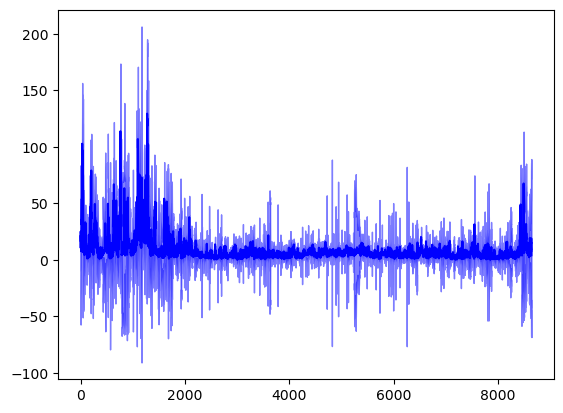

In [659]:
f = 'pm25'
five_years = np.array([site1[f].values[0 *24*30*12 : 1 *24*30*12],
                       site1[f].values[1 *24*30*12 : 2 *24*30*12],
                       site1[f].values[2 *24*30*12 : 3 *24*30*12],
                       site1[f].values[3 *24*30*12 : 4 *24*30*12],
                       site1[f].values[4 *24*30*12 : 5 *24*30*12]])

mean_f = np.median(five_years,axis=0)
std_f = np.std(five_years,axis=0)
plt.plot(mean_f,color='blue')
plt.fill_between([*range(mean_f.shape[0])],
                 mean_f-std_f,
                 mean_f+std_f,
                 alpha=0.5,
                 color='blue')
plt.show()

In [807]:
[site1.index[:mean_f.shape[0]]]

[DatetimeIndex(['2021-01-01 01:00:00', '2021-01-01 02:00:00',
                '2021-01-01 03:00:00', '2021-01-01 04:00:00',
                '2021-01-01 05:00:00', '2021-01-01 06:00:00',
                '2021-01-01 07:00:00', '2021-01-01 08:00:00',
                '2021-01-01 09:00:00', '2021-01-01 10:00:00',
                ...
                '2021-12-26 15:00:00', '2021-12-26 16:00:00',
                '2021-12-26 17:00:00', '2021-12-26 18:00:00',
                '2021-12-26 19:00:00', '2021-12-26 20:00:00',
                '2021-12-26 21:00:00', '2021-12-26 22:00:00',
                '2021-12-26 23:00:00', '2021-12-27 00:00:00'],
               dtype='datetime64[ns]', name='time', length=8640, freq=None)]

In [813]:
mean_f = pd.DataFrame(zip(site1.index[:mean_f.shape[0]],mean_f), columns=['time','pm25'])
mean_f['time'] = pd.to_datetime(mean_f['time'])
mean_f = mean_f.set_index('time',drop=True)

In [915]:
WINDOW = 23*30
f_trend = mean_f['pm25'].rolling(window=WINDOW, center=True).mean().values.flatten()
f_trend[:WINDOW//2] = f_trend[WINDOW//2]
f_trend[f_trend.shape[0]-WINDOW//2:] = f_trend[f_trend.shape[0]-WINDOW//2]

In [1047]:
trend_nonpreg = core_regression([[x] for x in range(mean_f.shape[0])], mean_f['pm25'].values, 500, 'EP')

100.0%


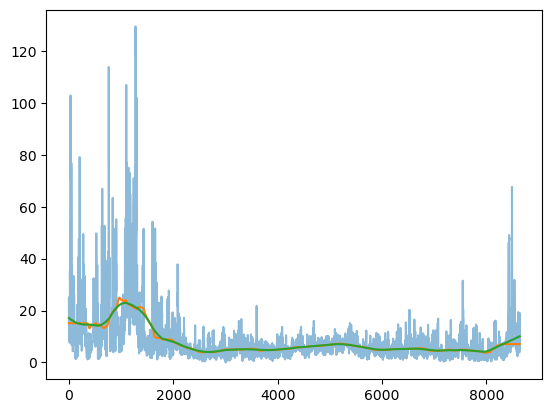

In [1079]:
plt.plot(mean_f.values,alpha=0.5)
plt.plot(f_trend)
plt.plot(trend_nonpreg)

In [1051]:
non_trend = mean_f['pm25'] / trend_nonpreg

In [1061]:
pm_prep = SSAPreprocessor()
pm_prep.fit(non_trend, 24)

sub_trend = pm_prep.decompose((0,1))
sub_seas = pm_prep.decompose((1,5))

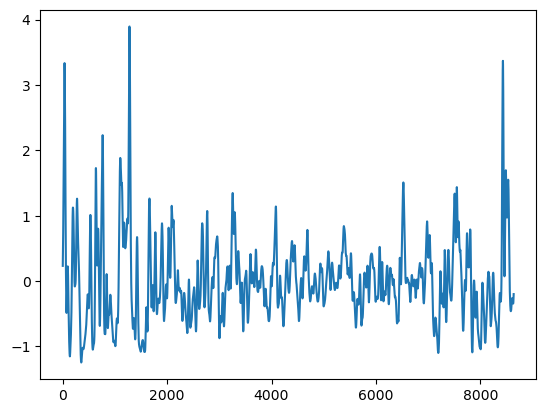

In [1062]:
plt.plot(sub_trend)
plt.show()

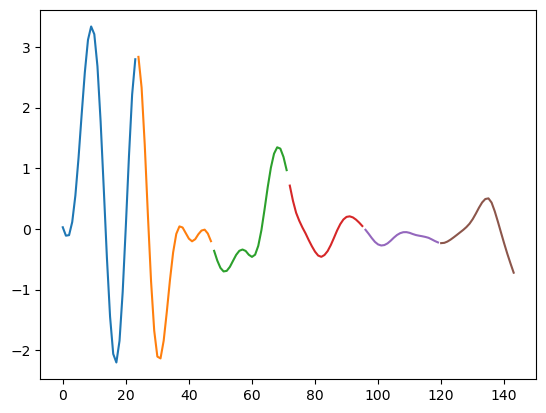

In [1077]:
plt.plot([*range(0,1*24)],sub_seas[1*24:24*2])
plt.plot([*range(1*24,2*24)],sub_seas[2*24:24*3])
plt.plot([*range(2*24,3*24)],sub_seas[3*24:24*4])
plt.plot([*range(3*24,4*24)],sub_seas[4*24:24*5])
plt.plot([*range(4*24,5*24)],sub_seas[5*24:24*6])
plt.plot([*range(5*24,6*24)],sub_seas[6*24:24*7])
plt.show()

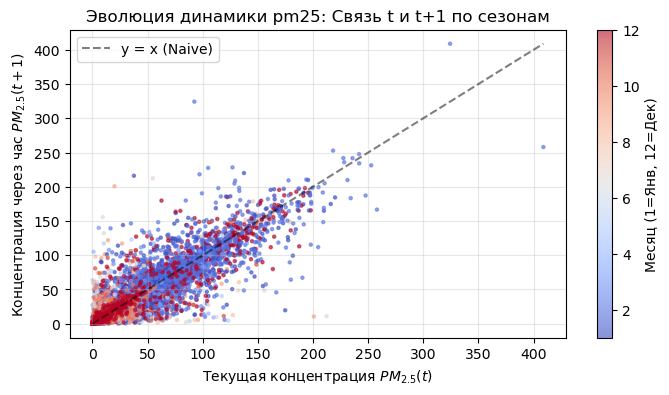

In [1117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_phase_evolution(df, column='pm25'):
    plt.figure(figsize=(8, 4))
    
    # Создаем лаг t+1
    df_plot = df.copy()
    df_plot['next_val'] = df_plot[column].shift(-1)
    df_plot['month'] = df_plot.index.month
    
    # Убираем NaN после shift
    df_plot = df_plot.dropna()
    
    # Строим фазовый портрет с цветовой кодировкой по месяцам
    scatter = plt.scatter(df_plot[column], df_plot['next_val'], 
                         c=df_plot['month'], cmap='coolwarm', 
                         alpha=0.6, s=5)
    
    # Линия идеального совпадения (наивный прогноз)
    max_val = df_plot[column].max()
    plt.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='y = x (Naive)')
    
    plt.colorbar(scatter, label='Месяц (1=Янв, 12=Дек)')
    plt.title(f'Эволюция динамики {column}: Связь t и t+1 по сезонам')
    plt.xlabel('Текущая концентрация $PM_{2.5} (t)$')
    plt.ylabel('Концентрация через час $PM_{2.5} (t+1)$')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

plot_phase_evolution(site1)

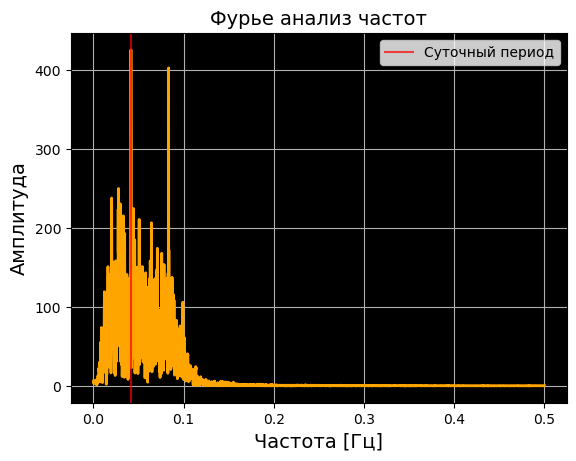

In [1035]:
fourierplot(np.arange(sub_trend.shape[0]), sub_seas)

In [845]:
diff = pd.DataFrame(a,columns=['diff'])
diff['time'] = pd.to_datetime(site1.index[:len(a)])
diff = diff.set_index('time', drop=True)

In [849]:
dec = seasonal_decompose(diff)

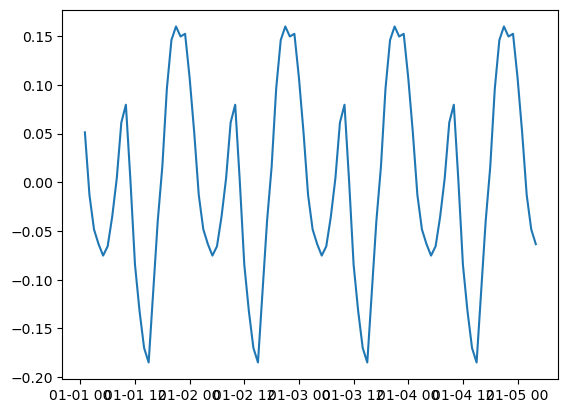

In [855]:
plt.plot(dec.seasonal[:100])

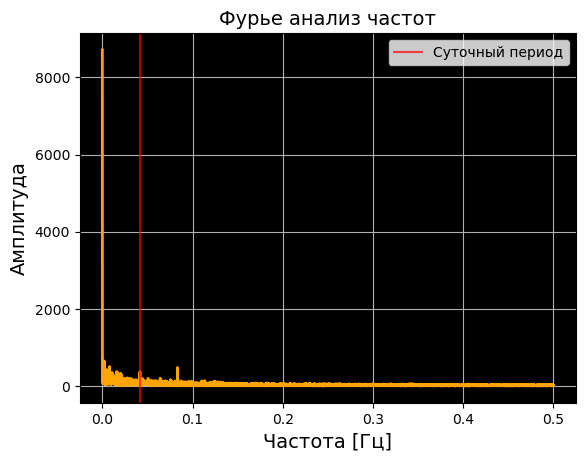

In [877]:
fourierplot(diff.index, diff['diff'])

In [759]:
shift1 = np.array([0,*five_years[1][:-1]])
diff1 = (five_years[1] - shift1)[1:]
shift2 = np.array([0,*mean_f[:-1]])
diff2 = (mean_f - shift2)[1:]

In [761]:
np.corrcoef([diff1,diff2])

array([[1.        , 0.18014266],
       [0.18014266, 1.        ]])

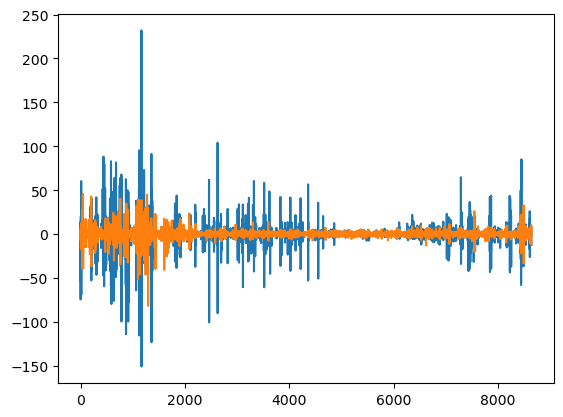

In [763]:
plt.plot(diff1)
plt.plot(diff2)
plt.show()

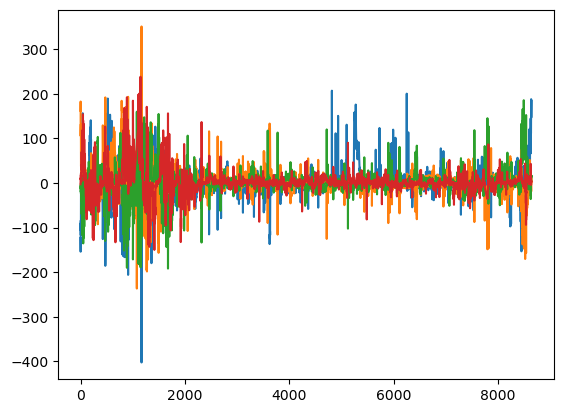

In [621]:
plt.plot(five_years[0]-five_years[1])
plt.plot(five_years[1]-five_years[2])
plt.plot(five_years[2]-five_years[3])
plt.plot(five_years[3]-five_years[4])
plt.show()

In [797]:
diff = pd.DataFrame(np.clip(pm_trend_prep.transform(site1['pm25']).values[:]/pm_trend[:],-4,4),columns=['diff'])
diff['time'] = pd.to_datetime(site1.index[:site1.shape[0]])
diff = diff.set_index('time', drop=True)

In [799]:
dec = seasonal_decompose(diff)

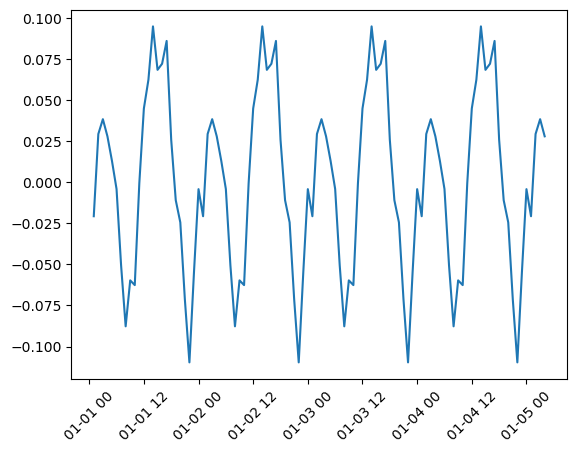

In [801]:
plt.plot(dec.seasonal[:100])
plt.xticks(rotation=45)
plt.show()

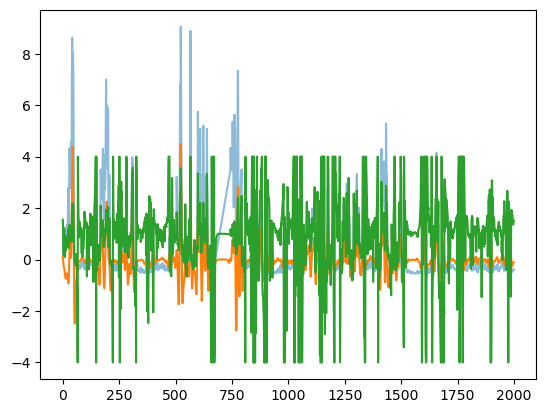

In [791]:
plt.plot(pm_trend_prep.transform(site1['pm25']).values[:2000],alpha=0.5)
plt.plot(pm_seas[:2000])
plt.plot(np.clip(pm_trend_prep.transform(site1['pm25']).values[:2000]/pm_trend[:2000],-4,4))

In [289]:
t = pd.DataFrame([*zip(site1.index,
                       pm_trend,
                       pm_seas,
                       T_trend,
                       U_trend,
                       P_trend,
                       T_seas,
                       U_seas,
                       P_seas)],
                 columns=['time','pm25t','pm25s','Tt','Ut','Pt','Ts','Us','Ps'])

In [290]:
diff = (t['pm25t'] - t['pm25t'].shift(1)).iloc[1:]
t = t.drop(index=0)
t['diff'] = diff

In [291]:
t

,time,pm25t,pm25s,Tt,Ut,Pt,Ts,Us,Ps,diff
1,2021-01-01 02:00:00,1.447993,0.131141,-1.312580,0.142118,1.734749,-0.385914,0.756710,-0.073679,0.063786
2,2021-01-01 03:00:00,1.485807,-0.051599,-1.327849,0.138120,1.756529,-0.267102,0.659683,-0.239744,0.037814
3,2021-01-01 04:00:00,1.519112,-0.232104,-1.344988,0.135601,1.778846,-0.140650,0.543284,-0.409206,0.033304
4,2021-01-01 05:00:00,1.557024,-0.361843,-1.363984,0.134531,1.801666,-0.016780,0.413114,-0.578570,0.037913
5,2021-01-01 06:00:00,1.608295,-0.427484,-1.384831,0.134879,1.824959,0.095581,0.275606,-0.743869,0.051271
...,...,...,...,...,...,...,...,...,...,...
42911,2025-11-24 00:00:00,-0.540489,0.105067,-1.194775,0.145395,-0.599885,-0.266790,0.472454,0.971156,0.005782
42912,2025-11-24 01:00:00,-0.534938,0.098105,-1.215095,0.143511,-0.589596,-0.253193,0.554790,0.920310,0.005552
42913,2025-11-24 02:00:00,-0.528826,0.087754,-1.235225,0.141528,-0.578912,-0.242248,0.620777,0.865980,0.006112
42914,2025-11-24 03:00:00,-0.519126,0.083048,-1.255171,0.139523,-0.567848,-0.234145,0.666654,0.811389,0.009700


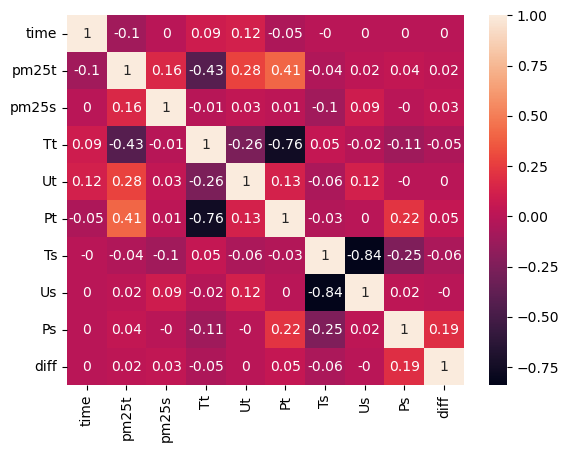

In [297]:
sns.heatmap(t.corr().round(2),annot=True)
plt.show()

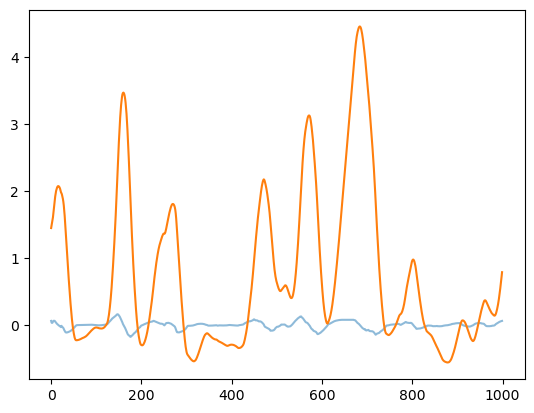

In [308]:
plt.plot(t['diff'].values[:1000],alpha=0.5)
plt.plot(t['pm25t'].values[:1000])
plt.show()

# Вейвлет-разложение

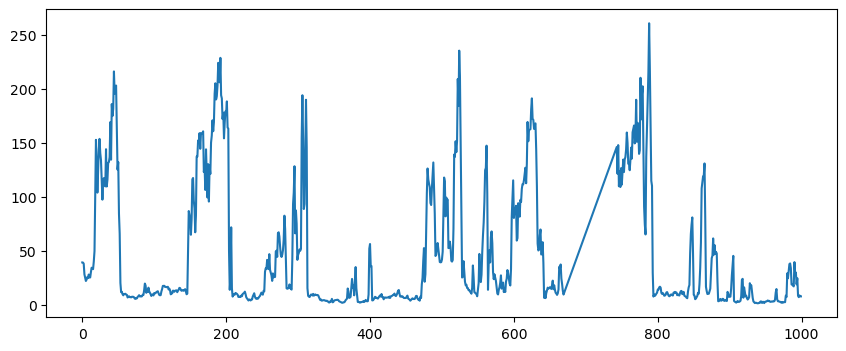

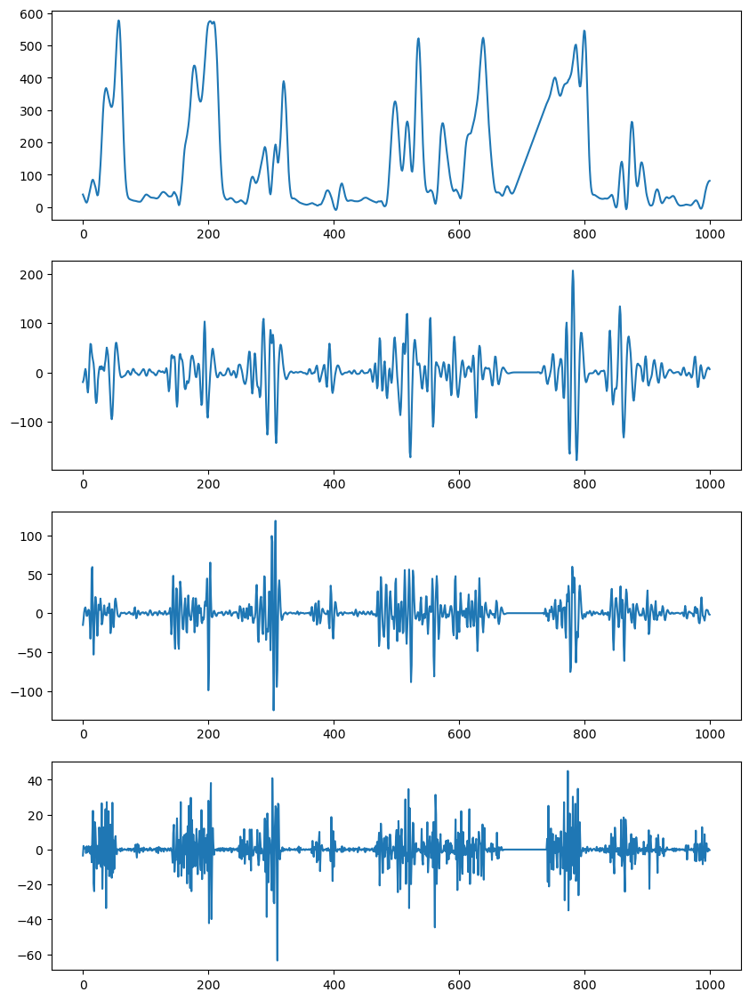

In [18]:
import pywt
s = df[df['site']==3857]
n = (s.shape[0] // (2**3)) * (2**3)

coeffs = pywt.swt(s['pm25'].values[:n], 'db4', level=3,trim_approx=True)
titles = ['A3 (Trend)', 'D3 (Daily)', 'D2 (Meso)', 'D1 (Fast)']

plt.figure(figsize=(10.2,4))
plt.plot(s['pm25'].values[:1000])
plt.show()
plt.figure(figsize=(10,14))
for i, c in enumerate(coeffs):
    plt.subplot(4, 1, i+1)
    plt.plot(c[:1000])
    # plt.title(titles[i])
plt.show()

In [14]:
from sklearn.metrics import r2_score

In [28]:
r2_score(s['pm25'].values[:n], coeffs[0])

-4.567959793681958

In [995]:
dec = seasonal_decompose(pd.DataFrame(zip(coeffs[3],s['time'].values[:n]),columns=['pm25','time']).set_index('time') )

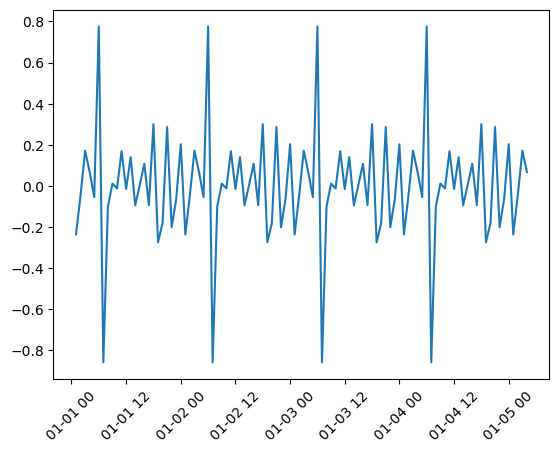

In [997]:
plt.plot(dec.seasonal[:100])
plt.xticks(rotation=45)
plt.show()

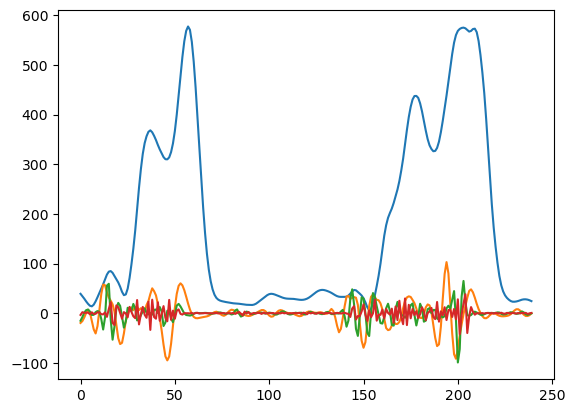

In [988]:
plt.plot(coeffs[0][:240])
plt.plot(coeffs[1][:240])
plt.plot(coeffs[2][:240])
plt.plot(coeffs[3][:240])
plt.show()

# Датасет от Kaggle

In [828]:
kdf = pd.read_csv('data/GlobalWeatherRepository.csv')

In [830]:
kdf

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.5200,69.1800,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.40,26.60,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.3300,19.8200,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.10,2.00,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.7600,3.0500,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.40,18.40,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.5000,1.5200,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.70,0.90,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.8400,13.2300,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.40,262.30,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133313,Venezuela,Caracas,10.5000,-66.9167,America/Caracas,1775197800,2026-04-03 02:30,17.5,63.6,Mist,...,5.15,6.85,1,1,06:23 AM,06:38 PM,08:01 PM,07:12 AM,Waning Gibbous,99
133314,Vietnam,Hanoi,21.0333,105.8500,Asia/Bangkok,1775197800,2026-04-03 13:30,30.0,86.0,Overcast,...,57.65,60.15,3,7,05:49 AM,06:12 PM,07:20 PM,06:12 AM,Waning Gibbous,100
133315,Yemen,Sanaa,15.3547,44.2067,Asia/Aden,1775197800,2026-04-03 09:30,18.0,64.5,Sunny,...,17.55,58.25,2,2,05:57 AM,06:16 PM,07:28 PM,06:30 AM,Waning Gibbous,99
133316,Zambia,Lusaka,-15.4167,28.2833,Africa/Lusaka,1775197800,2026-04-03 08:30,17.8,64.0,Patchy rain nearby,...,3.05,3.45,1,1,06:12 AM,06:07 PM,06:56 PM,07:08 AM,Waning Gibbous,99


In [832]:
kdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133318 entries, 0 to 133317
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       133318 non-null  object 
 1   location_name                 133318 non-null  object 
 2   latitude                      133318 non-null  float64
 3   longitude                     133318 non-null  float64
 4   timezone                      133318 non-null  object 
 5   last_updated_epoch            133318 non-null  int64  
 6   last_updated                  133318 non-null  object 
 7   temperature_celsius           133318 non-null  float64
 8   temperature_fahrenheit        133318 non-null  float64
 9   condition_text                133318 non-null  object 
 10  wind_mph                      133318 non-null  float64
 11  wind_kph                      133318 non-null  float64
 12  wind_degree                   133318 non-nul

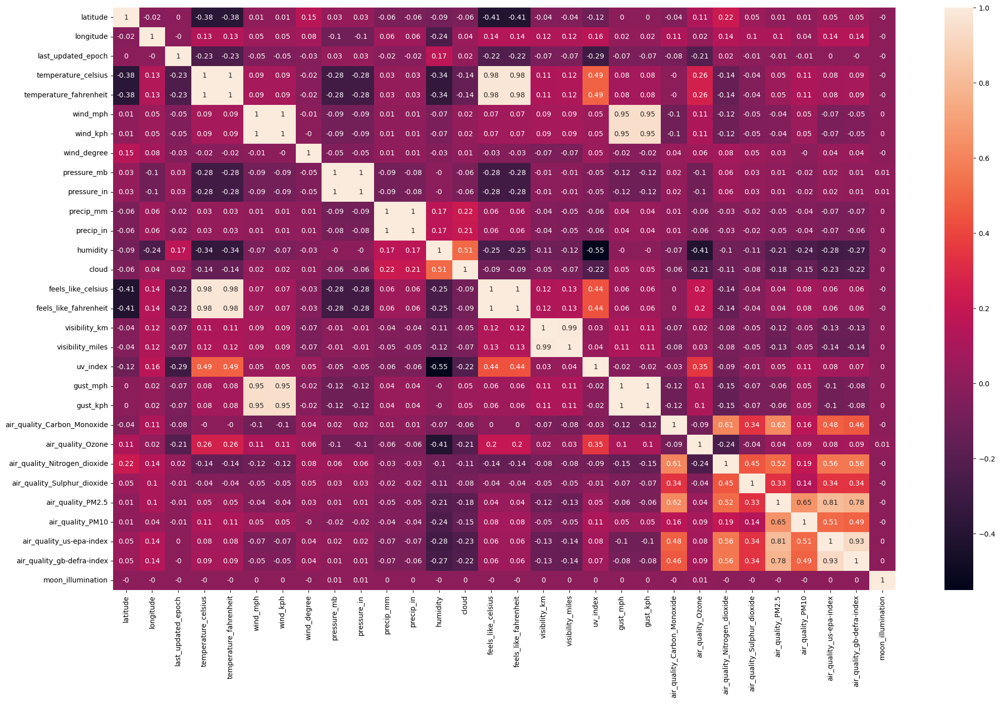

In [852]:
plt.figure(figsize=(25,15))
sns.heatmap(kdf.select_dtypes(include=['number']).corr().round(2),annot=True)
plt.show()

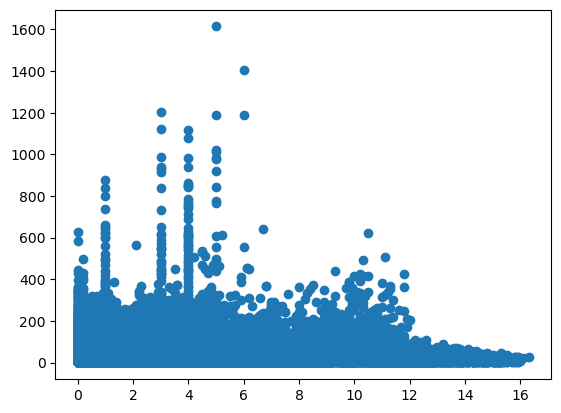

In [856]:
plt.scatter(kdf['uv_index'], kdf['air_quality_PM2.5'])
plt.show()

# Кросс-корреялционный анализ

In [260]:
sensors = pd.read_csv('data/min_sensors_project_9.csv')
sensors

,id,name,lat,long,h
0,3837,Академгородок,55.986571,92.762222,255
1,3853,Ветлужанка,56.029300,92.765370,204
2,3844,Дрокино,56.098700,92.742700,182
3,4363,Караульная,55.973219,92.674777,135
4,4325,"Качинская, 56А",56.018823,92.871068,137
5,3859,Кировский,55.994686,92.958275,144
6,3849,КрАЗ,56.087800,93.014800,177
7,3857,"Ленина, 41",56.013546,92.877796,153
8,3847,Минино,56.077430,92.704560,226
9,3842,Николаевка,56.007720,92.821260,177


In [313]:
season.values

array(['2021-11-01T00:00:00.000000000', '2021-11-01T01:00:00.000000000',
       '2021-11-01T02:00:00.000000000', ...,
       '2022-02-28T22:00:00.000000000', '2022-02-28T23:00:00.000000000',
       '2022-03-01T00:00:00.000000000'], dtype='datetime64[ns]')

In [29]:
df = df.set_index('time')
df['time'] = df.index

In [33]:
# season = pd.date_range(
#     "11.01.2021",
#     "03.01.2022",
#     freq='1h'
# )
# season = pd.date_range(
#     "06.01.2021",
#     "10.01.2022",
#     freq='1h'
# )

# Добавление лагов

# df = df.sort_values(['site', 'time'])

df['pm25_lag1'] = df.groupby('site')['pm25'].shift(1)

df = df.dropna(subset=['pm25_lag1'])

df['diff'] = df['pm25'] - df['pm25_lag1']


In [35]:
df.columns

Index(['T', 'Po', 'U', 'DD', 'Ff', 'site', 'iaqi', 'pm25', 'pm10', 'lat',
       'long', 'h', 'time', 'pm25_lag1', 'diff'],
      dtype='object')

In [37]:
pm25_wide = df.pivot(index='time', columns='site', values='diff')

In [642]:
corr_tensor = []
sites = [sensors[sensors['id']==int(site)]['name'].values[0] for site in pm25_wide.columns]
for t in range(0,25):
    corr_matrix = []
    for site in pm25_wide.columns:
        site_col = pm25_wide[int(site)]
        shift_df = pm25_wide.shift(t)
        shift_df = shift_df.dropna()
        shift_df[int(site)] = site_col.values[t:]
        corr_matrix.append(shift_df.corr().loc[int(site)].values)
        
    corr_tensor.append(corr_matrix)


In [470]:
corr_df = pd.DataFrame(corr_tensor[24],columns=sites,index=sites)

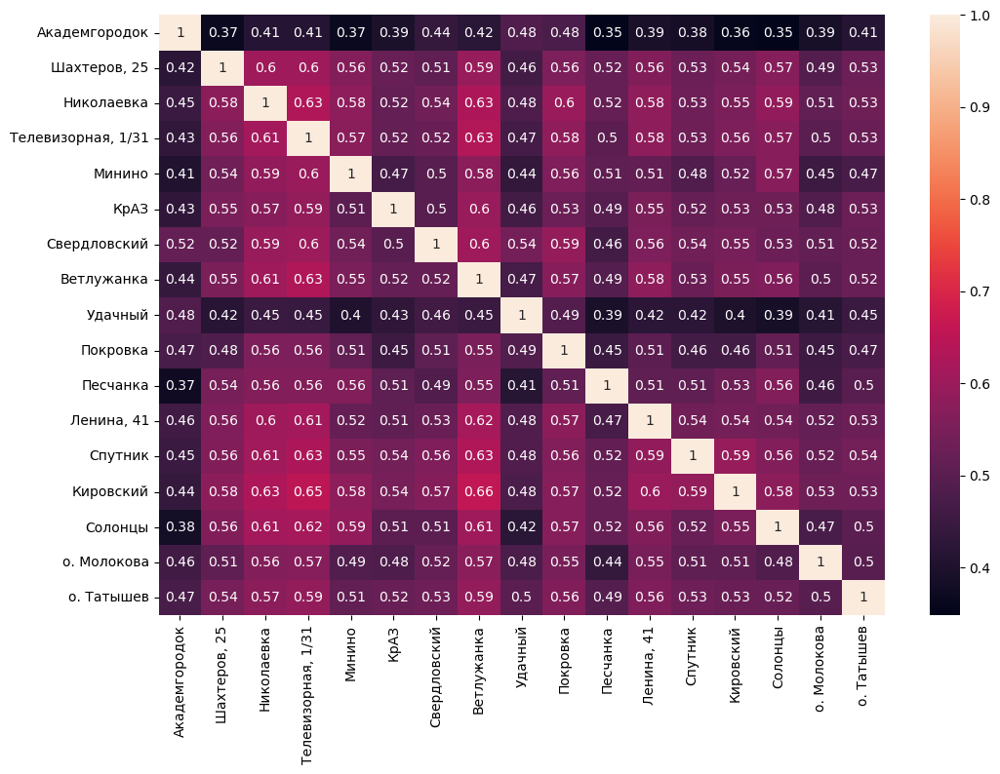

In [472]:
plt.figure(figsize=(12,8))
sns.heatmap(corr_df, annot=True)
plt.show()

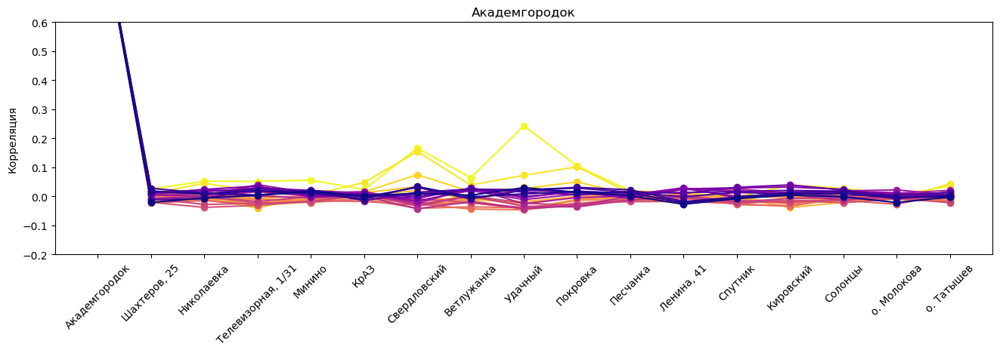

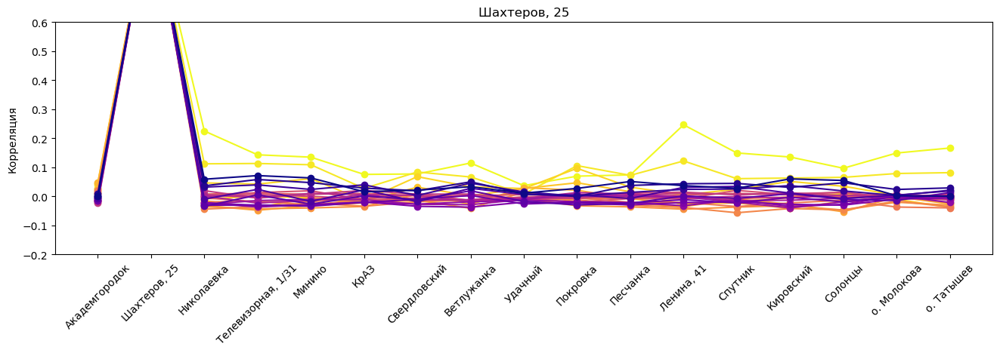

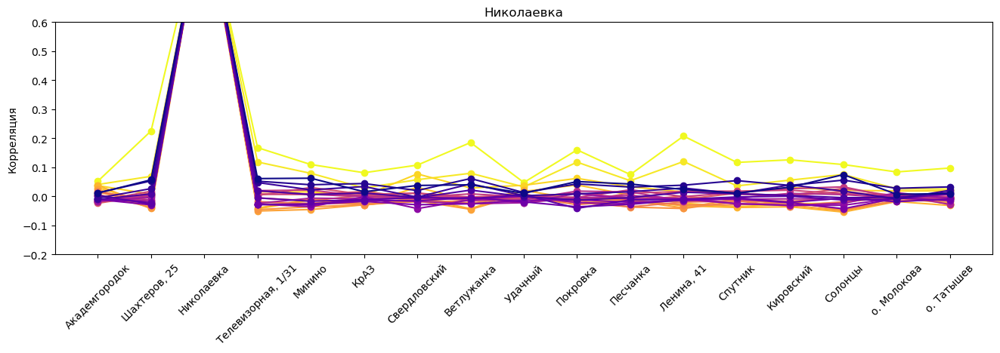

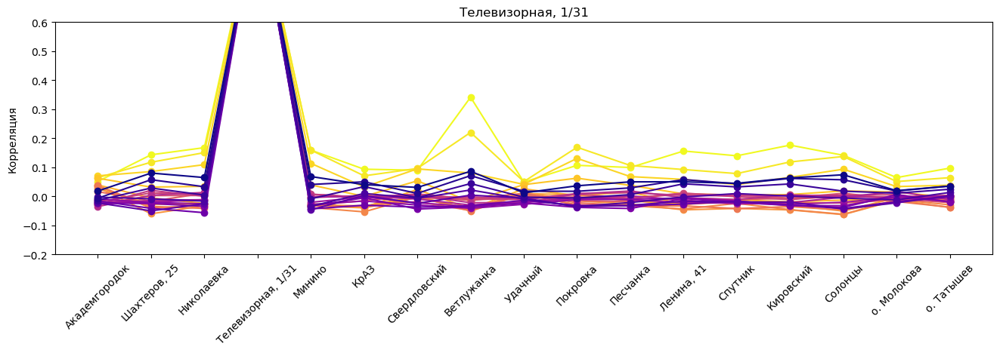

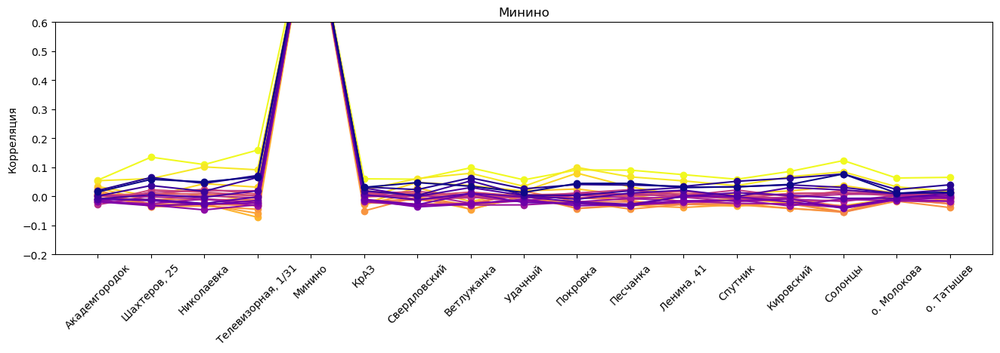

...

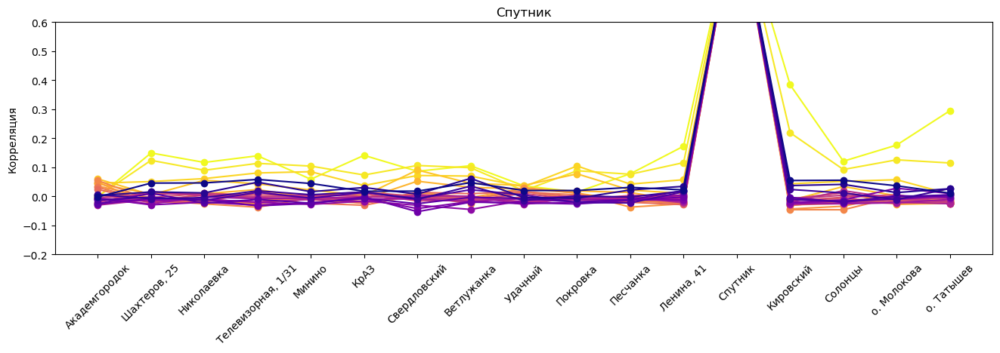

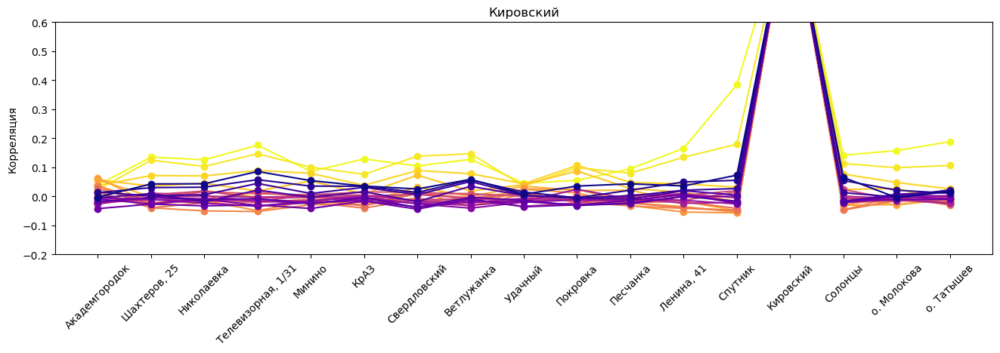

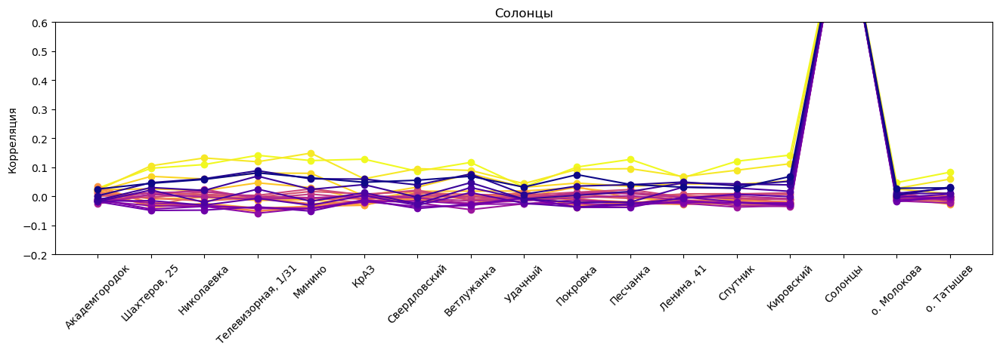

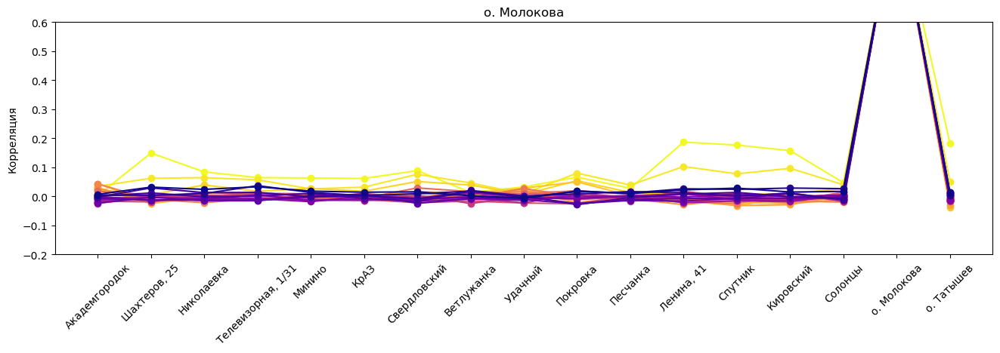

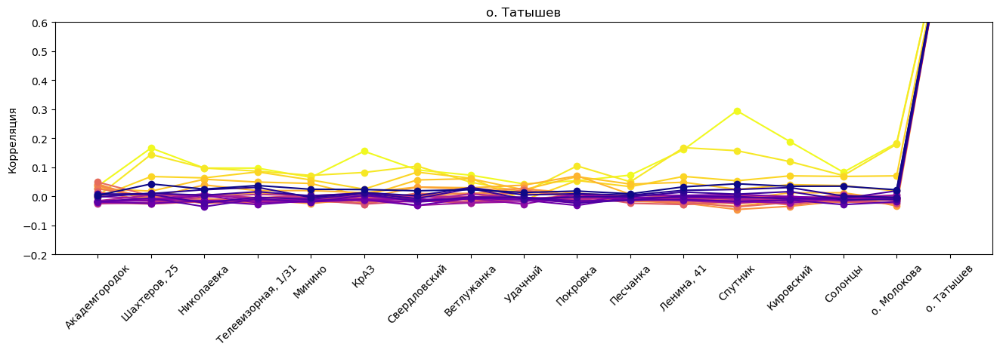

In [567]:
colors = cm.plasma(np.linspace(0, 1, 25))[::-1]
for i, site in enumerate(sites):
    plt.figure(figsize=(16,4))
    for t in range(25):
        plt.plot(sites, corr_tensor[t][i], 'o-', label=f't={t}',color=colors[t])
    plt.title(site)
    plt.xticks(rotation=45)
    plt.ylabel('Корреляция')
    plt.ylim(-0.2,0.6)
    plt.show()

In [39]:
def calculate_wind_lagged_corr(df, target_site, wind_condition_func, max_lag=24):
    """
    Вычисляет кросс-корреляцию первых разностей ('diff') между целевым датчиком 
    (в момент t - lag) и остальными датчиками (в момент t) при определенном ветре.
    """
    # Шаг 1. Переводим датасет из длинного формата в широкий по столбцу 'diff'
    # Каждая станция станет отдельным столбцом
    pivot_diff = df.pivot(index='time', columns='site', values='diff')
    
    # Шаг 2. Заполняем пропуски во времени, создавая непрерывную почасовую сетку.
    # Это ГЛАВНОЕ: теперь сдвиг на 1 позицию ВСЕГДА равен 1 часу!
    all_hours = pd.date_range(start=pivot_diff.index.min(), end=pivot_diff.index.max(), freq='h')
    pivot_diff = pivot_diff.reindex(all_hours)
    
    # Извлекаем метеоданные для каждого часа (привязываемся к целевой станции)
    meteo = df[df['site'] == target_site].set_index('time')[['DD', 'Ff']]
    meteo = meteo.reindex(all_hours)
    
    results = {}
    other_sites = [col for col in pivot_diff.columns if col != target_site]
    
    # Шаг 3. Итерируемся по лагам
    for lag in range(max_lag + 1):
        # Сдвигаем целевой датчик на 'lag' часов НАЗАД. 
        # Благодаря непрерывному индексу временной лаг не собьется!
        target_shifted = pivot_diff[target_site].shift(lag)
        
        # Собираем временный датафрейм для сопоставления в момент времени 't'
        temp_df = pd.DataFrame({
            'target_lagged': target_shifted, # значение целевой станции в t - lag
            'DD': meteo['DD'],               # направление ветра в момент t
            'Ff': meteo['Ff']                # скорость ветра в момент t
        })
        
        # Добавляем значения остальных станций в текущий момент 't'
        temp_df = temp_df.join(pivot_diff[other_sites])
        
        # Шаг 4. Применяем фильтрацию по ветру в текущий момент времени 't'
        # (Так как ветер несет массу именно сейчас)
        valid_rows = wind_condition_func(temp_df)
        filtered_df = temp_df[valid_rows]
        
        # Считаем корреляцию между целевым (t-lag) и остальными (t)
        lag_corrs = {}
        for site in other_sites:
            # Метод corr() в pandas автоматически игнорирует пропуски (NaN)
            corr_val = filtered_df['target_lagged'].corr(filtered_df[site])
            lag_corrs[site] = corr_val
            
        results[lag] = lag_corrs
        
    # Возвращаем датафрейм: строки - лаги (0-24), столбцы - другие датчики
    return pd.DataFrame(results).T

# --- ПРИМЕР ИСПОЛЬЗОВАНИЯ ---

# Обязательно переведите столбец времени в datetime перед вызовом функции!
df['time'] = pd.to_datetime(df['time'])


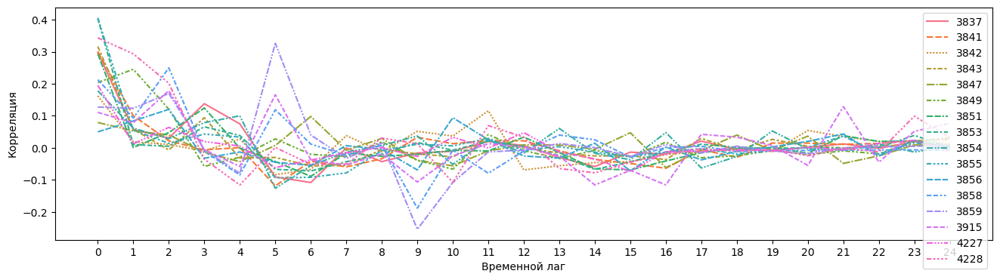

In [41]:
def specific_wind_condition(data):
    # condition = (data['Ff'] == 0.0)
    condition = (data['DD'] >= 180) & (data['DD'] <= 360) & (data['Ff'] == 3) #& (data['Ff'] <= 3)
    return condition

corr_matrix = calculate_wind_lagged_corr(df, target_site=3857, wind_condition_func=specific_wind_condition)
plt.figure(figsize=(16,4))
sns.lineplot(data=corr_matrix)
plt.legend(loc=1)
plt.xticks([*range(25)])
plt.ylabel('Корреляция')
plt.xlabel('Временной лаг')
plt.show()

In [834]:
def deg2rad(deg):
    return deg * (np.pi / 180)

def get_distance_m(lat1, lon1, lat2, lon2):
    R = 6371  # Radius of the earth in km
    d_lat = deg2rad(lat2 - lat1)
    d_lon = deg2rad(lon2 - lon1)
    
    a = (np.sin(d_lat / 2) ** 2 +
         np.cos(deg2rad(lat1)) * np.cos(deg2rad(lat2)) *
         np.sin(d_lon / 2) ** 2)
    
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    d = R * c  # Distance in km
    
    return d * 1000


In [846]:
dist_matrix = [[0 for _ in range(17)] for __ in range(17)]

In [850]:
for i, site1 in enumerate(df['site'].unique()):
    s1 = df[df['site']==site1]
    lat1 = s1['lat'].values[0]
    long1 = s1['long'].values[0]
    for j, site2 in enumerate(df['site'].unique()):
        s2 = df[df['site']==site2]
        lat2 = s2['lat'].values[0]
        long2 = s2['long'].values[0]

        dist_matrix[i][j] = get_distance_m(lat1,long1,lat2,long2) / 1000

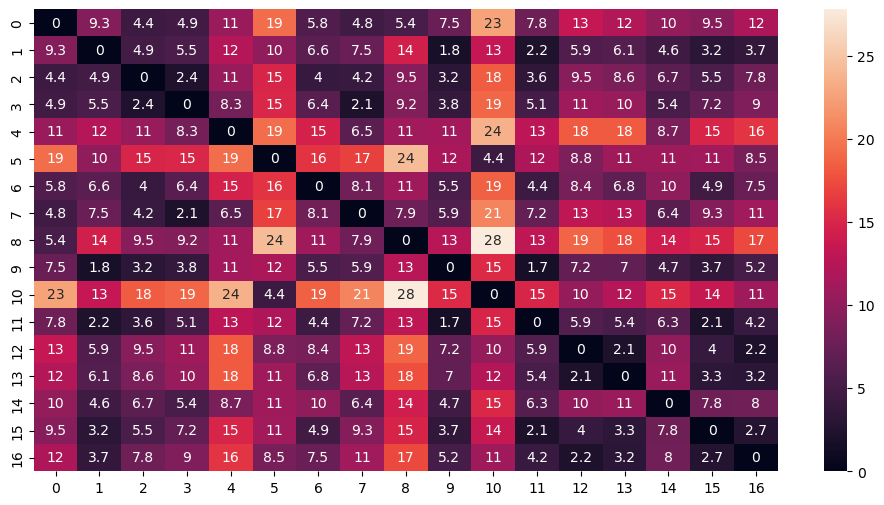

In [854]:
plt.figure(figsize=(12,6))
sns.heatmap(dist_matrix, annot=True)
plt.show()

In [856]:
np.mean(dist_matrix)

9.05986490839263

In [866]:
df

,T,Po,U,DD,Ff,site,iaqi,pm25,pm10,time,lat,long,h,pm25_lag1,diff
1,-17.866667,101324.721356,0.855000,348.690068,0.333333,3837,184.0,120.3,138.6,2021-01-01 02:00:00,55.986571,92.762222,255,114.1,6.2
2,-16.533334,101164.734685,0.830000,333.434949,0.666667,3837,184.0,119.3,137.5,2021-01-01 03:00:00,55.986571,92.762222,255,120.3,-1.0
3,-15.200000,101004.748014,0.805000,315.000000,1.000000,3837,171.0,94.1,107.8,2021-01-01 04:00:00,55.986571,92.762222,255,119.3,-25.2
4,-13.866667,100844.761342,0.780000,296.565051,1.333333,3837,160.0,72.1,81.8,2021-01-01 05:00:00,55.986571,92.762222,255,94.1,-22.0
5,-12.533333,100684.774671,0.755000,281.309932,1.666667,3837,164.0,81.5,93.7,2021-01-01 06:00:00,55.986571,92.762222,255,72.1,9.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
743745,-11.916667,100389.245865,0.878333,350.646475,0.166667,4228,54.0,13.8,16.0,2025-12-28 18:00:00,56.022003,92.943622,135,14.3,-0.5
743746,-11.700000,100418.132027,0.880000,0.000000,0.000000,4228,44.0,10.7,12.7,2025-12-28 19:00:00,56.022003,92.943622,135,13.8,-3.1
743747,-11.916667,100435.908023,0.891667,348.685101,0.166667,4228,52.0,13.0,15.2,2025-12-28 20:00:00,56.022003,92.943622,135,10.7,2.3
743748,-12.133333,100453.684018,0.903333,330.263168,0.333333,4228,56.0,14.8,17.8,2025-12-28 21:00:00,56.022003,92.943622,135,13.0,1.8


In [998]:
def normalize(data):
    std = np.std(data)
    mean = np.mean(data)
    return (data-mean)/std

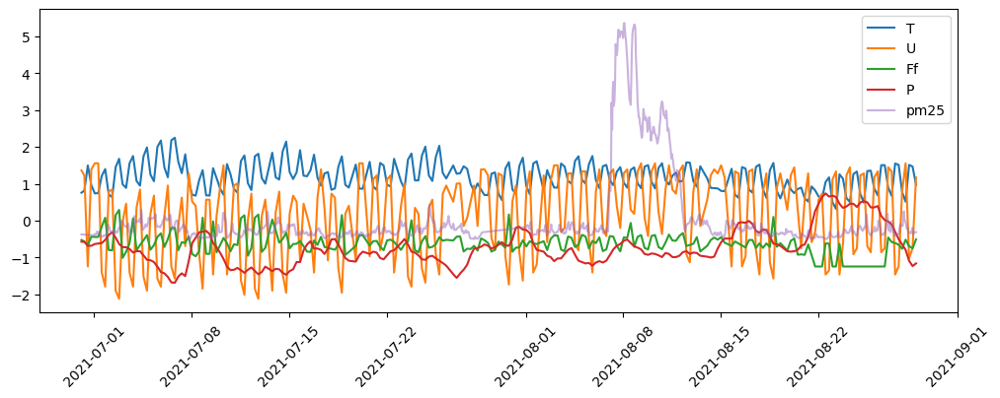

In [1016]:
s = df[df['site']==3857]
v = 24*30
plt.figure(figsize=(12,4))
plt.plot(s['time'].values[v*6:v*8],normalize(s['T'].values)[v*6:v*8],label='T')
plt.plot(s['time'].values[v*6:v*8],normalize(s['U'].values)[v*6:v*8],label='U')
plt.plot(s['time'].values[v*6:v*8],normalize(s['Ff'].values)[v*6:v*8],label='Ff')
plt.plot(s['time'].values[v*6:v*8],normalize(s['Po'].values)[v*6:v*8],label='P')
plt.plot(s['time'].values[v*6:v*8],normalize(s['pm25'].values)[v*6:v*8],label='pm25',alpha=0.5)
plt.legend()
plt.xticks(rotation=45)
plt.show()

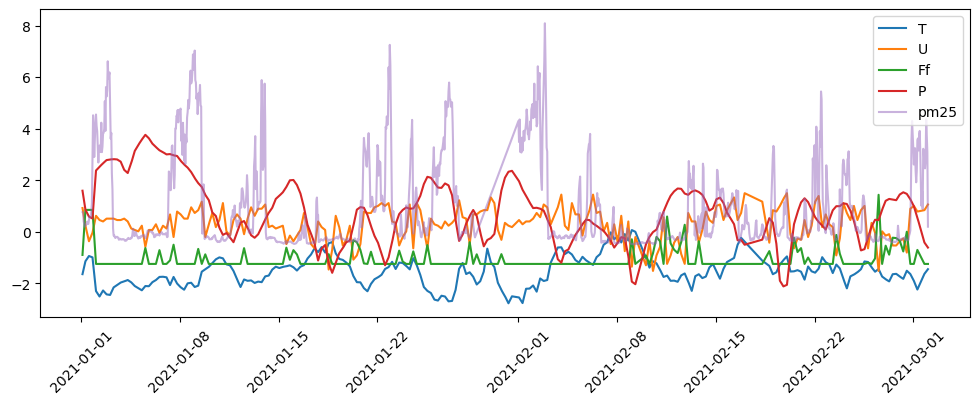

In [1010]:
v = 24*30*2
plt.figure(figsize=(12,4))
plt.plot(s['time'].values[:v],normalize(s['T'].values)[:v],label='T')
plt.plot(s['time'].values[:v],normalize(s['U'].values)[:v],label='U')
plt.plot(s['time'].values[:v],normalize(s['Ff'].values)[:v],label='Ff')
plt.plot(s['time'].values[:v],normalize(s['Po'].values)[:v],label='P')
plt.plot(s['time'].values[:v],normalize(s['pm25'].values)[:v],label='pm25',alpha=0.5)
plt.legend()
plt.xticks(rotation=45)
plt.show()